In [1]:
from __future__ import annotations

import csv
import os
import re
import warnings
from collections import defaultdict
from itertools import combinations
from pathlib import Path
from typing import Iterable, Optional, Union

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_breuschpagan,
    het_white,
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import gaussian_kde

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

import requests
from bs4 import BeautifulSoup

from tqdm.auto import tqdm

warnings.filterwarnings('ignore', message='Workbook contains no default style')
warnings.filterwarnings('ignore', message='The test statistic is outside')

import pickle
from pathlib import Path

In [2]:
plt.rcParams.update({
    # Размеры шрифтов
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.family': 'DejaVu Sans',
})

# 1. Полезные функции

## 1.1. Чтение файлов

In [3]:
def _detect_encoding(
    file_path: Union[str, Path],
    encodings_to_try: Optional[Iterable[str]] = None,
    sample_size: int = 10000
) -> str:
    """
    Пытается определить кодировку файла по небольшому фрагменту.
    """
    if encodings_to_try is None:
        encodings_to_try = ("utf-8", "utf-8-sig", "cp1251", "windows-1251")

    path = Path(file_path)
    raw = path.read_bytes()[:sample_size]

    for enc in encodings_to_try:
        try:
            raw.decode(enc)
            return enc
        except UnicodeDecodeError:
            continue

    raise UnicodeError(
        f"Не удалось определить кодировку файла: {path}. "
        f"Передай encoding явно."
    )


def _detect_separator(sample_text: str) -> str:
    """
    Определяет разделитель через csv.Sniffer.
    Если не получилось, использует резервную эвристику.
    """
    delimiters = ";,\t|"

    try:
        dialect = csv.Sniffer().sniff(sample_text, delimiters=delimiters)
        return dialect.delimiter
    except csv.Error:
        pass

    lines = [line for line in sample_text.splitlines() if line.strip()]
    if not lines:
        return ";"

    counts = {}
    for sep in delimiters:
        counts[sep] = sum(line.count(sep) for line in lines[:10])

    best_sep = max(counts, key=counts.get)
    return best_sep if counts[best_sep] > 0 else ";"


def _detect_decimal(sample_lines: list, sep: str) -> str:
    """
    Простая эвристика для определения десятичного разделителя.
    """
    counts = {",": 0, ".": 0}
    number_pattern = re.compile(r"[-+]?\d[\d\s]*[.,]\d+")

    for line in sample_lines:
        parts = line.split(sep)
        for part in parts:
            token = part.strip()
            if not token:
                continue

            if not number_pattern.search(token):
                continue

            if "," in token and "." in token:
                if token.rfind(",") > token.rfind("."):
                    counts[","] += 1
                else:
                    counts["."] += 1
            elif "," in token:
                counts[","] += 1
            elif "." in token:
                counts["."] += 1

    if counts[","] == 0 and counts["."] == 0:
        return "," if sep == ";" else "."

    return "," if counts[","] > counts["."] else "."


def read_dataframe(
    file_path: Union[str, Path],
    sep: Optional[str] = None,
    decimal: Optional[str] = None,
    encoding: Optional[str] = None,
    header: Optional[int] = 0,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Читает CSV/TSV-файл с автоматическим определением параметров
    и возвращает pandas DataFrame.

    Parameters
    ----------
    file_path : str | Path
        Путь к файлу.
    sep : str, optional
        Разделитель столбцов. Если None, определяется автоматически.
    decimal : str, optional
        Десятичный разделитель. Если None, определяется автоматически.
    encoding : str, optional
        Кодировка. Если None, определяется автоматически.
    header : int | None, default=0
        Номер строки с заголовком.
    verbose : bool, default=True
        Печатать ли диагностические сообщения в Jupyter.

    Returns
    -------
    pd.DataFrame
    """
    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")

    if path.stat().st_size == 0:
        raise ValueError(f"Файл пустой: {path}")

    if encoding is None:
        encoding = _detect_encoding(path)

    with open(path, "r", encoding=encoding) as f:
        sample_text = f.read(20000)

    sample_lines = [line for line in sample_text.splitlines() if line.strip()]

    if not sample_lines:
        raise ValueError(f"Файл не содержит читаемых строк: {path}")

    if sep is None:
        sep = _detect_separator("\n".join(sample_lines[:10]))

    if decimal is None:
        lines_for_decimal = sample_lines[1:11] if len(sample_lines) > 1 else sample_lines[:10]
        decimal = _detect_decimal(lines_for_decimal, sep)

    if verbose:
        print(f"Чтение файла: {path}")
        print(
            f"Определенные параметры: "
            f"разделитель='{sep}', десятичный='{decimal}', кодировка='{encoding}'"
        )

    try:
        df = pd.read_csv(
            path,
            encoding=encoding,
            sep=sep,
            decimal=decimal,
            header=header,
            na_values=["", " ", "NA", "N/A", "NULL", "null", "None", "NaN"],
            keep_default_na=True
        )
    except pd.errors.ParserError as e:
        raise ValueError(
            f"Ошибка парсинга файла {path}. "
            f"Проверь sep='{sep}', decimal='{decimal}', encoding='{encoding}'."
        ) from e
    except Exception as e:
        raise RuntimeError(f"Ошибка при чтении файла {path}: {e}") from e
        
    df.columns = [col.strip() if isinstance(col, str) else col for col in df.columns]

    if verbose:
        print(f"Успешно прочитано: {len(df)} строк, {len(df.columns)} столбцов")
        print(f"Столбцы: {list(df.columns)}\n")

    return df

In [4]:
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

def run_or_load(cache_name, func, **kwargs):
    """Загружает результат из кэша или считает и сохраняет."""
    path = CACHE_DIR / f"{cache_name}.pkl"
    if path.exists():
        print(f"Загружен кэш: {path}")
        with open(path, "rb") as f:
            return pickle.load(f)
    result = func(**kwargs)
    with open(path, "wb") as f:
        pickle.dump(result, f)
    print(f"Сохранён кэш: {path}")
    return result

## 1.2. Хелперы загрузки данных

In [5]:
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / 'data'
OFZ_DIR = DATA_DIR / 'ofz'
GOLD_DIR = DATA_DIR / 'золото'
EQUITY_DIR = DATA_DIR / 'индексы_акций'
BOND_DIR = DATA_DIR / 'индексы_облигаций'
REGRESSION_DIR = DATA_DIR / 'данные для регрессии'
 
 
def load_moex_index(
    file_path,
    ticker_col='ID',
    date_col='TRADEDATE',
    value_col='CLOSE',
    date_format='%Y-%m-%d',
    verbose=False,
):
    """
    Загружает индекс MOEX из CSV, оставляя только [TICKER, TRADEDATE, CLOSE].
    
    Parameters
    ----------
    file_path : str | Path
        Путь к CSV-файлу.
    ticker_col : str
        Имя столбца с тикером в исходном файле (ID или SECID).
    date_col : str
        Имя столбца с датой.
    value_col : str
        Имя столбца со значением (обычно CLOSE).
    date_format : str
        Формат даты для pd.to_datetime.
    verbose : bool
        Печатать ли диагностику при чтении.
    
    Returns
    -------
    pd.DataFrame
        Columns: ['TICKER', 'TRADEDATE', 'CLOSE'], sorted by date, no NaN.
    """
    df = read_dataframe(file_path, verbose=verbose)
    df = df[[ticker_col, date_col, value_col]].rename(
        columns={ticker_col: 'TICKER', date_col: 'TRADEDATE', value_col: 'CLOSE'}
    )
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'], format=date_format)
    df['TICKER'] = df['TICKER'].astype('string')
    df = df.dropna().sort_values('TRADEDATE').reset_index(drop=True)
    return df
 
 
def load_all_files_in_dir(
    directory,
    loader_func,
    file_pattern='*.csv',
    verbose=False,
    **loader_kwargs,
):
    """
    Загружает все CSV из папки одной функцией.
    
    Returns
    -------
    dict[str, pd.DataFrame]
        Ключ = имя файла (без расширения), значение = DataFrame.
    """
    directory = Path(directory)
    result = {}
    for f in sorted(directory.glob(file_pattern)):
        key = f.stem  # имя файла без расширения
        result[key] = loader_func(f, verbose=verbose, **loader_kwargs)
    return result

## 1.3. Коэффициенты

In [6]:
TRADING_DAYS = 252

In [7]:
def _validate_inputs(
    asset_returns: pd.DataFrame,
    weights: np.ndarray,
    check_long_only: bool = True,
    weight_tolerance: float = 1e-8,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Базовая валидация входов.
    """
    if not isinstance(asset_returns, pd.DataFrame):
        raise TypeError("asset_returns must be a pandas.DataFrame")

    if asset_returns.empty:
        raise ValueError("asset_returns is empty")

    if asset_returns.isna().any().any():
        raise ValueError("asset_returns contains NaN values. Clean data before calculations.")

    # Проверяем, что все столбцы числовые
    non_numeric_cols = asset_returns.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_cols:
        raise TypeError(f"Non-numeric columns found in asset_returns: {non_numeric_cols}")

    # Простые доходности не могут быть меньше -100%
    if (asset_returns < -1).any().any():
        raise ValueError("asset_returns contains values below -1.0, which is invalid for simple returns.")

    w = np.asarray(weights, dtype=float).reshape(-1)

    if len(w) != asset_returns.shape[1]:
        raise ValueError(
            f"Number of weights ({len(w)}) must match number of columns "
            f"in asset_returns ({asset_returns.shape[1]})."
        )

    if np.isnan(w).any():
        raise ValueError("weights contains NaN values")

    if not np.isclose(w.sum(), 1.0, atol=weight_tolerance):
        raise ValueError(f"weights must sum to 1.0, got {w.sum():.12f}")

    if check_long_only and (w < -weight_tolerance).any():
        raise ValueError("weights contains negative values, but long-only setting is assumed")

    return asset_returns, w


def _portfolio_return_series(
    asset_returns: pd.DataFrame,
    weights: np.ndarray,
    check_long_only: bool = True,
) -> pd.Series:
    """
    Ряд простых доходностей портфеля.
    """
    asset_returns, w = _validate_inputs(
        asset_returns=asset_returns,
        weights=weights,
        check_long_only=check_long_only,
    )

    portfolio_returns = asset_returns @ w
    return pd.Series(portfolio_returns, index=asset_returns.index, name="portfolio_return")


def _to_periodic_rate(
    rate: float | None,
    periods_per_year: int = TRADING_DAYS,
    annual: bool = True,
) -> float:
    """
    Переводит ставку/порог в периодическую форму.
    """
    if rate is None:
        return 0.0

    if annual:
        return rate / periods_per_year
    return rate


def _wealth_index(
    portfolio_returns: pd.Series,
    initial_wealth: float = 1.0,
) -> pd.Series:
    """
    Compounded wealth curve:
    W_t = W_{t-1} * (1 + r_t)
    """
    if portfolio_returns.empty:
        return pd.Series(dtype=float)

    return initial_wealth * (1.0 + portfolio_returns).cumprod()


def _drawdown_series(portfolio_returns: pd.Series) -> pd.Series:
    """
    Относительные просадки по compounded wealth curve:
    DD_t = 1 - W_t / max_{s<=t} W_s
    """
    wealth = _wealth_index(portfolio_returns)
    if wealth.empty:
        return pd.Series(dtype=float)

    running_max = wealth.cummax()
    drawdowns = 1.0 - wealth / running_max
    return drawdowns


def _cagr(
    portfolio_returns: pd.Series,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Compound Annual Growth Rate.
    """
    n = len(portfolio_returns)
    if n == 0:
        return np.nan

    final_wealth = _wealth_index(portfolio_returns).iloc[-1]
    return float(final_wealth ** (periods_per_year / n) - 1.0)


def _historical_cvar_of_losses(
    portfolio_returns: pd.Series,
    alpha: float = 0.05,
) -> float:
    """
    Исторический CVaR для потерь:
    losses = -returns
    CVaR_alpha = среднее значение потерь в худших alpha-долях наблюдений
    """
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1)")

    losses = -portfolio_returns.to_numpy(dtype=float)

    if losses.size == 0:
        return np.nan

    var_threshold = np.quantile(losses, 1 - alpha)
    tail_losses = losses[losses >= var_threshold]

    if tail_losses.size == 0:
        return np.nan

    return float(tail_losses.mean())

In [8]:
def calculate_portfolio_sharpe_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Аннуализированный коэффициент Шарпа.

    Формула:
        Sharpe = (mean(r_p - r_f_periodic) / std(r_p)) * sqrt(periods_per_year)

    Здесь используется стандартная практическая annualization-конвенция
    для дневных данных.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    rf_periodic = _to_periodic_rate(risk_free_rate, periods_per_year=periods_per_year, annual=True)

    daily_excess_mean = (portfolio_returns - rf_periodic).mean()
    daily_vol = portfolio_returns.std(ddof=1)

    if pd.isna(daily_vol) or np.isclose(daily_vol, 0.0):
        return np.nan

    return float((daily_excess_mean / daily_vol) * np.sqrt(periods_per_year))

In [9]:
def calculate_portfolio_sortino_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float | None = None,
    mar: float | None = None,
    mar_annual: bool = False,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Аннуализированный коэффициент Сортино.

    Приоритет целевого порога:
        1) risk_free_rate, если задан
        2) mar
        3) 0.0

    Формула:
        Sortino = annualized_excess_return / annualized_downside_deviation
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)

    if risk_free_rate is not None:
        target_periodic = _to_periodic_rate(risk_free_rate, periods_per_year=periods_per_year, annual=True)
    elif mar is not None:
        target_periodic = _to_periodic_rate(mar, periods_per_year=periods_per_year, annual=mar_annual)
    else:
        target_periodic = 0.0

    shortfalls = np.minimum(portfolio_returns - target_periodic, 0.0)
    downside_deviation_daily = np.sqrt(np.mean(np.square(shortfalls)))
    excess_mean_daily = portfolio_returns.mean() - target_periodic

    if pd.isna(downside_deviation_daily) or np.isclose(downside_deviation_daily, 0.0):
        return np.nan

    annual_excess_return = excess_mean_daily * periods_per_year
    annual_downside_deviation = downside_deviation_daily * np.sqrt(periods_per_year)

    return float(annual_excess_return / annual_downside_deviation)

In [10]:
def calculate_portfolio_volatility(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Аннуализированная волатильность портфеля.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    daily_vol = portfolio_returns.std(ddof=1)

    if pd.isna(daily_vol):
        return np.nan

    return float(daily_vol * np.sqrt(periods_per_year))

In [11]:
def calculate_portfolio_max_drawdown(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """
    Максимальная относительная просадка (MDD) по compounded wealth curve.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    drawdowns = _drawdown_series(portfolio_returns)

    if drawdowns.empty:
        return np.nan

    return float(drawdowns.max())

In [12]:
def calculate_portfolio_calmar_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Классический Calmar Ratio:
        Calmar = CAGR / MDD

    Безрисковая ставка здесь не используется.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)

    cagr = _cagr(portfolio_returns, periods_per_year=periods_per_year)
    mdd = _drawdown_series(portfolio_returns).max()

    if pd.isna(mdd) or np.isclose(mdd, 0.0):
        return np.nan

    return float(cagr / mdd)

In [13]:
def calculate_portfolio_ulcer_index(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """
    Ulcer Index по compounded wealth curve:
        UI = sqrt(mean(DD_t^2))
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    drawdowns = _drawdown_series(portfolio_returns)

    if drawdowns.empty:
        return np.nan

    ui = np.sqrt(np.mean(np.square(drawdowns)))
    return float(ui)

In [14]:
def calculate_portfolio_martin_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Martin Ratio / Ulcer Performance Index:
        Martin = (CAGR - Rf_annual) / UI
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)

    cagr = _cagr(portfolio_returns, periods_per_year=periods_per_year)
    ui = calculate_portfolio_ulcer_index(asset_daily_returns, weights)

    if pd.isna(ui) or np.isclose(ui, 0.0):
        return np.nan

    return float((cagr - risk_free_rate) / ui)

In [15]:
def calculate_portfolio_cvar_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    alpha: float = 0.05,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    CVaR-based reward-risk ratio на периодической (дневной) частоте:

        CVaR_ratio = (E[r_p] - r_f_periodic) / CVaR_alpha(losses)

    Специально НЕ аннуализируется.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    rf_periodic = _to_periodic_rate(risk_free_rate, periods_per_year=periods_per_year, annual=True)

    excess_mean_periodic = portfolio_returns.mean() - rf_periodic
    cvar = _historical_cvar_of_losses(portfolio_returns, alpha=alpha)

    if pd.isna(cvar) or np.isclose(cvar, 0.0):
        return np.nan

    return float(excess_mean_periodic / cvar)

In [16]:
def calculate_portfolio_omega_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    threshold_return: float = 0.0,
    threshold_annual: bool = False,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Истинный эмпирический Omega Ratio на периодической частоте:

        Omega(L) = E[max(r - L, 0)] / E[max(L - r, 0)]

    где L — пороговая доходность на той же частоте, что и данные.

    Специально НЕ аннуализируется.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    threshold_periodic = _to_periodic_rate(
        threshold_return,
        periods_per_year=periods_per_year,
        annual=threshold_annual,
    )

    gains = np.maximum(portfolio_returns - threshold_periodic, 0.0).mean()
    losses = np.maximum(threshold_periodic - portfolio_returns, 0.0).mean()

    if np.isclose(losses, 0.0):
        if gains > 0:
            return np.inf
        return np.nan

    return float(gains / losses)

## 1.4. Расчет границ активов

In [17]:
# ---------------------------------------------------------------------------
#  Константы
# ---------------------------------------------------------------------------
 
TRADING_DAYS: int = 252
 
VALID_METRICS: dict[str, str] = {
    "sharpe":       "max",
    "sortino":      "max",
    "calmar":       "max",
    "max_drawdown": "min",
    "volatility":   "min",
    "cvar":         "max",
    "martin":       "max",
    "omega":        "max",
}
 
# Минимально допустимое значение знаменателя дробных метрик (дневной масштаб).
# Дневная волатильность  < _EPS_DAILY  трактуется как вырожденный ряд.
_EPS_DAILY: float = 1e-6
 
# Нижняя граница масштабирующего множителя в целевой функции.
# Гарантирует, что регуляризация не «исчезает» при околонулевой метрике.
_METRIC_SCALE_FLOOR: float = 0.1

In [18]:
# ===================================================================
#  Валидация и вспомогательные функции
# ===================================================================
 
def _validate_returns_dataframe(returns: pd.DataFrame) -> pd.DataFrame:
    """Проверяет DataFrame доходностей на корректность."""
    if not isinstance(returns, pd.DataFrame):
        raise TypeError("portfolio_daily_returns must be a pandas.DataFrame")
 
    if returns.empty:
        raise ValueError("portfolio_daily_returns is empty")
 
    if not isinstance(returns.index, pd.DatetimeIndex):
        raise TypeError("portfolio_daily_returns.index must be a pandas.DatetimeIndex")
 
    if returns.index.has_duplicates:
        raise ValueError("portfolio_daily_returns.index contains duplicates")
 
    if not returns.index.is_monotonic_increasing:
        returns = returns.sort_index()
 
    if returns.isna().any().any():
        raise ValueError(
            "portfolio_daily_returns contains NaN values. Clean data before analysis."
        )
 
    non_numeric_cols = returns.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_cols:
        raise TypeError(f"Non-numeric columns found: {non_numeric_cols}")
 
    return returns
 
 
def _normalize_target_weights(target_weights, n_assets: int) -> np.ndarray:
    """Нормализует целевые веса к сумме 1."""
    w = np.asarray(target_weights, dtype=np.float64).ravel()
 
    if len(w) != n_assets:
        raise ValueError(
            f"Number of target weights ({len(w)}) must match "
            f"number of assets ({n_assets})"
        )
 
    if np.isnan(w).any():
        raise ValueError("target_weights contains NaN values")
 
    if np.allclose(w.sum(), 0.0):
        raise ValueError("Sum of target_weights is zero")
 
    if (w < 0).any():
        raise ValueError("target_weights must be non-negative in long-only setting")
 
    return w / w.sum()
 
 
def _prepare_returns_array(returns: pd.DataFrame):
    """Валидирует DataFrame и возвращает быстрые NumPy-представления."""
    returns = _validate_returns_dataframe(returns)
    arr = np.ascontiguousarray(returns.to_numpy(dtype=np.float64, copy=False))
    dates = returns.index.to_numpy()
    columns = list(returns.columns)
    return returns, arr, dates, columns
 
 
def _project_to_capped_simplex(
    weights: np.ndarray,
    n_assets: int,
    max_weight_per_asset: float,
    tol: float = 1e-12,
    max_iter: int = 200,
) -> np.ndarray:
    """
    Проекция на множество  {w : sum(w)=1, 0 <= w_i <= cap}
    методом бисекции по множителю Лагранжа.
    """
    if max_weight_per_asset <= 0:
        raise ValueError("max_weight_per_asset must be positive")
 
    if n_assets * max_weight_per_asset < 1.0 - 1e-12:
        raise ValueError(
            "Infeasible constraints: n_assets * max_weight_per_asset < 1. "
            "С такими ограничениями невозможно собрать fully invested portfolio."
        )
 
    v = np.asarray(weights, dtype=np.float64).ravel()
    if len(v) != n_assets:
        raise ValueError("weights length does not match n_assets")
    if np.isnan(v).any():
        raise ValueError("weights contains NaN values")
 
    u = float(max_weight_per_asset)
 
    clipped = np.clip(v, 0.0, u)
    if abs(clipped.sum() - 1.0) <= tol:
        return clipped
 
    lo = np.min(v) - u
    hi = np.max(v)
 
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        w = np.clip(v - mid, 0.0, u)
        s = w.sum()
 
        if abs(s - 1.0) <= tol:
            return w
 
        if s > 1.0:
            lo = mid
        else:
            hi = mid
 
    w = np.clip(v - 0.5 * (lo + hi), 0.0, u)
    s = w.sum()
    if s <= tol:
        raise RuntimeError("Projection failed: sum after projection is zero")
 
    return w / s
 
 
def _generate_feasible_random_starts(
    n_assets: int,
    max_weight_per_asset: float,
    n_random_starts: int,
    rng: np.random.Generator,
) -> list[np.ndarray]:
    """Генерирует feasible random starting points на capped simplex."""
    starts = []
    for _ in range(n_random_starts):
        w = rng.dirichlet(np.ones(n_assets))
        w = _project_to_capped_simplex(
            w, n_assets=n_assets, max_weight_per_asset=max_weight_per_asset
        )
        starts.append(w)
    return starts

In [19]:
# ===================================================================
#  Генерация скользящих окон
# ===================================================================
 
def generate_calendar_windows(
    portfolio_daily_returns: pd.DataFrame,
    window_years: int = 3,
    step_months: int = 3,
    min_observations: int = 252,
) -> list[dict]:
    """Генерирует календарные перекрывающиеся окна."""
    returns = _validate_returns_dataframe(portfolio_daily_returns)
 
    if window_years <= 0:
        raise ValueError("window_years must be positive")
    if step_months <= 0:
        raise ValueError("step_months must be positive")
    if min_observations <= 1:
        raise ValueError("min_observations must be > 1")
 
    dates = returns.index.to_numpy()
    start_date = pd.Timestamp(dates[0])
    last_date = pd.Timestamp(dates[-1])
 
    windows: list[dict] = []
    current_start = start_date
 
    while True:
        current_end = current_start + pd.DateOffset(years=window_years)
 
        if current_end > last_date:
            break
 
        i0 = int(dates.searchsorted(np.datetime64(current_start), side="left"))
        i1 = int(dates.searchsorted(np.datetime64(current_end), side="right"))
 
        n_obs = i1 - i0
        if n_obs >= min_observations:
            windows.append(
                {
                    "start": current_start,
                    "end": pd.Timestamp(dates[i1 - 1]),
                    "i0": i0,
                    "i1": i1,
                    "n_obs": n_obs,
                }
            )
 
        current_start += pd.DateOffset(months=step_months)
 
    if not windows:
        raise ValueError(
            "No valid windows were generated. Check date range and window settings."
        )
 
    return windows

In [20]:
def _historical_cvar_of_losses_np(portfolio_returns: np.ndarray, alpha: float = 0.05) -> float:
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1)")
 
    losses = -portfolio_returns
    if losses.size == 0:
        return np.nan
 
    var_threshold = np.quantile(losses, 1 - alpha)
    tail_losses = losses[losses >= var_threshold]
 
    if tail_losses.size == 0:
        return np.nan
 
    return float(tail_losses.mean())
 
 
def _metric_value_np(
    window_array: np.ndarray,
    weights: np.ndarray,
    metric: str,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Быстрый расчет метрики на NumPy-массиве окна.
    """
    metric = metric.lower()
    if metric not in VALID_METRICS:
        raise ValueError(f"Unknown metric: {metric}")
 
    rp = window_array @ weights
    n = rp.size
 
    if n == 0:
        return np.nan
 
    mean_daily = rp.mean()
    std_daily = rp.std(ddof=1) if n > 1 else 0.0
 
    rf_daily = risk_free_rate / periods_per_year
    mar_daily = mar / periods_per_year
    omega_daily = omega_threshold / periods_per_year
 
    if metric == "sharpe":
        if np.isclose(std_daily, 0.0):
            return np.nan
        return float(((mean_daily - rf_daily) / std_daily) * np.sqrt(periods_per_year))
 
    if metric == "sortino":
        shortfalls = np.minimum(rp - mar_daily, 0.0)
        downside = np.sqrt(np.mean(shortfalls ** 2))
        if np.isclose(downside, 0.0):
            return np.nan
        annual_excess = (mean_daily - mar_daily) * periods_per_year
        annual_downside = downside * np.sqrt(periods_per_year)
        return float(annual_excess / annual_downside)
 
    if metric == "volatility":
        return float(std_daily * np.sqrt(periods_per_year))
 
    if metric == "cvar":
        cvar = _historical_cvar_of_losses_np(rp, alpha=cvar_alpha)
        if np.isnan(cvar) or np.isclose(cvar, 0.0):
            return np.nan
        return float((mean_daily - rf_daily) / cvar)
 
    if metric == "omega":
        gains = np.maximum(rp - omega_daily, 0.0).mean()
        losses = np.maximum(omega_daily - rp, 0.0).mean()
        if np.isclose(losses, 0.0):
            return np.inf if gains > 0 else np.nan
        return float(gains / losses)
 
    # Path-dependent metrics
    wealth = np.cumprod(1.0 + rp)
    running_max = np.maximum.accumulate(wealth)
    drawdowns = 1.0 - wealth / running_max
 
    if metric == "max_drawdown":
        return float(drawdowns.max())
 
    if metric == "calmar":
        mdd = drawdowns.max()
        if np.isclose(mdd, 0.0):
            return np.nan
        cagr = wealth[-1] ** (periods_per_year / n) - 1.0
        return float(cagr / mdd)
 
    if metric == "martin":
        ui = np.sqrt(np.mean(drawdowns ** 2))
        if np.isclose(ui, 0.0):
            return np.nan
        cagr = wealth[-1] ** (periods_per_year / n) - 1.0
        return float((cagr - risk_free_rate) / ui)
 
    raise ValueError(f"Unsupported metric: {metric}")
 
 
def _evaluate_metric(
    window_returns: pd.DataFrame,
    weights: np.ndarray,
    metric: str,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    periods_per_year: int = 252,
) -> float:
    """
    Совместимый внешний интерфейс: принимает DataFrame, но быстро переводит в NumPy.
    """
    _, arr, _, _ = _prepare_returns_array(window_returns)
    return _metric_value_np(
        arr,
        weights,
        metric,
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold,
        periods_per_year=periods_per_year,
    )
 
 
def _make_objective_function(
    window_array: np.ndarray,
    metric: str,
    target_weights: np.ndarray,
    regularization_strength: float,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float,
    omega_threshold: float,
    periods_per_year: int,
    max_weight_per_asset: float,
):
    """
    Строит objective function для оптимизации.
    """
    direction = VALID_METRICS[metric.lower()]
 
    target_metric_value = _metric_value_np(
        window_array,
        target_weights,
        metric,
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold,
        periods_per_year=periods_per_year,
    )
 
    metric_scale = max(abs(target_metric_value), 1e-6) if np.isfinite(target_metric_value) else 1.0
 
    def objective(weights: np.ndarray) -> float:
        if np.any(~np.isfinite(weights)):
            return 1e12
 
        if np.any(weights < -1e-8) or np.any(weights > max_weight_per_asset + 1e-8):
            return 1e12
 
        s = weights.sum()
        if not np.isfinite(s):
            return 1e12
        if abs(s - 1.0) > 1e-6:
            return 1e10 + 1e6 * (s - 1.0) ** 2
 
        metric_value = _metric_value_np(
            window_array,
            weights,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
        )
 
        if not np.isfinite(metric_value):
            return 1e12
 
        scaled_metric = metric_value / metric_scale
        obj = -scaled_metric if direction == "max" else scaled_metric
 
        if regularization_strength > 0:
            obj += regularization_strength * np.sum((weights - target_weights) ** 2)
 
        return float(obj)
 
    return objective

In [21]:
# ===================================================================
#  Расчёт метрик
# ===================================================================
 
def _historical_cvar_of_losses_np(
    portfolio_returns: np.ndarray,
    alpha: float = 0.05,
) -> float:
    """Историческая CVaR (Expected Shortfall) убытков."""
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1)")
 
    losses = -portfolio_returns
    if losses.size == 0:
        return np.nan
 
    var_threshold = np.quantile(losses, 1 - alpha)
    tail_losses = losses[losses >= var_threshold]
 
    if tail_losses.size == 0:
        return np.nan
 
    return float(tail_losses.mean())
 
 
def _metric_value_np(
    window_array: np.ndarray,
    weights: np.ndarray,
    metric: str,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """
    Расчёт одной метрики на NumPy-массиве окна.
 
    Использует явные числовые пороги (_EPS_DAILY) вместо np.isclose
    для надёжного обнаружения вырожденных случаев на дневных данных.
    """
    metric = metric.lower()
    if metric not in VALID_METRICS:
        raise ValueError(f"Unknown metric: {metric}")
 
    rp = window_array @ weights
    n = rp.size
 
    if n == 0:
        return np.nan
 
    mean_daily = rp.mean()
    std_daily = rp.std(ddof=1) if n > 1 else 0.0
 
    rf_daily = risk_free_rate / periods_per_year
    mar_daily = mar / periods_per_year
    omega_daily = omega_threshold / periods_per_year
 
    # --- Sharpe ---
    if metric == "sharpe":
        if std_daily < _EPS_DAILY:
            return np.nan
        return float(
            ((mean_daily - rf_daily) / std_daily) * np.sqrt(periods_per_year)
        )
 
    # --- Sortino ---
    if metric == "sortino":
        shortfalls = np.minimum(rp - mar_daily, 0.0)
        downside = np.sqrt(np.mean(shortfalls ** 2))
        if downside < _EPS_DAILY:
            return np.nan
        annual_excess = (mean_daily - mar_daily) * periods_per_year
        annual_downside = downside * np.sqrt(periods_per_year)
        return float(annual_excess / annual_downside)
 
    # --- Volatility ---
    if metric == "volatility":
        return float(std_daily * np.sqrt(periods_per_year))
 
    # --- CVaR Ratio ---
    if metric == "cvar":
        cvar = _historical_cvar_of_losses_np(rp, alpha=cvar_alpha)
        if np.isnan(cvar) or cvar < _EPS_DAILY:
            return np.nan
        return float((mean_daily - rf_daily) / cvar)
 
    # --- Omega ---
    if metric == "omega":
        gains = np.maximum(rp - omega_daily, 0.0).mean()
        losses_val = np.maximum(omega_daily - rp, 0.0).mean()
        if losses_val < _EPS_DAILY * 0.01:
            return np.inf if gains > 0 else np.nan
        return float(gains / losses_val)
 
    # --- Метрики, зависящие от пути (path-dependent) ---
    wealth = np.cumprod(1.0 + rp)
    running_max = np.maximum.accumulate(wealth)
    drawdowns = 1.0 - wealth / running_max
 
    # --- Max Drawdown ---
    if metric == "max_drawdown":
        return float(drawdowns.max())
 
    # --- Calmar ---
    if metric == "calmar":
        mdd = drawdowns.max()
        if mdd < _EPS_DAILY:
            return np.nan
        cagr = wealth[-1] ** (periods_per_year / n) - 1.0
        return float(cagr / mdd)
 
    # --- Martin (Ulcer Performance Index) ---
    if metric == "martin":
        ui = np.sqrt(np.mean(drawdowns ** 2))
        if ui < _EPS_DAILY:
            return np.nan
        cagr = wealth[-1] ** (periods_per_year / n) - 1.0
        return float((cagr - risk_free_rate) / ui)
 
    raise ValueError(f"Unsupported metric: {metric}")
 
 
def _evaluate_metric(
    window_returns: pd.DataFrame,
    weights: np.ndarray,
    metric: str,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    periods_per_year: int = 252,
) -> float:
    """Внешний интерфейс: принимает DataFrame, переводит в NumPy."""
    _, arr, _, _ = _prepare_returns_array(window_returns)
    return _metric_value_np(
        arr,
        weights,
        metric,
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold,
        periods_per_year=periods_per_year,
    )

In [22]:
# ===================================================================
#  Целевая функция и оптимизация одного окна
# ===================================================================
 
def _make_objective_function(
    window_array: np.ndarray,
    metric: str,
    target_weights: np.ndarray,
    regularization_strength: float,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float,
    omega_threshold: float,
    periods_per_year: int,
    max_weight_per_asset: float,
):
    """
    Строит целевую функцию для SLSQP.
 
    obj(w) = direction * f(w) / s  +  λ · ||w - w_target||²
 
    где s = max(|f(w_target)|, _METRIC_SCALE_FLOOR).
    """
    direction = VALID_METRICS[metric.lower()]
 
    target_metric_value = _metric_value_np(
        window_array,
        target_weights,
        metric,
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold,
        periods_per_year=periods_per_year,
    )
 
    # Масштабирующий множитель: floor = 0.1 гарантирует,
    # что регуляризация не «исчезает» при околонулевой метрике.
    metric_scale = (
        max(abs(target_metric_value), _METRIC_SCALE_FLOOR)
        if np.isfinite(target_metric_value)
        else 1.0
    )
 
    def objective(weights: np.ndarray) -> float:
        if np.any(~np.isfinite(weights)):
            return 1e12
 
        if np.any(weights < -1e-8) or np.any(weights > max_weight_per_asset + 1e-8):
            return 1e12
 
        s = weights.sum()
        if not np.isfinite(s):
            return 1e12
        if abs(s - 1.0) > 1e-6:
            return 1e10 + 1e6 * (s - 1.0) ** 2
 
        metric_value = _metric_value_np(
            window_array,
            weights,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
        )
 
        if not np.isfinite(metric_value):
            return 1e12
 
        scaled_metric = metric_value / metric_scale
        obj = -scaled_metric if direction == "max" else scaled_metric
 
        if regularization_strength > 0:
            obj += regularization_strength * np.sum(
                (weights - target_weights) ** 2
            )
 
        return float(obj)
 
    return objective
 
 
def optimize_single_window(
    window_returns: pd.DataFrame,
    target_weights: np.ndarray,
    metric: str,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    regularization_strength: float = 0.0,
    periods_per_year: int = 252,
    n_random_starts: int = 3,
    random_state: int = 42,
    store_trace: bool = False,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict:
    """Оптимизация на одном окне с multi-start."""
    window_returns = _validate_returns_dataframe(window_returns)
    window_array = np.ascontiguousarray(
        window_returns.to_numpy(dtype=np.float64, copy=False)
    )
    n_assets = window_array.shape[1]
 
    target_weights = _normalize_target_weights(target_weights, n_assets=n_assets)
    target_feasible = _project_to_capped_simplex(
        weights=target_weights,
        n_assets=n_assets,
        max_weight_per_asset=max_weight_per_asset,
    )
 
    objective = _make_objective_function(
        window_array=window_array,
        metric=metric,
        target_weights=target_feasible,
        regularization_strength=regularization_strength,
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold,
        periods_per_year=periods_per_year,
        max_weight_per_asset=max_weight_per_asset,
    )
 
    bounds = [(0.0, max_weight_per_asset)] * n_assets
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
 
    if 1.0 / n_assets <= max_weight_per_asset + 1e-12:
        equal_weights = np.full(n_assets, 1.0 / n_assets, dtype=np.float64)
    else:
        equal_weights = _project_to_capped_simplex(
            np.full(n_assets, 1.0 / n_assets, dtype=np.float64),
            n_assets=n_assets,
            max_weight_per_asset=max_weight_per_asset,
        )
 
    rng = np.random.default_rng(random_state)
    random_starts = _generate_feasible_random_starts(
        n_assets=n_assets,
        max_weight_per_asset=max_weight_per_asset,
        n_random_starts=n_random_starts,
        rng=rng,
    )
 
    starting_points = [
        ("target", target_feasible.copy()),
        ("equal", equal_weights.copy()),
    ] + [(f"random_{i + 1}", w) for i, w in enumerate(random_starts)]
 
    candidates: list[dict] = []
 
    for label, x0 in starting_points:
        trace: list[np.ndarray] = []
 
        def callback(xk, trace_ref=trace):
            if store_trace:
                trace_ref.append(xk.copy())
 
        result = minimize(
            fun=objective,
            x0=x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            callback=callback,
            options={
                "maxiter": solver_maxiter,
                "ftol": solver_ftol,
                "disp": False,
            },
        )
 
        # Предупреждение при исчерпании итераций
        nit = getattr(result, "nit", 0)
        if result.success and nit >= solver_maxiter - 1:
            warnings.warn(
                f"[{metric}|{label}] optimizer used {nit}/{solver_maxiter} "
                f"iterations — may not have fully converged",
                RuntimeWarning,
                stacklevel=2,
            )
 
        if result.success:
            w_opt = result.x
            metric_value = _metric_value_np(
                window_array,
                w_opt,
                metric,
                risk_free_rate=risk_free_rate,
                mar=mar,
                cvar_alpha=cvar_alpha,
                omega_threshold=omega_threshold,
                periods_per_year=periods_per_year,
            )
        else:
            w_opt = None
            metric_value = np.nan
 
        candidates.append(
            {
                "start_label": label,
                "success": bool(result.success),
                "message": result.message,
                "objective_value": (
                    float(result.fun) if np.isfinite(result.fun) else np.nan
                ),
                "metric_value": (
                    float(metric_value) if np.isfinite(metric_value) else np.nan
                ),
                "weights": w_opt,
                "nit": nit,
                "trace": trace if store_trace else None,
            }
        )
 
    successful = [
        c for c in candidates if c["success"] and c["weights"] is not None
    ]
 
    if not successful:
        fallback_metric = _metric_value_np(
            window_array,
            target_feasible,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
        )
        return {
            "success": False,
            "weights": target_feasible,
            "metric_value": fallback_metric,
            "objective_value": np.nan,
            "message": "All optimizer starts failed. Fallback to target weights.",
            "candidates": candidates,
        }
 
    best = min(successful, key=lambda c: c["objective_value"])
 
    return {
        "success": True,
        "weights": best["weights"],
        "metric_value": best["metric_value"],
        "objective_value": best["objective_value"],
        "message": best["message"],
        "candidates": candidates,
    }

In [23]:
# ===================================================================
#  Расчёт диапазонов весов на сетке параметров
# ===================================================================
 
def calculate_weight_ranges_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights,
    asset_names=None,
    metric: str = "sharpe",
    window_years: int = 3,
    step_months: int = 3,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    regularization_strength: float = 0.0,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = 252,
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    store_trace: bool = False,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict:
    """Расчёт эмпирических диапазонов весов для одной метрики и одного
    набора (window_years, step_months, regularization_strength)."""
    returns, returns_array, _, columns = _prepare_returns_array(
        portfolio_daily_returns
    )
 
    if asset_names is None:
        asset_names = columns
    else:
        asset_names = list(asset_names)
 
    if len(asset_names) != returns.shape[1]:
        raise ValueError(
            "Length of asset_names must match number of columns "
            "in portfolio_daily_returns"
        )
 
    if list(returns.columns) != asset_names:
        returns = returns.copy()
        returns.columns = asset_names
        returns_array = np.ascontiguousarray(
            returns.to_numpy(dtype=np.float64, copy=False)
        )
 
    n_assets = returns.shape[1]
    target_weights = _normalize_target_weights(target_weights, n_assets=n_assets)
    target_weights = _project_to_capped_simplex(
        target_weights,
        n_assets=n_assets,
        max_weight_per_asset=max_weight_per_asset,
    )
 
    windows = generate_calendar_windows(
        portfolio_daily_returns=returns,
        window_years=window_years,
        step_months=step_months,
        min_observations=min_observations,
    )
 
    window_records: list[dict] = []
    traces_by_window: dict | None = {} if store_trace else None
 
    iterator = (
        tqdm(windows, desc=f"{metric}: windows") if verbose else windows
    )
 
    for i, window_info in enumerate(iterator):
        i0 = window_info["i0"]
        i1 = window_info["i1"]
        window_array = returns_array[i0:i1]
 
        window_df = pd.DataFrame(
            window_array,
            index=returns.index[i0:i1],
            columns=asset_names,
        )
 
        opt_result = optimize_single_window(
            window_returns=window_df,
            target_weights=target_weights,
            metric=metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            max_weight_per_asset=max_weight_per_asset,
            regularization_strength=regularization_strength,
            periods_per_year=periods_per_year,
            n_random_starts=n_random_starts,
            random_state=random_state + i,
            store_trace=store_trace,
            solver_ftol=solver_ftol,
            solver_maxiter=solver_maxiter,
        )
 
        weights = opt_result["weights"]
 
        record = {
            "window_id": i,
            "window_start": window_info["start"],
            "window_end": window_info["end"],
            "n_obs": window_info["n_obs"],
            "success": opt_result["success"],
            "metric": metric,
            "metric_value": opt_result["metric_value"],
            "objective_value": opt_result["objective_value"],
            "message": opt_result["message"],
        }
 
        for asset, weight in zip(asset_names, weights):
            record[f"w_{asset}"] = weight
 
        window_records.append(record)
 
        if store_trace and traces_by_window is not None:
            traces_by_window[i] = opt_result["candidates"]
 
    window_results_df = pd.DataFrame(window_records)
 
    if window_results_df.empty:
        raise ValueError("No window results were produced")
 
    weight_cols = [f"w_{asset}" for asset in asset_names]
 
    summary_records: list[dict] = []
    for asset, col, target_w in zip(asset_names, weight_cols, target_weights):
        x = window_results_df[col].to_numpy(dtype=np.float64)
 
        p_low = np.percentile(x, lower_percentile)
        p_high = np.percentile(x, upper_percentile)
 
        summary_records.append(
            {
                "Asset": asset,
                "Target_Weight": target_w * 100,
                "Mean_Weight": np.mean(x) * 100,
                "Median_Weight": np.median(x) * 100,
                "Std_Weight": (
                    np.std(x, ddof=1) * 100 if len(x) > 1 else 0.0
                ),
                "Min_Weight": np.min(x) * 100,
                "Max_Weight": np.max(x) * 100,
                f"P{lower_percentile}_Weight": p_low * 100,
                f"P{upper_percentile}_Weight": p_high * 100,
                "Range_Width": (p_high - p_low) * 100,
                "N_Windows": len(x),
            }
        )
 
    weight_statistics_df = pd.DataFrame(summary_records)
    numeric_cols = weight_statistics_df.select_dtypes(include=[np.number]).columns
    weight_statistics_df[numeric_cols] = weight_statistics_df[numeric_cols].round(4)
 
    recommended_ranges_df = weight_statistics_df[
        [
            "Asset",
            f"P{lower_percentile}_Weight",
            f"P{upper_percentile}_Weight",
            "Range_Width",
        ]
    ].copy()
    recommended_ranges_df.columns = [
        "Asset",
        "Min_Recommended",
        "Max_Recommended",
        "Range_Width",
    ]
    recommended_ranges_df[
        ["Min_Recommended", "Max_Recommended", "Range_Width"]
    ] = recommended_ranges_df[
        ["Min_Recommended", "Max_Recommended", "Range_Width"]
    ].round(2)
 
    overall_stats = {
        "n_windows": int(len(window_results_df)),
        "n_successful_windows": int(window_results_df["success"].sum()),
        "success_rate": float(window_results_df["success"].mean()),
        "metric_used": metric,
        "window_years": window_years,
        "step_months": step_months,
        "max_weight_per_asset": max_weight_per_asset,
        "regularization_strength": regularization_strength,
        "periods_per_year": periods_per_year,
    }
 
    result = {
        "window_results": window_results_df,
        "weight_statistics": weight_statistics_df,
        "recommended_ranges": recommended_ranges_df,
        "overall_stats": overall_stats,
    }
 
    if store_trace and traces_by_window is not None:
        result["optimization_traces"] = traces_by_window
 
    return result
 
 
def comprehensive_weight_analysis_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights,
    asset_names=None,
    metric: str = "sharpe",
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = 252,
    window_years_options=(2, 3, 4),
    step_months_options=(2, 3, 6),
    regularization_strength_options=(0.00, 0.05, 0.10),
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict:
    """Комплексный анализ по сетке параметров для одной метрики."""
    all_rows: list[pd.DataFrame] = []
    detailed_results: dict = {}
 
    combinations = [
        (wy, sm, rs)
        for wy in window_years_options
        for sm in step_months_options
        for rs in regularization_strength_options
    ]
 
    iterator = (
        tqdm(combinations, desc=f"grid: {metric}") if verbose else combinations
    )
 
    for combo_idx, (window_years, step_months, reg_strength) in enumerate(
        iterator
    ):
        key = (window_years, step_months, reg_strength)
 
        try:
            result = calculate_weight_ranges_modular(
                portfolio_daily_returns=portfolio_daily_returns,
                target_weights=target_weights,
                asset_names=asset_names,
                metric=metric,
                window_years=window_years,
                step_months=step_months,
                risk_free_rate=risk_free_rate,
                mar=mar,
                cvar_alpha=cvar_alpha,
                omega_threshold=omega_threshold,
                max_weight_per_asset=max_weight_per_asset,
                regularization_strength=reg_strength,
                lower_percentile=lower_percentile,
                upper_percentile=upper_percentile,
                periods_per_year=periods_per_year,
                n_random_starts=n_random_starts,
                random_state=random_state + combo_idx * 1000,
                min_observations=min_observations,
                store_trace=False,
                verbose=False,
                solver_ftol=solver_ftol,
                solver_maxiter=solver_maxiter,
            )
 
            detailed_results[key] = result
 
            stats_df = result["weight_statistics"].copy()
            stats_df["Window_Years"] = window_years
            stats_df["Step_Months"] = step_months
            stats_df["Regularization_Strength"] = reg_strength
            all_rows.append(stats_df)
 
        except Exception as e:
            detailed_results[key] = {"error": str(e)}
 
    if not all_rows:
        return {
            "long_results": pd.DataFrame(),
            "summary": pd.DataFrame(),
            "detailed_results": detailed_results,
        }
 
    long_results_df = pd.concat(all_rows, ignore_index=True)
 
    summary_df = (
        long_results_df.groupby("Asset", as_index=False)
        .agg(
            Target_Weight=("Target_Weight", "median"),
            Mean_Min=(f"P{lower_percentile}_Weight", "mean"),
            Median_Min=(f"P{lower_percentile}_Weight", "median"),
            Mean_Max=(f"P{upper_percentile}_Weight", "mean"),
            Median_Max=(f"P{upper_percentile}_Weight", "median"),
            Mean_Range_Width=("Range_Width", "mean"),
            Median_Range_Width=("Range_Width", "median"),
            Mean_Weight=("Mean_Weight", "mean"),
            Median_Weight=("Median_Weight", "median"),
            N_Combinations=("Asset", "size"),
        )
        .sort_values("Asset")
        .reset_index(drop=True)
    )
 
    numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
    summary_df[numeric_cols] = summary_df[numeric_cols].round(2)
 
    return {
        "long_results": long_results_df,
        "summary": summary_df,
        "detailed_results": detailed_results,
    }
 
 
def run_comprehensive_analysis_for_all_metrics_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights,
    asset_names=None,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha_01: float = 0.01,
    cvar_alpha_05: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = 252,
    window_years_options=(2, 3, 4),
    step_months_options=(2, 3, 6),
    regularization_strength_options=(0.00, 0.05, 0.10),
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict:
    """Запуск grid-анализа по всем метрикам."""
    metrics_config = [
        ("sharpe",       {"cvar_alpha": cvar_alpha_05}),
        ("sortino",      {"cvar_alpha": cvar_alpha_05}),
        ("calmar",       {"cvar_alpha": cvar_alpha_05}),
        ("cvar_001",     {"cvar_alpha": cvar_alpha_01}),
        ("cvar_005",     {"cvar_alpha": cvar_alpha_05}),
        ("martin",       {"cvar_alpha": cvar_alpha_05}),
        ("omega",        {"cvar_alpha": cvar_alpha_05}),
        ("max_drawdown", {"cvar_alpha": cvar_alpha_05}),
        ("volatility",   {"cvar_alpha": cvar_alpha_05}),
    ]
 
    results_dict: dict = {}
 
    iterator = (
        tqdm(metrics_config, desc="all metrics") if verbose else metrics_config
    )
 
    for i, (metric_key, extra_params) in enumerate(iterator):
        base_metric = "cvar" if metric_key.startswith("cvar_") else metric_key
 
        result = comprehensive_weight_analysis_modular(
            portfolio_daily_returns=portfolio_daily_returns,
            target_weights=target_weights,
            asset_names=asset_names,
            metric=base_metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=extra_params["cvar_alpha"],
            omega_threshold=omega_threshold,
            max_weight_per_asset=max_weight_per_asset,
            lower_percentile=lower_percentile,
            upper_percentile=upper_percentile,
            periods_per_year=periods_per_year,
            window_years_options=window_years_options,
            step_months_options=step_months_options,
            regularization_strength_options=regularization_strength_options,
            n_random_starts=n_random_starts,
            random_state=random_state + i * 10000,
            min_observations=min_observations,
            verbose=False,
            solver_ftol=solver_ftol,
            solver_maxiter=solver_maxiter,
        )
 
        results_dict[metric_key] = result
 
    return results_dict

In [24]:
def optimize_portfolio_single_run(
    calculate_metric_func,
    portfolio_daily_returns: pd.DataFrame,
    bounds,
    asset_names,
    *metric_args,
    minimize_metric: bool = False,
    x0=None,
    ftol: float = 1e-9,
    maxiter: int = 1000,
    verbose: bool = True,
) -> dict:
    """
    Однократная оптимизация портфеля по одной метрике.
    Используется для статической оптимизации на полной выборке
    внутри bounds, полученных из скользящих окон.
 
    bounds задаются в ПРОЦЕНТАХ: [(10, 60), (20, 50), ...].
    """
    if not isinstance(portfolio_daily_returns, pd.DataFrame):
        raise TypeError("portfolio_daily_returns must be a pandas.DataFrame")
    if portfolio_daily_returns.empty:
        raise ValueError("portfolio_daily_returns is empty")
 
    n_assets = len(bounds)
    if len(asset_names) != n_assets:
        raise ValueError("len(asset_names) must match len(bounds)")
    if portfolio_daily_returns.shape[1] != n_assets:
        raise ValueError(
            "Number of columns in portfolio_daily_returns must match len(bounds)"
        )
 
    float_bounds = [(b[0] / 100.0, b[1] / 100.0) for b in bounds]
    lower_bounds = np.array([b[0] for b in float_bounds], dtype=float)
    upper_bounds = np.array([b[1] for b in float_bounds], dtype=float)
 
    min_sum = float(lower_bounds.sum())
    max_sum = float(upper_bounds.sum())
    if min_sum > 1.0 or max_sum < 1.0:
        raise ValueError(
            f"Невозможно обеспечить сумму весов 100%: "
            f"sum(lower)={min_sum:.4f}, sum(upper)={max_sum:.4f}"
        )
 
    if x0 is None:
        x0 = np.array(
            [(lb + ub) / 2 for lb, ub in float_bounds], dtype=float
        )
        x0 = x0 / x0.sum()
 
    x0 = np.asarray(x0, dtype=float).ravel()
    if len(x0) != n_assets:
        raise ValueError("x0 must have the same length as bounds")
 
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
 
    def objective(weights):
        if np.isnan(weights).any() or np.isinf(weights).any():
            return 1e12
 
        if (weights < lower_bounds - 1e-8).any() or (
            weights > upper_bounds + 1e-8
        ).any():
            return 1e12
 
        weight_sum = np.sum(weights)
        if not np.isfinite(weight_sum):
            return 1e12
        if abs(weight_sum - 1.0) > 1e-6:
            return 1e10 + 1e6 * (weight_sum - 1.0) ** 2
 
        try:
            metric_value = calculate_metric_func(
                portfolio_daily_returns, weights, *metric_args
            )
        except Exception:
            return 1e12
 
        if not np.isfinite(metric_value):
            return 1e12
 
        return metric_value if minimize_metric else -metric_value
 
    result = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=float_bounds,
        constraints=constraints,
        options={"ftol": ftol, "maxiter": maxiter, "disp": False},
    )
 
    # Предупреждение при исчерпании итераций
    nit = getattr(result, "nit", 0)
    if result.success and nit >= maxiter - 1:
        warnings.warn(
            f"optimizer used {nit}/{maxiter} iterations — "
            f"may not have fully converged",
            RuntimeWarning,
            stacklevel=2,
        )
 
    if not result.success:
        if verbose:
            print(f"Оптимизация не сошлась: {result.message}")
        return {
            "best_weights": None,
            "best_weights_pct": None,
            "best_metric": np.nan,
            "success": False,
            "message": result.message,
            "nit": nit,
            "objective_value": (
                float(result.fun) if np.isfinite(result.fun) else np.nan
            ),
        }
 
    best_weights = np.clip(result.x, lower_bounds, upper_bounds)
    best_weights = best_weights / best_weights.sum()
    best_metric = calculate_metric_func(
        portfolio_daily_returns, best_weights, *metric_args
    )
 
    return {
        "best_weights": best_weights,
        "best_weights_pct": best_weights * 100.0,
        "best_metric": float(best_metric),
        "success": True,
        "message": result.message,
        "nit": nit,
        "objective_value": float(result.fun),
    }

## 1.5. Дополнительные функции

In [25]:
def calculate_mar_inflation_plus(
    inflation_rate: float,
    real_premium: float = 0.01,
    compound: bool = False
) -> float:
    """
    Рассчитывает MAR по схеме 'inflation plus'.
    """
    if inflation_rate < -1 or real_premium < -1:
        raise ValueError("inflation_rate and real_premium must be greater than -1")
    if compound:
        return (1 + inflation_rate) * (1 + real_premium) - 1
    return inflation_rate + real_premium

In [26]:
def aggregate_bounds_from_window_results(
    analysis_results: dict,
    asset_names: list[str],
    metrics_to_use: list[str] | None = None,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    successful_only: bool = True,
):
    """
    Агрегирует диапазоны весов через pooled distribution всех оконных весов.
    Ожидается результат из run_comprehensive_analysis_for_all_metrics_modular(...).
    """
    if metrics_to_use is None:
        metrics_to_use = list(analysis_results.keys())
 
    pooled_frames = []
 
    for metric_key in metrics_to_use:
        metric_result = analysis_results.get(metric_key, {})
        detailed_results = metric_result.get("detailed_results", {})
 
        for combo_key, combo_result in detailed_results.items():
            if not isinstance(combo_result, dict):
                continue
            if "window_results" not in combo_result:
                continue
 
            window_df = combo_result["window_results"].copy()
            if successful_only and "success" in window_df.columns:
                window_df = window_df[window_df["success"] == True]
            if window_df.empty:
                continue
 
            weight_cols = [f"w_{asset}" for asset in asset_names]
            missing_cols = [c for c in weight_cols if c not in window_df.columns]
            if missing_cols:
                continue
 
            temp = window_df[weight_cols].copy()
            temp["metric"] = metric_key
            temp["combo"] = str(combo_key)
            pooled_frames.append(temp)
 
    if not pooled_frames:
        raise ValueError("No valid window weights found for selected metrics.")
 
    pooled_weights_df = pd.concat(pooled_frames, ignore_index=True)
 
    summary_rows = []
    bounds_pct = []
 
    for asset in asset_names:
        col = f"w_{asset}"
        x = pooled_weights_df[col].dropna().to_numpy()
 
        if len(x) == 0:
            raise ValueError(f"No pooled weights found for asset {asset}")
 
        p_low = np.percentile(x, lower_percentile) * 100
        p_high = np.percentile(x, upper_percentile) * 100
 
        summary_rows.append({
            "Asset": asset,
            "Mean_Weight": np.mean(x) * 100,
            "Median_Weight": np.median(x) * 100,
            "Std_Weight": np.std(x, ddof=1) * 100 if len(x) > 1 else 0.0,
            f"P{lower_percentile}_Weight": p_low,
            f"P{upper_percentile}_Weight": p_high,
            "Range_Width": p_high - p_low,
            "N_Observations": len(x),
        })
        bounds_pct.append((round(p_low, 2), round(p_high, 2)))
 
    summary_df = pd.DataFrame(summary_rows)
    numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
    summary_df[numeric_cols] = summary_df[numeric_cols].round(2)
 
    return bounds_pct, summary_df, pooled_weights_df

In [27]:
def optimize_all_metrics_with_common_bounds(
    portfolio_daily_returns: pd.DataFrame,
    bounds_pct: list[tuple[float, float]],
    asset_names: list[str],
    risk_free_rate: float,
    mar: float,
    verbose: bool = False,
):
    """
    Глобальная статическая оптимизация по всем метрикам
    внутри заранее заданных bounds.
    """
    metric_configs = [
        {
            "label": "Sharpe Ratio",
            "func": calculate_portfolio_sharpe_ratio,
            "args": (risk_free_rate,),
            "minimize": False,
        },
        {
            "label": "Sortino Ratio",
            "func": calculate_portfolio_sortino_ratio,
            "args": (None, mar, True),
            "minimize": False,
        },
        {
            "label": "Calmar Ratio",
            "func": calculate_portfolio_calmar_ratio,
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": "CVaR Ratio (5%)",
            "func": calculate_portfolio_cvar_ratio,
            "args": (risk_free_rate, 0.05),
            "minimize": False,
        },
        {
            "label": "CVaR Ratio (1%)",
            "func": calculate_portfolio_cvar_ratio,
            "args": (risk_free_rate, 0.01),
            "minimize": False,
        },
        {
            "label": "Martin Ratio",
            "func": calculate_portfolio_martin_ratio,
            "args": (risk_free_rate,),
            "minimize": False,
        },
        {
            "label": "Omega Ratio",
            "func": calculate_portfolio_omega_ratio,
            "args": (mar, True),
            "minimize": False,
        },
        {
            "label": "Min Volatility",
            "func": calculate_portfolio_volatility,
            "args": tuple(),
            "minimize": True,
        },
        {
            "label": "Min Max Drawdown",
            "func": calculate_portfolio_max_drawdown,
            "args": tuple(),
            "minimize": True,
        },
    ]
 
    results = {}
    for cfg in metric_configs:
        result = optimize_portfolio_single_run(
            cfg["func"],
            portfolio_daily_returns,
            bounds_pct,
            asset_names,
            *cfg["args"],
            minimize_metric=cfg["minimize"],
            verbose=verbose,
        )
        results[cfg["label"]] = result
 
    return results

In [28]:
def create_static_optimization_summary(
    all_optimizations: dict,
    asset_names: list[str],
) -> pd.DataFrame:
    """
    Числовая итоговая таблица по всем метрикам.
    """
    rows = []
    for metric_name, results in all_optimizations.items():
        weights = results.get("best_weights")
        metric_value = results.get("best_metric")
        if weights is None:
            continue
        row = {
            "Metric": metric_name,
            "Metric_Value": float(metric_value),
            "Total_Weight": float(np.sum(weights) * 100),
        }
        for asset, weight in zip(asset_names, weights):
            row[asset] = float(weight * 100)
        rows.append(row)
 
    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        return summary_df
 
    cols = ["Metric", "Metric_Value", *asset_names, "Total_Weight"]
    return summary_df[cols]

In [29]:
def style_static_optimization_summary(
    summary_df: pd.DataFrame,
    asset_names: list[str],
):
    """
    Компактное отображение для Jupyter Notebook.
    """
    if summary_df.empty:
        return summary_df
 
    percent_cols = [*asset_names, "Total_Weight"]
    format_dict = {col: "{:.2f}%" for col in percent_cols}
    format_dict["Metric_Value"] = "{:.4f}"
 
    return (
        summary_df.style
        .format(format_dict)
        .hide(axis="index")
    )

In [30]:
def print_optimization_summary_table(summary_df: pd.DataFrame):
    """
    Текстовый вывод для notebook/console.
    """
    if summary_df.empty:
        print("Нет данных для вывода.")
        return
 
    display_df = summary_df.copy()
    float_cols = display_df.select_dtypes(include=[np.number]).columns
    display_df[float_cols] = display_df[float_cols].round(2)
    print(display_df.to_string(index=False))

## 1.6. Функции визуализации

In [31]:
def plot_cumulative_returns(
    cumulative_returns: pd.DataFrame,
    asset_names: list[str],
    portfolio_number: int,
    save_dir: str | Path | None = None,
    dpi: int = 600,
    fmt: str = "png",
    show: bool = True,
):
    """
    Строит график кумулятивной доходности активов.
 
    Parameters
    ----------
    fmt : str
        Формат сохранения: 'png', 'pdf' (векторный, макс. качество), 'svg'.
    """
    if not isinstance(cumulative_returns, pd.DataFrame):
        raise TypeError("cumulative_returns must be a pandas.DataFrame")
 
    fig, ax = plt.subplots(figsize=(14, 8))
 
    base_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#00B4D8', '#E63946',
        '#06FFA5', '#FFD60A', '#9D4EDD', '#FF6392', '#06D6A0',
        '#118AB2', '#EF476F', '#FFB703', '#8338EC', '#3A86FF'
    ]
    base_line_styles = ['-', '--', '-.', ':']
    base_line_widths = [2.5, 2, 2, 2]
 
    num_assets = len(asset_names)
    colors = [base_colors[i % len(base_colors)] for i in range(num_assets)]
    line_styles = [base_line_styles[i % len(base_line_styles)] for i in range(num_assets)]
    line_widths = [base_line_widths[i % len(base_line_widths)] for i in range(num_assets)]
 
    for i, asset in enumerate(asset_names):
        ax.plot(
            cumulative_returns.index,
            cumulative_returns[asset],
            color=colors[i],
            linestyle=line_styles[i],
            linewidth=line_widths[i],
            alpha=0.9,
            label=asset
        )
 
    ax.set_title(
        f"Кумулятивная доходность активов (Портфель {portfolio_number})",
        fontsize=18, fontweight='bold', pad=20,
    )
    ax.set_xlabel('Дата', fontsize=14, fontweight='semibold', labelpad=10)
    ax.set_ylabel('Накопленная стоимость 1 рубля', fontsize=14, fontweight='semibold', labelpad=10)
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
 
    ax.legend(
        loc='upper left' if cumulative_returns.iloc[-1].max() > 1 else 'best',
        frameon=True, framealpha=0.95, edgecolor='black',
        facecolor='white', fontsize=12, shadow=True, fancybox=True,
    )
 
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, ha='right')
 
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('white')
    ax.autoscale(enable=True, axis='both', tight=True)
 
    for i, asset in enumerate(asset_names):
        last_val = cumulative_returns[asset].iloc[-1]
        ax.annotate(
            f'{last_val:.2f}',
            xy=(cumulative_returns.index[-1], last_val),
            xytext=(10, 0), textcoords='offset points',
            fontsize=13, fontweight='bold', color=colors[i],  # ← 13 и жирный
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=colors[i], alpha=0.9, linewidth=1.5),
        )
 
    plt.tight_layout()
 
    saved_path = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f'cumulative_returns_{portfolio_number}.{fmt}'
        saved_path = save_dir / filename
        fig.savefig(saved_path, dpi=dpi, bbox_inches='tight',
                    facecolor='white', edgecolor='none', format=fmt)
 
    if show:
        plt.show()
    else:
        plt.close(fig)
 
    return saved_path

In [32]:
def build_portfolio_value_series(
    portfolio_daily_returns: pd.DataFrame,
    portfolios: dict,
    initial_investment: float = 1000.0,
) -> pd.DataFrame:
    """
    Возвращает DataFrame со стоимостями портфелей во времени.
    portfolios: {portfolio_name: weights_array}
    """
    value_df = pd.DataFrame(index=portfolio_daily_returns.index)
    for portfolio_name, weights in portfolios.items():
        if weights is None:
            continue
        portfolio_ret = portfolio_daily_returns @ np.asarray(weights, dtype=float)
        value_df[portfolio_name] = initial_investment * (1 + portfolio_ret).cumprod()
    return value_df

In [33]:
def _spread_positions(y_values, min_gap=0.055, lower=0.05, upper=0.95):
    """
    Разводит подписи по вертикали в координатах axes fraction.
    """
    y = np.array(y_values, dtype=float)
    if len(y) == 0:
        return y
 
    y = np.clip(y, lower, upper)
 
    y_sorted_idx = np.argsort(y)
    y_sorted = y[y_sorted_idx].copy()
 
    for i in range(1, len(y_sorted)):
        if y_sorted[i] - y_sorted[i - 1] < min_gap:
            y_sorted[i] = y_sorted[i - 1] + min_gap
 
    overflow = y_sorted[-1] - upper
    if overflow > 0:
        y_sorted -= overflow
 
    if y_sorted[0] < lower:
        y_sorted += (lower - y_sorted[0])
 
    for i in range(len(y_sorted) - 2, -1, -1):
        if y_sorted[i + 1] - y_sorted[i] < min_gap:
            y_sorted[i] = y_sorted[i + 1] - min_gap
 
    y_sorted = np.clip(y_sorted, lower, upper)
 
    y_out = np.empty_like(y_sorted)
    y_out[y_sorted_idx] = y_sorted
    return y_out

In [34]:
def plot_portfolio_comparison(
    portfolio_values: pd.DataFrame,
    portfolio_number: int | None = None,
    initial_investment: float = 1000.0,
    save_dir: str | Path | None = None,
    filename: str | None = None,
    dpi: int = 600,
    fmt: str = "png",
    show: bool = True,
):
    """
    Строит сравнение портфелей с подписями справа.
 
    Parameters
    ----------
    fmt : str
        Формат сохранения: 'png', 'pdf' (векторный, макс. качество), 'svg'.
    """
    if not isinstance(portfolio_values, pd.DataFrame):
        raise TypeError("portfolio_values must be a pandas.DataFrame")
 
    fig, ax = plt.subplots(figsize=(18, 10))
 
    colors = [
        '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
        '#FF9FF3', '#FECA57', '#48C9B0', '#B983FF', '#3A86FF',
        '#8338EC', '#EF476F',
    ]
 
    line_colors = {}
    for i, col in enumerate(portfolio_values.columns):
        color = colors[i % len(colors)]
        line_colors[col] = color
        ax.plot(
            portfolio_values.index, portfolio_values[col],
            linewidth=2.5, color=color, alpha=0.9, label=col,
        )
 
    n_portfolios = portfolio_values.shape[1]
    title = f"Сравнение оптимальных портфелей ({n_portfolios} стратегий)"
    if portfolio_number is not None:
        title += f" - Портфель {portfolio_number}"
 
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel("Дата", fontsize=13, fontweight='bold')
    ax.set_ylabel(
        f"Стоимость портфеля (начальная инвестиция = {initial_investment:.0f})",
        fontsize=13, fontweight='bold',
    )
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95,
              edgecolor='gray', fancybox=True, shadow=True)
 
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, ha='right')
 
    final_series = portfolio_values.iloc[-1].sort_values(ascending=False)
    final_values = final_series.to_dict()
 
    fig.subplots_adjust(right=0.78)
 
    y_min, y_max = ax.get_ylim()
    y_span = max(y_max - y_min, 1e-9)
 
    raw_y_frac = []
    label_items = []
 
    for name, value in final_series.items():
        y_frac = (value - y_min) / y_span
        raw_y_frac.append(y_frac)
        label_items.append({
            "name": name, "value": float(value), "color": line_colors[name],
        })
 
    adjusted_y_frac = _spread_positions(raw_y_frac, min_gap=0.08, lower=0.06, upper=0.94)
    x_last = portfolio_values.index[-1]
 
    for item, y_text_frac in zip(label_items, adjusted_y_frac):
        label_text = f"{item['name']}: {item['value']:.2f}"
        ax.annotate(
            label_text,
            xy=(x_last, item["value"]), xycoords="data",
            xytext=(1.01, y_text_frac), textcoords="axes fraction",
            ha="left", va="center", fontsize=12, fontweight="bold",  # ← 12
            color=item["color"],
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=item["color"], linewidth=1.5, alpha=0.95),
            arrowprops=dict(arrowstyle="-", color=item["color"],
                            linewidth=1.2, alpha=0.8),
            annotation_clip=False,
        )
 
    fig.tight_layout()
 
    saved_path = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = filename or f"portfolio_comparison.{fmt}"
        if not filename.endswith(f".{fmt}"):
            filename = f"{Path(filename).stem}.{fmt}"
        saved_path = save_dir / filename
        fig.savefig(saved_path, dpi=dpi, bbox_inches="tight",
                    facecolor="white", edgecolor="none", format=fmt)
 
    if show:
        plt.show()
    else:
        plt.close(fig)
 
    return saved_path, final_values

In [35]:
def build_synced_portfolio(
    asset_dfs: dict,
    date_col: str = 'TRADEDATE',
    value_col: str = 'CLOSE',
) -> pd.DataFrame:
    """
    Объединяет несколько DataFrame активов по общим датам.
    """
    common_dates = None
    for name, df in asset_dfs.items():
        dates = set(df[date_col])
        common_dates = dates if common_dates is None else common_dates.intersection(dates)
 
    common_dates = sorted(common_dates)
 
    result = pd.DataFrame({date_col: common_dates})
    for name, df in asset_dfs.items():
        temp = (
            df[df[date_col].isin(common_dates)]
            [[date_col, value_col]]
            .sort_values(date_col)
            .reset_index(drop=True)
            .rename(columns={value_col: name})
        )
        result = result.merge(temp, on=date_col, how='inner')
 
    result = result.set_index(date_col).sort_index()
 
    print(f"Синхронизированный портфель: {result.shape[0]} дат, "
          f"{result.shape[1]} активов: {list(result.columns)}")
    print(f"Период: {result.index.min():%Y-%m-%d} - {result.index.max():%Y-%m-%d}")
 
    return result

# 2. Чтение данных

## 2.1. Расчет безрисеовой ставки

In [36]:
ofz_files = sorted(OFZ_DIR.glob('ofz_*.csv'))
df_ofz = pd.concat(
    [read_dataframe(f, verbose=False) for f in ofz_files],
    ignore_index=True,
)
df_ofz['tradedate'] = pd.to_datetime(df_ofz['tradedate'], dayfirst=True)
 
ofz_segments = {
    '1Y':  'period_1.0',
    '3Y':  'period_3.0',
    '10Y': 'period_10.0',
    '20Y': 'period_20.0',
}
 
print("Средние доходности бескупонных облигаций за 2015-2025:")
for label, col in ofz_segments.items():
    mean_val = df_ofz[col].mean()
    print(f"  {label}: {mean_val:.2f}%")

risk_free_rate_20 = df_ofz['period_20.0'].mean()
print(f"\nБезрисковая ставка (20Y): {risk_free_rate_20:.2f}%")

Средние доходности бескупонных облигаций за 2015-2025:
  1Y: 9.57%
  3Y: 9.64%
  10Y: 9.80%
  20Y: 9.90%

Безрисковая ставка (20Y): 9.90%


## 2.2. Данные для регрессии 

In [37]:
regression_config = {
    'CNY_RUB':      {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
    'EUR_RUB':      {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
    'MOEXBMI':      {'func': read_dataframe, 'kwargs': {'verbose': False}},
    'USD_CNY':      {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
    'USD_RUB':      {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
    'BRENT':        {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
}

file_map = {
    'CNY_RUB': 'CNY_RUB.csv',
    'EUR_RUB': 'EUR_RUB.csv',
    'MOEXBMI': 'MOEXBMI.csv',
    'USD_CNY': 'USD_CNY.csv',
    'USD_RUB': 'USD_RUB.csv',
    'BRENT':   'Фьючерс на нефть Brent.csv',
}

regression_data = {}
for name, fname in file_map.items():
    cfg = regression_config[name]
    regression_data[name] = cfg['func'](REGRESSION_DIR / fname, **cfg['kwargs'])

regression_data['RUONIA'] = pd.read_excel(REGRESSION_DIR / 'RUONIA.xlsx')
regression_data['monthly_data'] = pd.read_excel(REGRESSION_DIR / 'показатели по месяцам.xlsx')

for name, df in regression_data.items():
    globals()[f'df_{name}'] = df

print(f"Загружено {len(regression_data)} регрессионных датасетов:")
for name, df in regression_data.items():
    print(f"  {name}: {df.shape}")

Загружено 8 регрессионных датасетов:
  CNY_RUB: (3284, 7)
  EUR_RUB: (2836, 7)
  MOEXBMI: (2761, 20)
  USD_CNY: (2871, 7)
  USD_RUB: (2874, 7)
  BRENT: (2840, 7)
  RUONIA: (2701, 11)
  monthly_data: (13, 134)


In [38]:
inflation_row = df_monthly_data.iloc[5]
average_inflation = pd.to_numeric(inflation_row.iloc[2:], errors='coerce').mean()
print(f'Средняя инфляция за весь период: {average_inflation:.2f}%')

Средняя инфляция за весь период: 7.33%


## 2.3. Золото

In [39]:
gold_files = sorted(GOLD_DIR.glob('GLDRUB_TOM_*.csv'))
df_GLDRUB_TOM = pd.concat(
    [read_dataframe(f, verbose=False) for f in gold_files],
    ignore_index=True,
)
df_GLDRUB_TOM = df_GLDRUB_TOM[['<TICKER>', '<DATE>', '<CLOSE>']].rename(
    columns={'<TICKER>': 'TICKER', '<DATE>': 'TRADEDATE', '<CLOSE>': 'CLOSE'}
)
df_GLDRUB_TOM['TRADEDATE'] = pd.to_datetime(df_GLDRUB_TOM['TRADEDATE'], format='%Y%m%d')
df_GLDRUB_TOM['TICKER'] = df_GLDRUB_TOM['TICKER'].astype('string')
df_GLDRUB_TOM = df_GLDRUB_TOM.dropna().sort_values('TRADEDATE').reset_index(drop=True)
 
print(f"GLDRUB_TOM: {len(df_GLDRUB_TOM)} строк, "
      f"{df_GLDRUB_TOM['TRADEDATE'].min():%Y-%m-%d} - {df_GLDRUB_TOM['TRADEDATE'].max():%Y-%m-%d}")

GLDRUB_TOM: 2640 строк, 2015-01-13 - 2025-12-31


## 2.4. Индексы акций 

In [40]:
df_MOEXALLW = load_moex_index(
    EQUITY_DIR / 'moexallw//MOEXALLW_12-03-2025-31-12-2025.csv',  # или укажи актуальный путь
    ticker_col='SECID',
    date_format='%d.%m.%Y',
    verbose=False,
)

print(f"MOEXALLW: {len(df_MOEXALLW)} строк, "
      f"{df_MOEXALLW['TRADEDATE'].min():%Y-%m-%d} - {df_MOEXALLW['TRADEDATE'].max():%Y-%m-%d}")

MOEXALLW: 207 строк, 2025-03-12 - 2025-12-30


In [41]:
equity_indices = {}
for f in sorted(EQUITY_DIR.glob('*.csv')):
    ticker = f.stem.split('_')[0]
    equity_indices[ticker] = load_moex_index(
        f, ticker_col='ID', date_format='%Y-%m-%d', verbose=False
    )

for ticker, df in equity_indices.items():
    globals()[f'df_{ticker}'] = df
 
print(f"Загружено {len(equity_indices)} индексов акций:")
for ticker, df in equity_indices.items():
    print(f"  {ticker}: {len(df)} строк, "
          f"{df['TRADEDATE'].min():%Y-%m-%d} - {df['TRADEDATE'].max():%Y-%m-%d}")

Загружено 2 индексов акций:
  MCFTR: 2762 строк, 2015-01-05 - 2025-12-30
  MEBCTR: 2761 строк, 2015-01-05 - 2025-12-30


## 2.5. Индексы облигаций

In [42]:
bond_indices = {}
for f in sorted(BOND_DIR.glob('*.csv')):
    ticker = f.stem.split('_2015')[0]  # RGBITR_2015-01-01-2025-12-31 -> RGBITR
    bond_indices[ticker] = load_moex_index(
        f, ticker_col='SECID', date_format='%d.%m.%Y', verbose=False
    )
 
for ticker, df in bond_indices.items():
    globals()[f'df_{ticker}'] = df
 
print(f"Загружено {len(bond_indices)} индексов облигаций:")
for ticker, df in bond_indices.items():
    print(f"  {ticker}: {len(df)} строк, "
          f"{df['TRADEDATE'].min():%Y-%m-%d} - {df['TRADEDATE'].max():%Y-%m-%d}")

Загружено 4 индексов облигаций:
  RGBITR: 2766 строк, 2015-01-05 - 2025-12-30
  RUABITR: 2761 строк, 2015-01-05 - 2025-12-30
  RUGBITR10Y: 2763 строк, 2015-01-05 - 2025-12-30
  RUGBITR3Y: 2763 строк, 2015-01-05 - 2025-12-30


# 3. Расчет соотношения активов в портфеле 

In [43]:
risk_free_rate = risk_free_rate_20 / 100
mar = calculate_mar_inflation_plus(average_inflation / 100, 3 / 100, True)
mar

np.float64(0.1054927575757576)

In [44]:
core_metrics_for_bounds = [
    "sharpe",
    "sortino",
    "calmar",
    "cvar_005",
    "martin",
    "omega",
    "volatility",
]

In [45]:
# Среднегеометрическая годовая доходность RUGBITR3Y
rugbitr3y_prices = df_RUGBITR3Y.set_index('TRADEDATE')['CLOSE']
rugbitr3y_total_return = rugbitr3y_prices.iloc[-1] / rugbitr3y_prices.iloc[0]
n_years = (rugbitr3y_prices.index[-1] - rugbitr3y_prices.index[0]).days / 365.25
rugbitr3y_annual_geom = rugbitr3y_total_return ** (1 / n_years) - 1
 
# Средняя инфляция (уже есть в переменной average_inflation, в процентах)
avg_infl_dec = average_inflation / 100  # в долях
 
# Реальная доходность (мультипликативная форма)
rugbitr3y_real_return = (1 + rugbitr3y_annual_geom) / (1 + avg_infl_dec) - 1
 
print(f"RUGBITR3Y: период {rugbitr3y_prices.index[0].date()} — {rugbitr3y_prices.index[-1].date()}")
print(f"  Кумулятивная доходность:        {(rugbitr3y_total_return - 1) * 100:.2f}%")
print(f"  Среднегеометрическая годовая:   {rugbitr3y_annual_geom * 100:.2f}%")
print(f"  Средняя инфляция:               {average_inflation:.2f}%")
print(f"  Реальная доходность (годовая):  {rugbitr3y_real_return * 100:.2f}%")
print(f"\n→ Значение для текста раздела 2.1.2: ~{rugbitr3y_real_return * 100:.1f}%")

RUGBITR3Y: период 2015-01-05 — 2025-12-30
  Кумулятивная доходность:        153.51%
  Среднегеометрическая годовая:   8.84%
  Средняя инфляция:               7.33%
  Реальная доходность (годовая):  1.41%

→ Значение для текста раздела 2.1.2: ~1.4%


## 3.1. MCFTR, RUABITR, GLDRUB_TOM

In [46]:
asset_names_1 = ['MCFTR', 'RUABITR', 'GLDRUB_TOM']
initial_weights_1 = np.array([30, 55, 15]) / 100

In [47]:
portfolio_1_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RUABITR': df_RUABITR,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2063 дат, 3 активов: ['MCFTR', 'RUABITR', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [48]:
portfolio_1_daily_returns = portfolio_1_data.pct_change().dropna()

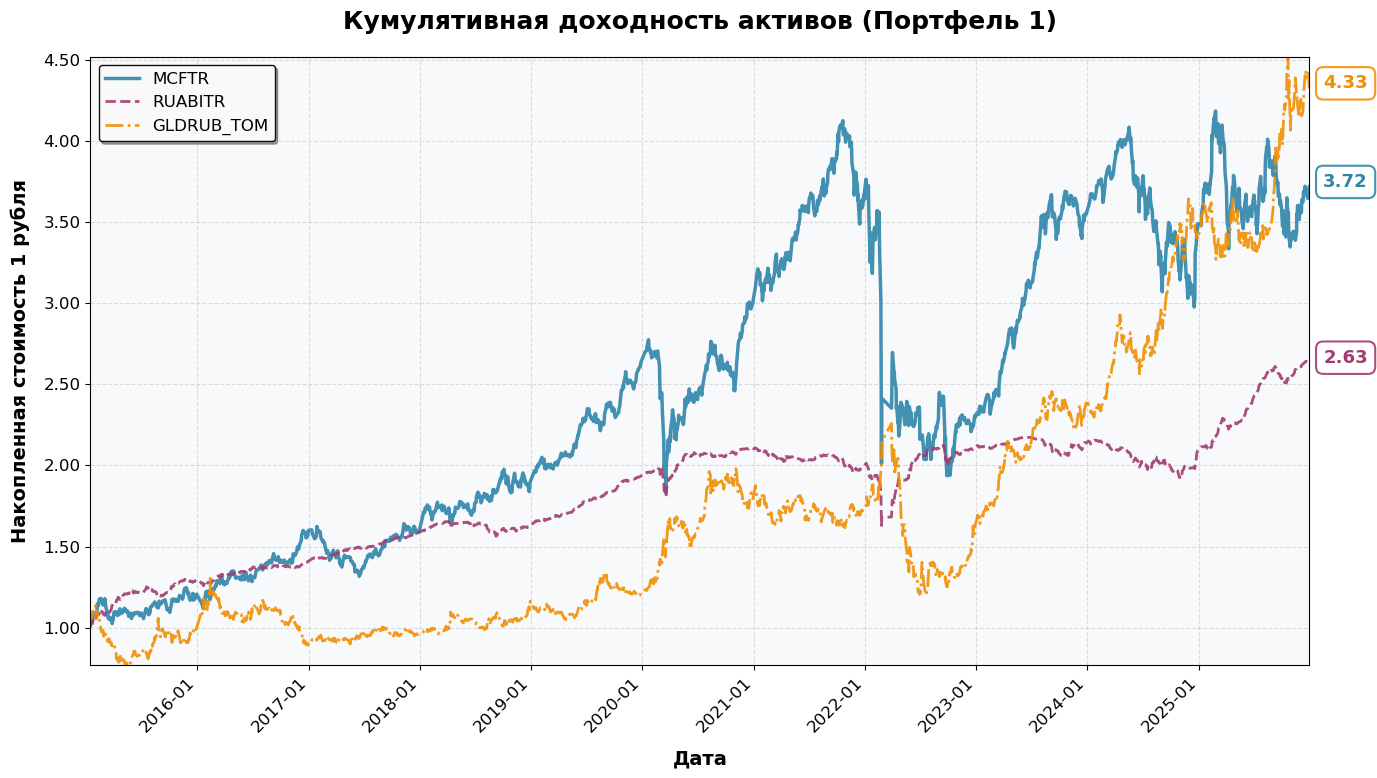

Итоговые кумулятивные доходности (Спец. 1):
  MCFTR: 3.7181
  RUABITR: 2.6340
  GLDRUB_TOM: 4.3261


In [49]:
cumulative_returns_1 = (1 + portfolio_1_daily_returns).cumprod()
plot_cumulative_returns(
    cumulative_returns_1,
    asset_names_1,
    portfolio_number=1,
    save_dir="figures",
    fmt="pdf",
)
 
print("Итоговые кумулятивные доходности (Спец. 1):")
for name in asset_names_1:
    print(f"  {name}: {cumulative_returns_1[name].iloc[-1]:.4f}")

In [50]:
analysis_results_1 = run_or_load(
    "analysis_results_1",
    run_comprehensive_analysis_for_all_metrics_modular,
    portfolio_daily_returns=portfolio_1_daily_returns,
    target_weights=initial_weights_1,
    asset_names=asset_names_1,
    risk_free_rate=risk_free_rate,
    mar=mar,
    cvar_alpha_01=0.01,
    cvar_alpha_05=0.05,
    omega_threshold=mar,
    max_weight_per_asset=0.6,
    verbose=True,
)

Загружен кэш: cache\analysis_results_1.pkl


In [51]:
bounds_1, bounds_summary_1, pooled_weights_1 = aggregate_bounds_from_window_results(
    analysis_results=analysis_results_1,
    asset_names=asset_names_1,
    metrics_to_use=core_metrics_for_bounds,
    lower_percentile=10,
    upper_percentile=90,
    successful_only=True,
)

bounds_summary_1

,Asset,Mean_Weight,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations
0,MCFTR,27.01,26.91,17.82,0.19,53.6,53.41,6048
1,RUABITR,37.90,42.50,23.88,0.00,60.0,60.00,6048
2,GLDRUB_TOM,35.09,35.41,20.30,6.51,60.0,53.49,6048


In [52]:
all_optimizations_1 = optimize_all_metrics_with_common_bounds(
    portfolio_daily_returns=portfolio_1_daily_returns,
    bounds_pct=bounds_1,
    asset_names=asset_names_1,
    risk_free_rate=risk_free_rate,
    mar=mar,
    verbose=False,
)

In [53]:
summary_static_1 = create_static_optimization_summary(
    all_optimizations=all_optimizations_1,
    asset_names=asset_names_1,
)

style_static_optimization_summary(summary_static_1, asset_names_1)

Metric,Metric_Value,MCFTR,RUABITR,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6203,15.95%,50.68%,33.37%,100.00%
Sortino Ratio,0.8121,30.44%,17.78%,51.78%,100.00%
Calmar Ratio,1.0228,7.41%,60.00%,32.59%,100.00%
CVaR Ratio (5%),0.0187,18.38%,52.90%,28.72%,100.00%
CVaR Ratio (1%),0.0103,18.29%,31.12%,50.59%,100.00%
Martin Ratio,1.8107,14.84%,60.00%,25.16%,100.00%
Omega Ratio,1.1172,19.06%,54.24%,26.70%,100.00%
Min Volatility,0.0904,12.10%,60.00%,27.90%,100.00%
Min Max Drawdown,0.1592,8.84%,60.00%,31.16%,100.00%


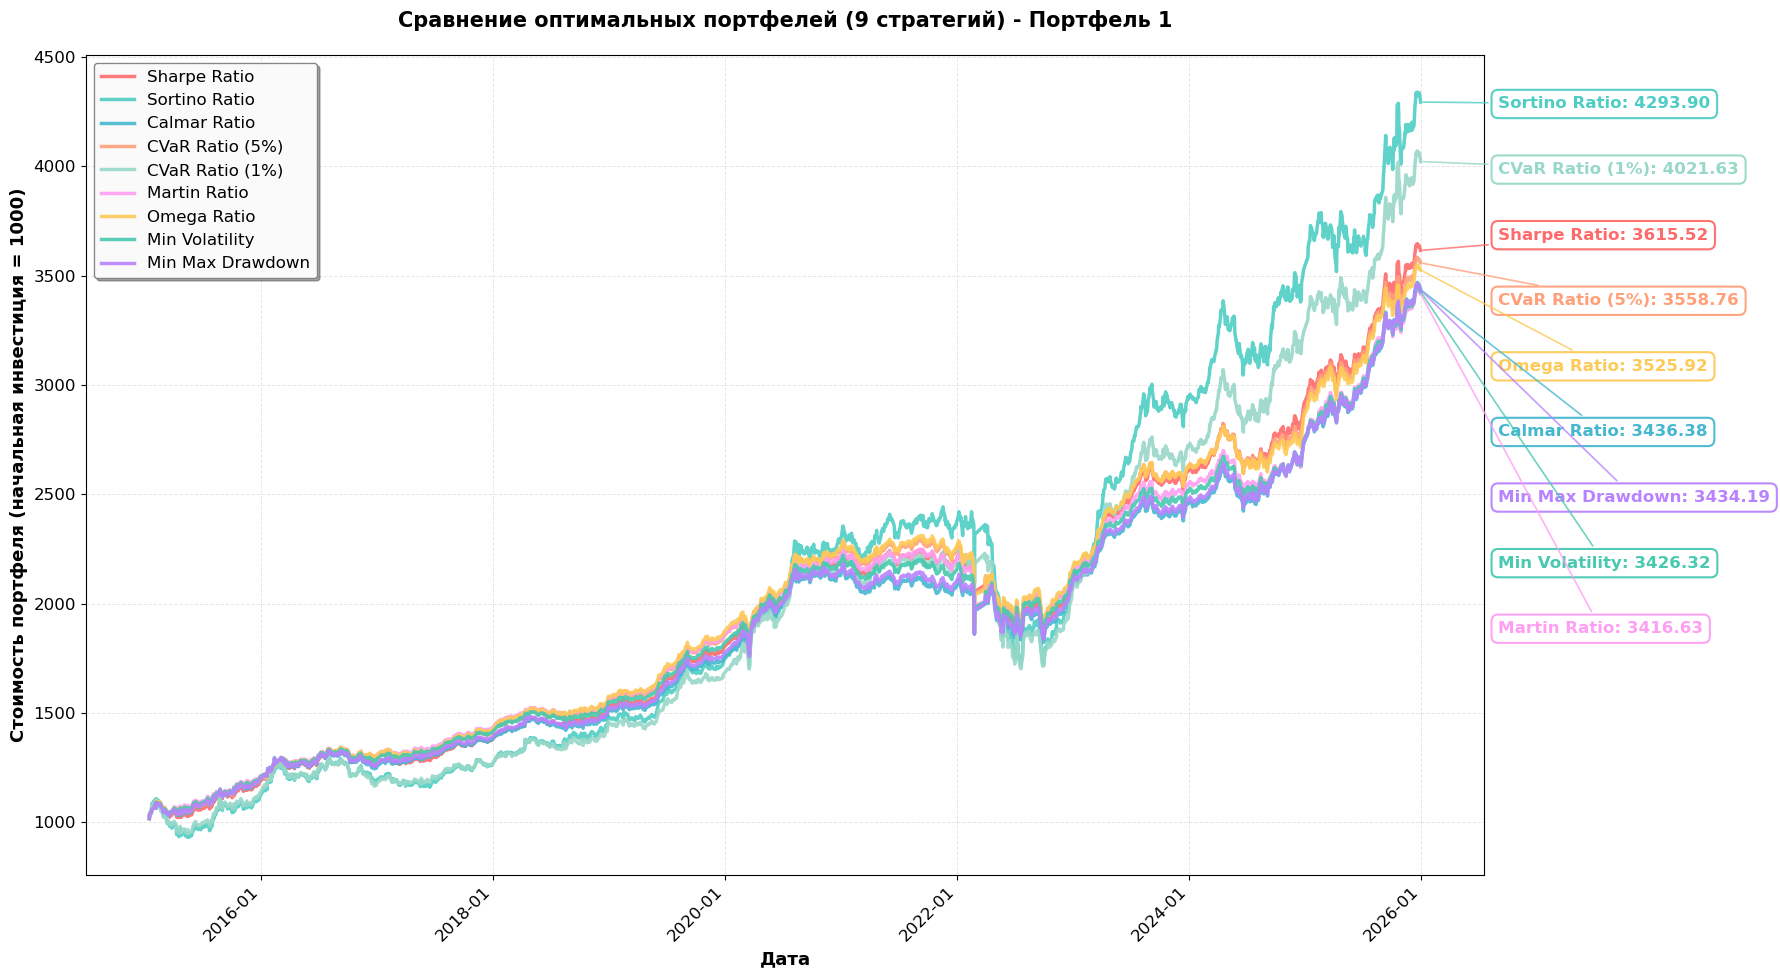


Итоговая стоимость портфелей (Спец. 1, начальная инвестиция = 1000):
  Sortino Ratio: 4293.90
  CVaR Ratio (1%): 4021.63
  Sharpe Ratio: 3615.52
  CVaR Ratio (5%): 3558.76
  Omega Ratio: 3525.92
  Calmar Ratio: 3436.38
  Min Max Drawdown: 3434.19
  Min Volatility: 3426.32
  Martin Ratio: 3416.63


In [54]:
portfolios_1 = {
    metric_name: result["best_weights"]
    for metric_name, result in all_optimizations_1.items()
    if result.get("best_weights") is not None
}

portfolio_values_1 = build_portfolio_value_series(
    portfolio_daily_returns=portfolio_1_daily_returns,
    portfolios=portfolios_1,
    initial_investment=1000,
)

filepath, final_values = plot_portfolio_comparison(
    portfolio_values=portfolio_values_1,
    portfolio_number=1,
    initial_investment=1000,
    save_dir="figures",
    filename="portfolio_comparison_1",
    fmt="pdf",
)
 
print("\nИтоговая стоимость портфелей (Спец. 1, начальная инвестиция = 1000):")
for name, val in portfolio_values_1.iloc[-1].sort_values(ascending=False).items():
    print(f"  {name}: {val:.2f}")

## 3.2. MCFTR, RGBITR и GLDRUB_TOM

In [55]:
asset_names_2 = ['MCFTR', 'RGBITR', 'GLDRUB_TOM']
initial_weights_2 = np.array([30, 55, 15]) / 100

In [56]:
portfolio_2_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RGBITR': df_RGBITR,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2064 дат, 3 активов: ['MCFTR', 'RGBITR', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [57]:
portfolio_2_daily_returns = portfolio_2_data.pct_change().dropna()

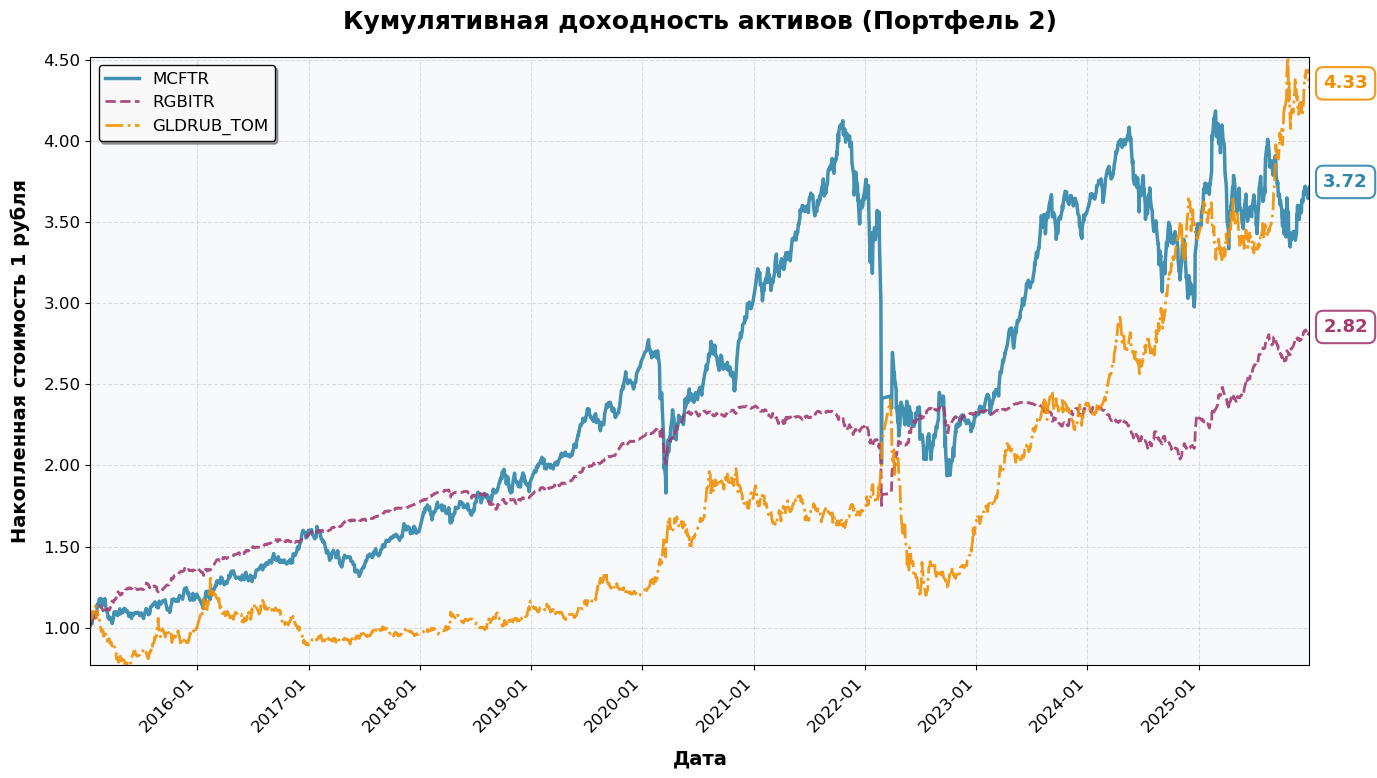

Итоговые кумулятивные доходности (Спец. 2):
  MCFTR: 3.7181
  RGBITR: 2.8236
  GLDRUB_TOM: 4.3261


In [58]:
cumulative_returns_2 = (1 + portfolio_2_daily_returns).cumprod()
plot_cumulative_returns(
    cumulative_returns_2,
    asset_names_2,
    portfolio_number=2,
    save_dir="figures",
    fmt="pdf",
)
 
print("Итоговые кумулятивные доходности (Спец. 2):")
for name in asset_names_2:
    print(f"  {name}: {cumulative_returns_2[name].iloc[-1]:.4f}")

In [59]:
analysis_results_2 = run_or_load(
    "analysis_results_2",
    run_comprehensive_analysis_for_all_metrics_modular,
    portfolio_daily_returns=portfolio_2_daily_returns,
    target_weights=initial_weights_2,
    asset_names=asset_names_2,
    risk_free_rate=risk_free_rate,
    mar=mar,
    cvar_alpha_01=0.01,
    cvar_alpha_05=0.05,
    omega_threshold=mar,
    max_weight_per_asset=0.6,
    verbose=True,
)

Загружен кэш: cache\analysis_results_2.pkl


In [60]:
bounds_2, bounds_summary_2, pooled_weights_2 = aggregate_bounds_from_window_results(
    analysis_results=analysis_results_2,
    asset_names=asset_names_2,
    metrics_to_use=core_metrics_for_bounds,
    lower_percentile=10,
    upper_percentile=90,
    successful_only=True,
)
bounds_summary_2

,Asset,Mean_Weight,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations
0,MCFTR,27.26,27.86,17.78,1.48,52.53,51.05,6048
1,RGBITR,36.80,40.00,24.39,0.00,60.00,60.00,6048
2,GLDRUB_TOM,35.93,36.36,20.10,7.74,60.00,52.26,6048


In [61]:
all_optimizations_2 = optimize_all_metrics_with_common_bounds(
    portfolio_daily_returns=portfolio_2_daily_returns,
    bounds_pct=bounds_2,
    asset_names=asset_names_2,
    risk_free_rate=risk_free_rate,
    mar=mar,
    verbose=False,
)
 
summary_static_2 = create_static_optimization_summary(
    all_optimizations=all_optimizations_2,
    asset_names=asset_names_2,
)
style_static_optimization_summary(summary_static_2, asset_names_2)

Metric,Metric_Value,MCFTR,RGBITR,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6362,12.92%,54.34%,32.73%,100.00%
Sortino Ratio,0.8272,19.67%,36.44%,43.89%,100.00%
Calmar Ratio,1.0216,4.95%,60.00%,35.05%,100.00%
CVaR Ratio (5%),0.0193,16.45%,54.51%,29.03%,100.00%
CVaR Ratio (1%),0.0105,9.57%,55.81%,34.62%,100.00%
Martin Ratio,1.8839,12.90%,60.00%,27.10%,100.00%
Omega Ratio,1.1240,15.44%,59.69%,24.87%,100.00%
Min Volatility,0.0978,11.01%,60.00%,28.99%,100.00%
Min Max Drawdown,0.1658,6.08%,60.00%,33.92%,100.00%


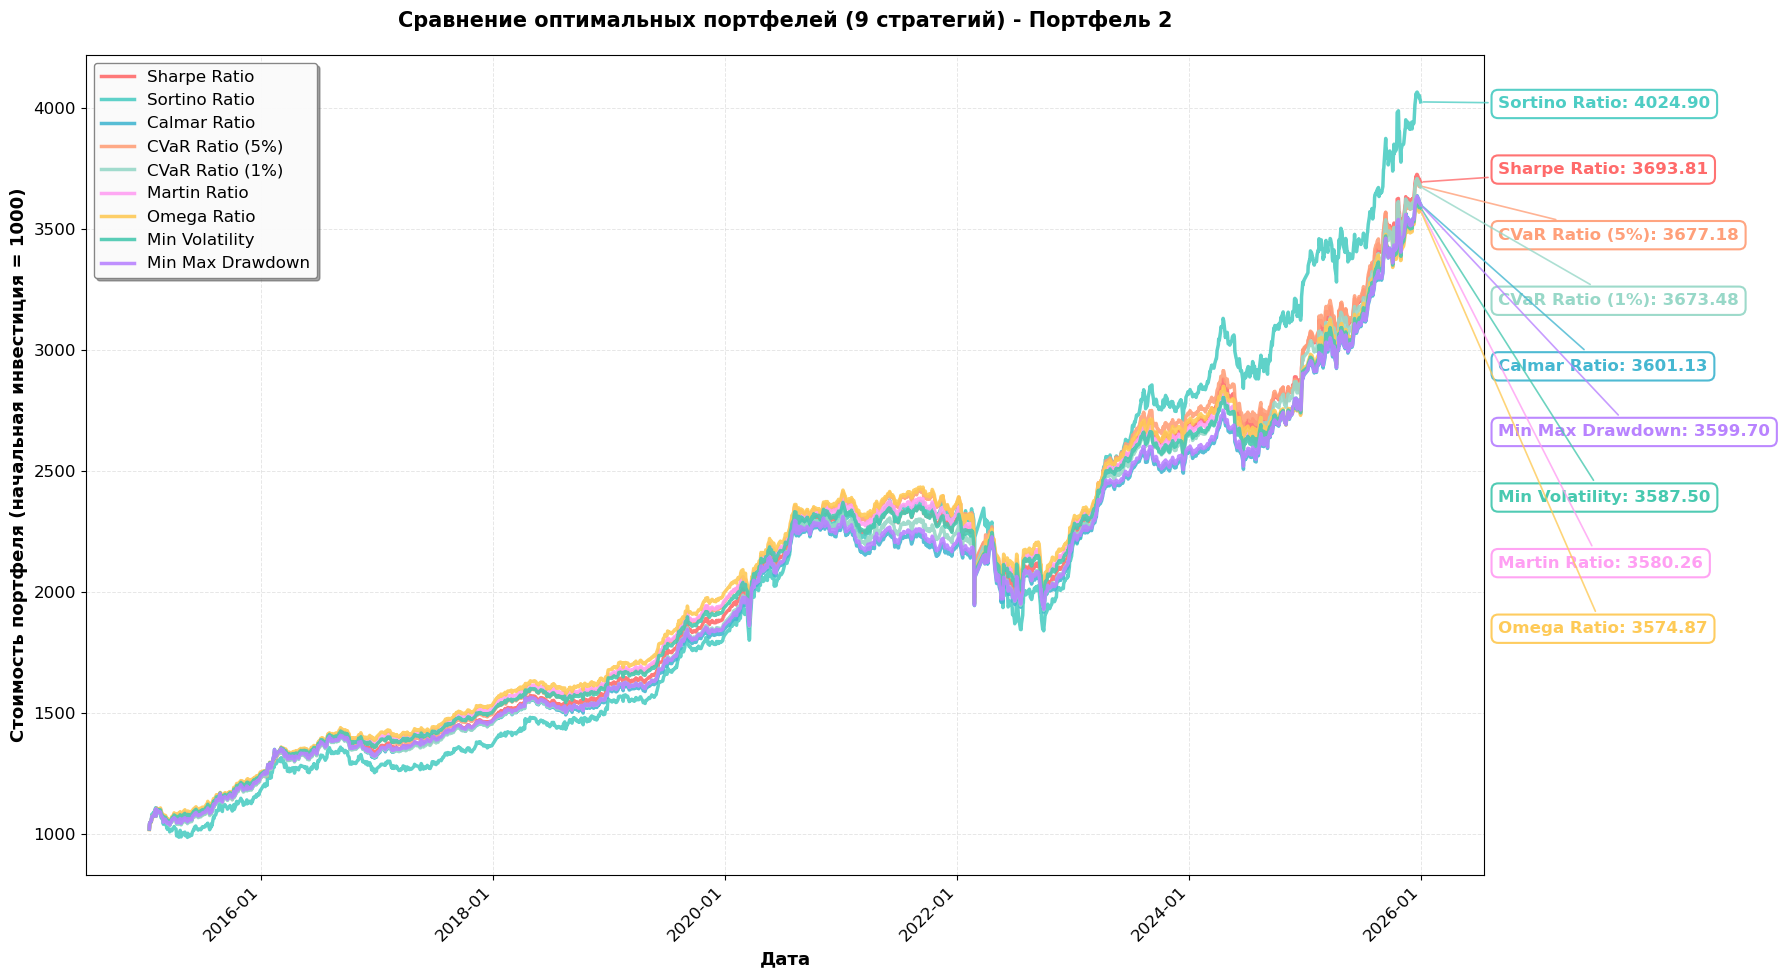


Итоговая стоимость портфелей (Спец. 2, начальная инвестиция = 1000):
  Sortino Ratio: 4024.90
  Sharpe Ratio: 3693.81
  CVaR Ratio (5%): 3677.18
  CVaR Ratio (1%): 3673.48
  Calmar Ratio: 3601.13
  Min Max Drawdown: 3599.70
  Min Volatility: 3587.50
  Martin Ratio: 3580.26
  Omega Ratio: 3574.87


In [62]:
portfolios_2 = {
    metric_name: result["best_weights"]
    for metric_name, result in all_optimizations_2.items()
    if result.get("best_weights") is not None
}

portfolio_values_2 = build_portfolio_value_series(
    portfolio_daily_returns=portfolio_2_daily_returns,
    portfolios=portfolios_2,
    initial_investment=1000,
)

filepath, final_values = plot_portfolio_comparison(
    portfolio_values=portfolio_values_2,
    portfolio_number=2,
    initial_investment=1000,
    save_dir="figures",
    filename="portfolio_comparison_2",
    fmt="pdf",
)
 
print("\nИтоговая стоимость портфелей (Спец. 2, начальная инвестиция = 1000):")
for name, val in portfolio_values_2.iloc[-1].sort_values(ascending=False).items():
    print(f"  {name}: {val:.2f}")

## 3.3. MCFTR, RUGBITR3Y, RUGBITR10Y, GLDRUB

In [63]:
asset_names_3 = ['MCFTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
initial_weights_3 = np.array([30, 15, 40, 15]) / 100

In [64]:
portfolio_3_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RUGBITR3Y': df_RUGBITR3Y,
    'RUGBITR10Y': df_RUGBITR10Y,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2064 дат, 4 активов: ['MCFTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [65]:
portfolio_3_daily_returns = portfolio_3_data.pct_change().dropna()

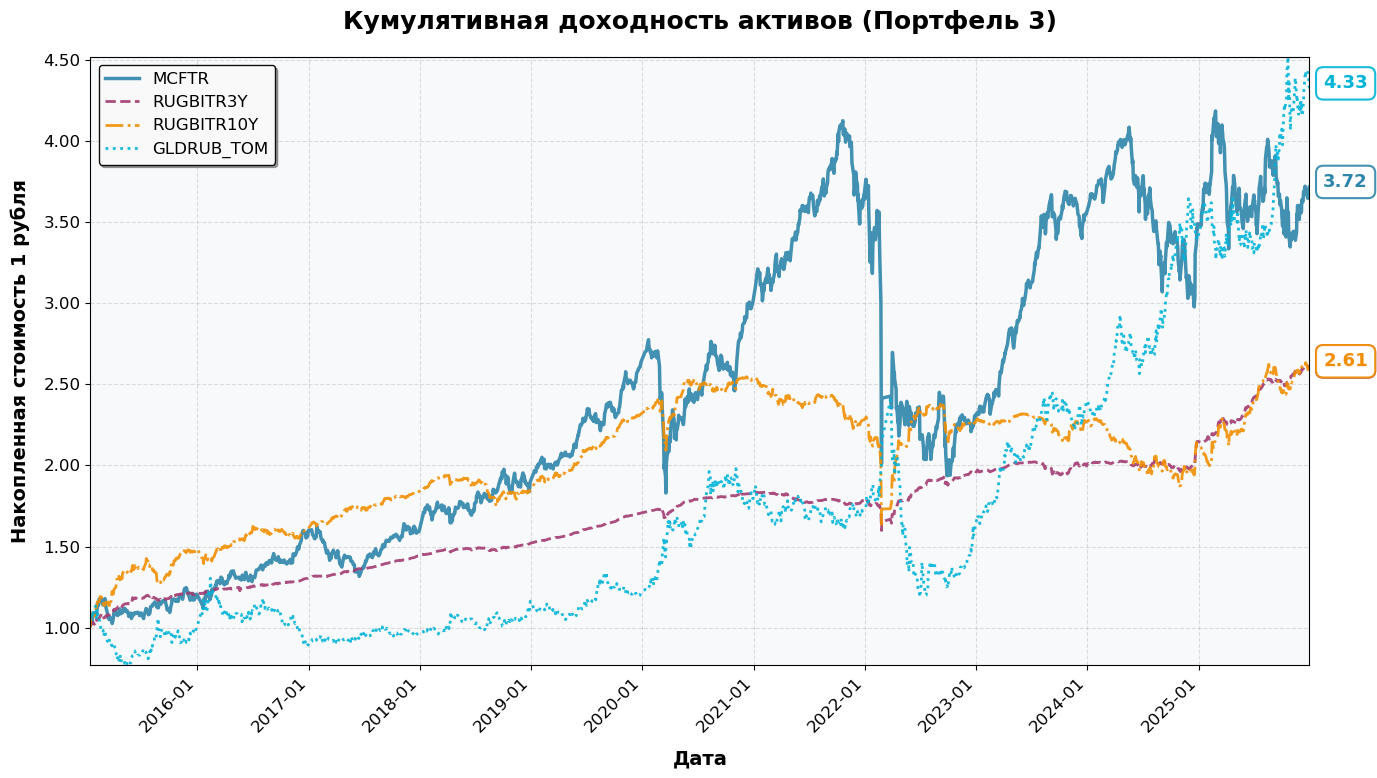

Итоговые кумулятивные доходности (Спец. 3):
  MCFTR: 3.7181
  RUGBITR3Y: 2.6105
  RUGBITR10Y: 2.6120
  GLDRUB_TOM: 4.3261


In [66]:
cumulative_returns_3 = (1 + portfolio_3_daily_returns).cumprod()
plot_cumulative_returns(
    cumulative_returns_3,
    asset_names_3,
    portfolio_number=3,
    save_dir="figures",
    fmt="pdf",
)
 
print("Итоговые кумулятивные доходности (Спец. 3):")
for name in asset_names_3:
    print(f"  {name}: {cumulative_returns_3[name].iloc[-1]:.4f}")

In [67]:
analysis_results_3 = run_or_load(
    "analysis_results_3",
    run_comprehensive_analysis_for_all_metrics_modular,
    portfolio_daily_returns=portfolio_3_daily_returns,
    target_weights=initial_weights_3,
    asset_names=asset_names_3,
    risk_free_rate=risk_free_rate,
    mar=mar,
    cvar_alpha_01=0.01,
    cvar_alpha_05=0.05,
    omega_threshold=mar,
    max_weight_per_asset=0.6,
    verbose=True,
)

Загружен кэш: cache\analysis_results_3.pkl


In [68]:
bounds_3, bounds_summary_3, pooled_weights_3 = aggregate_bounds_from_window_results(
    analysis_results=analysis_results_3,
    asset_names=asset_names_3,
    metrics_to_use=core_metrics_for_bounds,
    lower_percentile=10,
    upper_percentile=90,
    successful_only=True,
)

bounds_summary_3

,Asset,Mean_Weight,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations
0,MCFTR,21.05,14.07,20.13,0.00,53.66,53.66,6048
1,RUGBITR3Y,35.19,40.00,25.09,0.00,60.00,60.00,6048
2,RUGBITR10Y,13.82,8.17,15.84,0.00,35.49,35.49,6048
3,GLDRUB_TOM,29.94,25.78,21.29,2.52,60.00,57.48,6048


In [69]:
all_optimizations_3 = optimize_all_metrics_with_common_bounds(
    portfolio_daily_returns=portfolio_3_daily_returns,
    bounds_pct=bounds_3,
    asset_names=asset_names_3,
    risk_free_rate=risk_free_rate,
    mar=mar,
    verbose=False,
)

In [70]:
summary_static_3 = create_static_optimization_summary(
    all_optimizations=all_optimizations_3,
    asset_names=asset_names_3,
)

style_static_optimization_summary(summary_static_3, asset_names_3)

Metric,Metric_Value,MCFTR,RUGBITR3Y,RUGBITR10Y,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6344,13.91%,60.00%,0.00%,26.09%,100.00%
Sortino Ratio,0.8185,19.23%,43.95%,0.00%,36.82%,100.00%
Calmar Ratio,1.4364,1.71%,60.00%,10.76%,27.53%,100.00%
CVaR Ratio (5%),0.0198,15.98%,60.00%,1.30%,22.72%,100.00%
CVaR Ratio (1%),0.0107,9.97%,60.00%,0.00%,30.03%,100.00%
Martin Ratio,2.4700,14.70%,60.00%,3.87%,21.43%,100.00%
Omega Ratio,1.1197,15.92%,60.00%,3.33%,20.75%,100.00%
Min Volatility,0.0664,0.00%,60.00%,26.38%,13.62%,100.00%
Min Max Drawdown,0.1065,1.64%,60.00%,10.82%,27.54%,100.00%


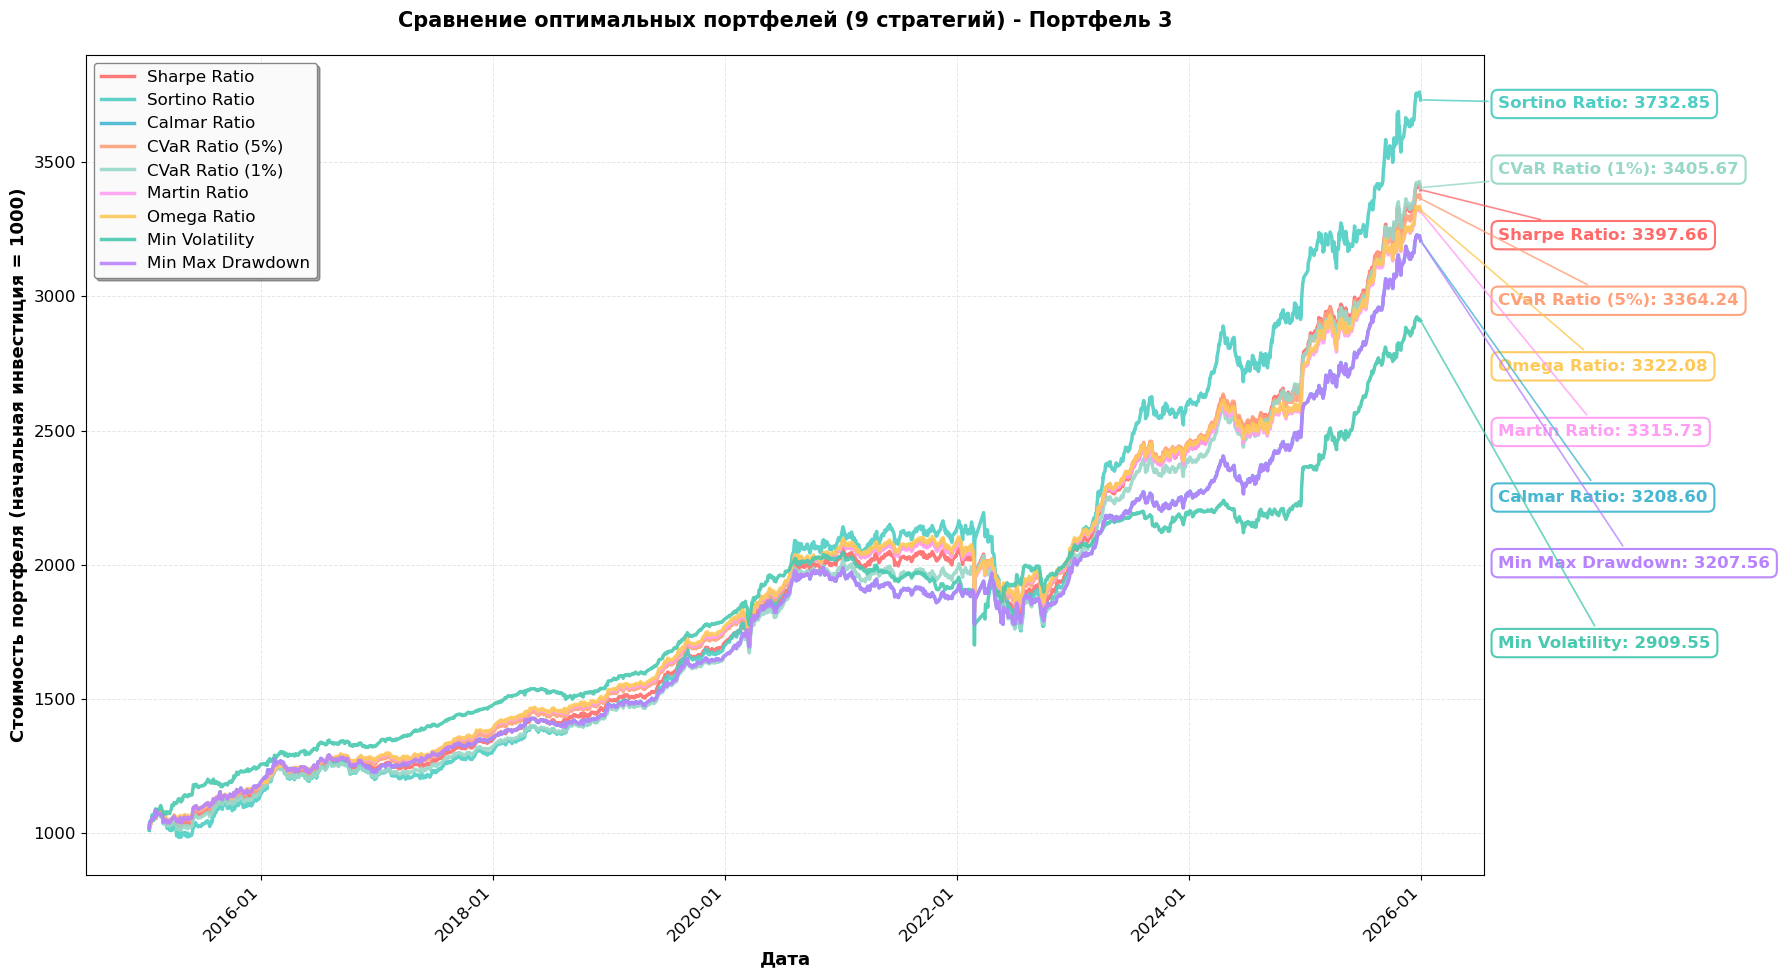


Итоговая стоимость портфелей (Спец. 3, начальная инвестиция = 1000):
  Sortino Ratio: 3732.85
  CVaR Ratio (1%): 3405.67
  Sharpe Ratio: 3397.66
  CVaR Ratio (5%): 3364.24
  Omega Ratio: 3322.08
  Martin Ratio: 3315.73
  Calmar Ratio: 3208.60
  Min Max Drawdown: 3207.56
  Min Volatility: 2909.55


In [71]:
portfolios_3 = {
    metric_name: result["best_weights"]
    for metric_name, result in all_optimizations_3.items()
    if result.get("best_weights") is not None
}

portfolio_values_3 = build_portfolio_value_series(
    portfolio_daily_returns=portfolio_3_daily_returns,
    portfolios=portfolios_3,
    initial_investment=1000,
)

filepath, final_values = plot_portfolio_comparison(
    portfolio_values=portfolio_values_3,
    portfolio_number=3,
    initial_investment=1000,
    save_dir="figures",
    filename="portfolio_comparison_3",
    fmt="pdf",
)
 
print("\nИтоговая стоимость портфелей (Спец. 3, начальная инвестиция = 1000):")
for name, val in portfolio_values_3.iloc[-1].sort_values(ascending=False).items():
    print(f"  {name}: {val:.2f}")

## 3.4. MEBCTR, RUGBITR3Y, RUGBITR10Y и GLDRUB_TOM

In [72]:
asset_names_4 = ['MEBCTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
initial_weights_4 = np.array([30, 15, 40, 15]) / 100

In [73]:
portfolio_4_data = build_synced_portfolio({
    'MEBCTR': df_MEBCTR,
    'RUGBITR3Y': df_RUGBITR3Y,
    'RUGBITR10Y': df_RUGBITR10Y,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2063 дат, 4 активов: ['MEBCTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [74]:
portfolio_4_daily_returns = portfolio_4_data.pct_change().dropna()

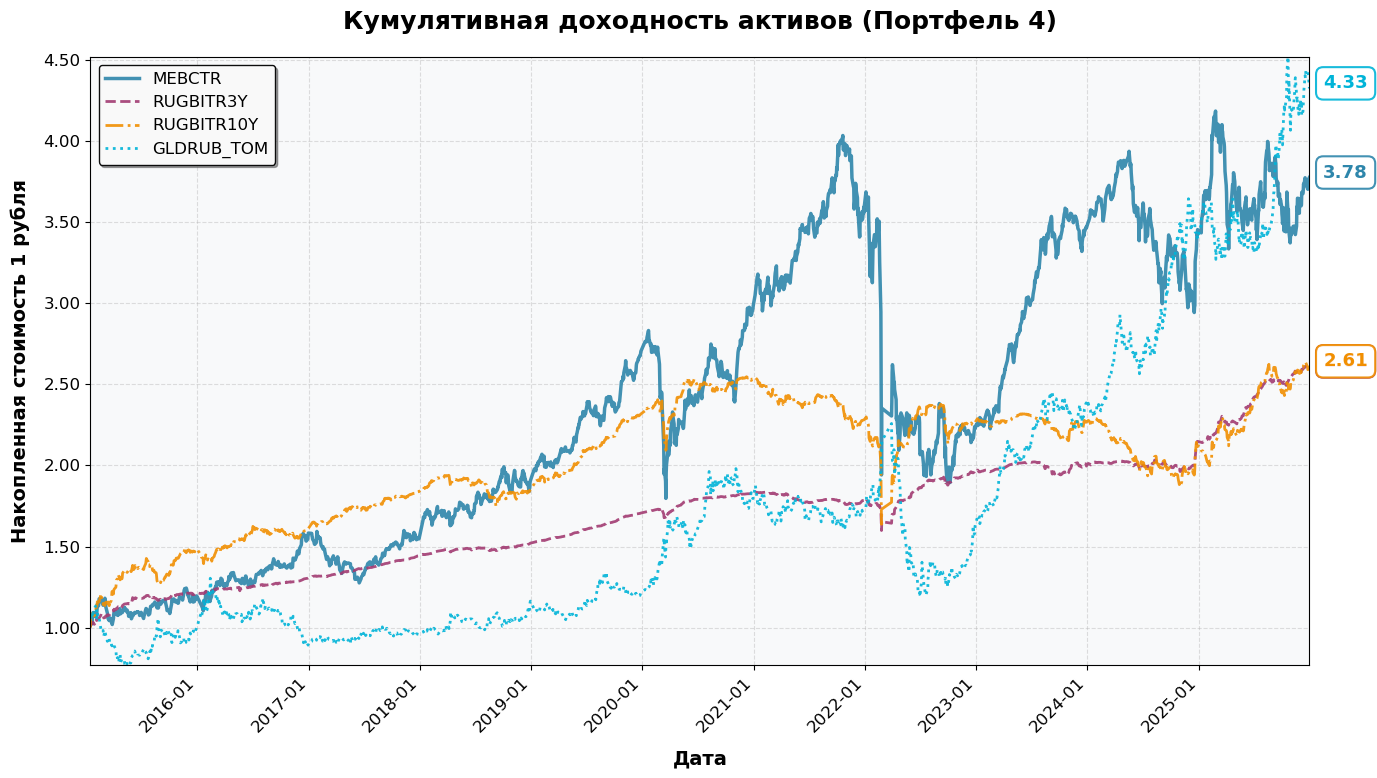

Итоговые кумулятивные доходности (Спец. 4):
  MEBCTR: 3.7762
  RUGBITR3Y: 2.6105
  RUGBITR10Y: 2.6120
  GLDRUB_TOM: 4.3261


In [75]:
cumulative_returns_4 = (1 + portfolio_4_daily_returns).cumprod()
plot_cumulative_returns(
    cumulative_returns_4,
    asset_names_4,
    portfolio_number=4,
    save_dir="figures",
    fmt="pdf",
)
 
print("Итоговые кумулятивные доходности (Спец. 4):")
for name in asset_names_4:
    print(f"  {name}: {cumulative_returns_4[name].iloc[-1]:.4f}")

In [76]:
analysis_results_4 = run_or_load(
    "analysis_results_4",
    run_comprehensive_analysis_for_all_metrics_modular,
    portfolio_daily_returns=portfolio_4_daily_returns,
    target_weights=initial_weights_4,
    asset_names=asset_names_4,
    risk_free_rate=risk_free_rate,
    mar=mar,
    cvar_alpha_01=0.01,
    cvar_alpha_05=0.05,
    omega_threshold=mar,
    max_weight_per_asset=0.6,
    verbose=True,
)

Загружен кэш: cache\analysis_results_4.pkl


In [77]:
bounds_4, bounds_summary_4, pooled_weights_4 = aggregate_bounds_from_window_results(
    analysis_results=analysis_results_4,
    asset_names=asset_names_4,
    metrics_to_use=core_metrics_for_bounds,
    lower_percentile=10,
    upper_percentile=90,
    successful_only=True,
)

bounds_summary_4

,Asset,Mean_Weight,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations
0,MEBCTR,19.90,13.70,19.43,0.0,50.11,50.11,6048
1,RUGBITR3Y,35.63,40.00,24.68,0.0,60.00,60.00,6048
2,RUGBITR10Y,14.13,9.53,16.25,0.0,36.87,36.87,6048
3,GLDRUB_TOM,30.34,26.02,21.45,2.4,60.00,57.60,6048


In [78]:
all_optimizations_4 = optimize_all_metrics_with_common_bounds(
    portfolio_daily_returns=portfolio_4_daily_returns,
    bounds_pct=bounds_4,
    asset_names=asset_names_4,
    risk_free_rate=risk_free_rate,
    mar=mar,
    verbose=False,
)

In [79]:
summary_static_4 = create_static_optimization_summary(
    all_optimizations=all_optimizations_4,
    asset_names=asset_names_4,
)
style_static_optimization_summary(summary_static_4, asset_names_4)

Metric,Metric_Value,MEBCTR,RUGBITR3Y,RUGBITR10Y,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6469,13.39%,60.00%,0.00%,26.61%,100.00%
Sortino Ratio,0.8331,18.06%,46.21%,0.00%,35.72%,100.00%
Calmar Ratio,1.4237,1.86%,60.00%,10.78%,27.36%,100.00%
CVaR Ratio (5%),0.0202,15.55%,60.00%,0.88%,23.57%,100.00%
CVaR Ratio (1%),0.0112,10.51%,60.00%,0.00%,29.49%,100.00%
Martin Ratio,2.4292,15.26%,60.00%,3.47%,21.28%,100.00%
Omega Ratio,1.1210,15.77%,60.00%,3.11%,21.12%,100.00%
Min Volatility,0.0659,0.00%,60.00%,25.89%,14.11%,100.00%
Min Max Drawdown,0.1074,1.46%,60.00%,11.10%,27.43%,100.00%


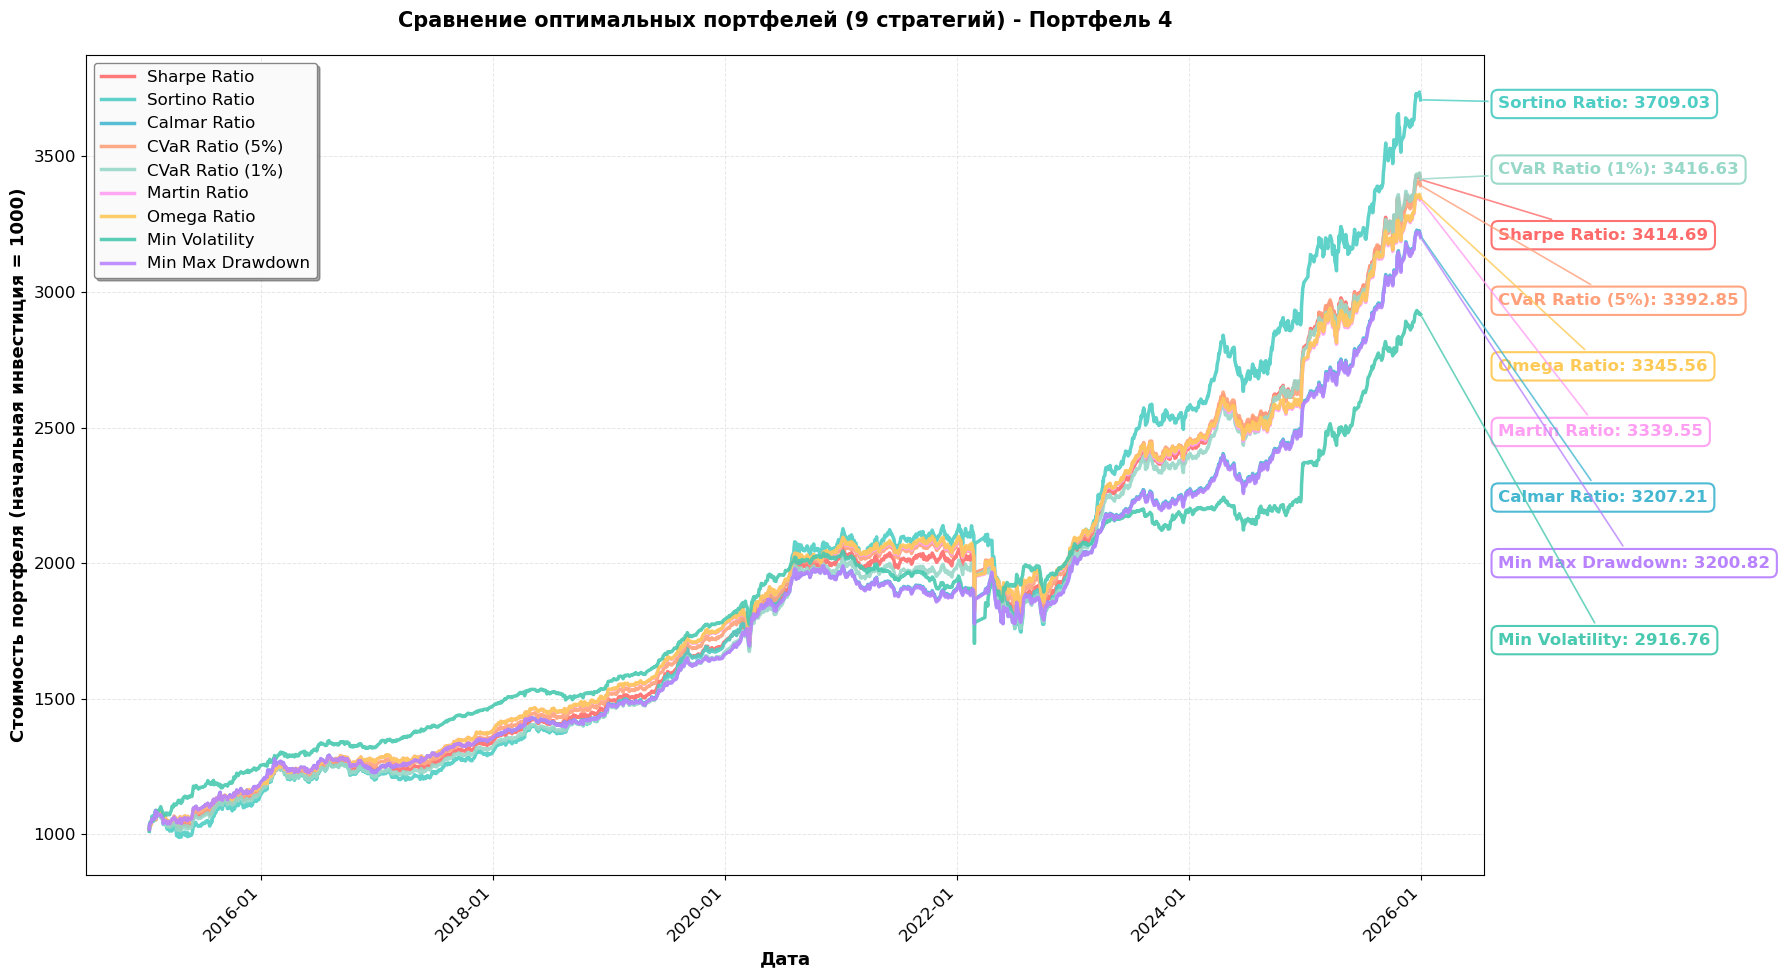


Итоговая стоимость портфелей (Спец. 4, начальная инвестиция = 1000):
  Sortino Ratio: 3709.03
  CVaR Ratio (1%): 3416.63
  Sharpe Ratio: 3414.69
  CVaR Ratio (5%): 3392.85
  Omega Ratio: 3345.56
  Martin Ratio: 3339.55
  Calmar Ratio: 3207.21
  Min Max Drawdown: 3200.82
  Min Volatility: 2916.76


In [80]:
portfolios_4 = {
    metric_name: result["best_weights"]
    for metric_name, result in all_optimizations_4.items()
    if result.get("best_weights") is not None
}

portfolio_values_4 = build_portfolio_value_series(
    portfolio_daily_returns=portfolio_4_daily_returns,
    portfolios=portfolios_4,
    initial_investment=1000,
)

filepath, final_values = plot_portfolio_comparison(
    portfolio_values=portfolio_values_4,
    portfolio_number=4,
    initial_investment=1000,
    save_dir="figures",
    filename="portfolio_comparison_4",
    fmt="pdf",
)
 
print("\nИтоговая стоимость портфелей (Спец. 4, начальная инвестиция = 1000):")
for name, val in portfolio_values_4.iloc[-1].sort_values(ascending=False).items():
    print(f"  {name}: {val:.2f}")

## 3.5. Сравнение результатов 

In [81]:
def compute_all_metrics_for_weights(
    portfolio_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float = 0.05,
    periods_per_year: int = 252,
) -> dict:
    """
    Считает все метрики для заданных весов на полном периоде.
    """
    w = np.asarray(weights, dtype=float)
    port_ret = portfolio_daily_returns @ w
    port_ret_series = pd.Series(port_ret, index=portfolio_daily_returns.index)

    # Wealth curve
    wealth = (1 + port_ret_series).cumprod()
    n = len(port_ret_series)
    cagr = float(wealth.iloc[-1] ** (periods_per_year / n) - 1.0)

    # Drawdowns
    running_max = wealth.cummax()
    drawdowns = 1.0 - wealth / running_max
    mdd = float(drawdowns.max())

    # Volatility
    vol = float(port_ret_series.std(ddof=1) * np.sqrt(periods_per_year))

    # Sharpe
    rf_daily = risk_free_rate / periods_per_year
    excess_mean = (port_ret_series - rf_daily).mean()
    daily_vol = port_ret_series.std(ddof=1)
    sharpe = float((excess_mean / daily_vol) * np.sqrt(periods_per_year)) if daily_vol > 0 else np.nan

    # Sortino
    mar_daily = mar / periods_per_year
    shortfalls = np.minimum(port_ret_series - mar_daily, 0.0)
    downside_dev = np.sqrt(np.mean(shortfalls ** 2))
    if downside_dev > 0:
        sortino = float(
            ((port_ret_series.mean() - mar_daily) * periods_per_year)
            / (downside_dev * np.sqrt(periods_per_year))
        )
    else:
        sortino = np.nan

    # Calmar
    calmar = float(cagr / mdd) if mdd > 0 else np.nan

    # CVaR ratio
    losses = -port_ret_series.to_numpy()
    var_thresh = np.quantile(losses, 1 - cvar_alpha)
    tail = losses[losses >= var_thresh]
    cvar_val = float(tail.mean()) if len(tail) > 0 else np.nan
    cvar_ratio = float((port_ret_series.mean() - rf_daily) / cvar_val) if cvar_val > 0 else np.nan

    # Martin ratio
    ui = float(np.sqrt(np.mean(drawdowns ** 2)))
    martin = float((cagr - risk_free_rate) / ui) if ui > 0 else np.nan

    # Omega
    omega_daily = mar / periods_per_year
    gains = np.maximum(port_ret_series - omega_daily, 0.0).mean()
    loss_omega = np.maximum(omega_daily - port_ret_series, 0.0).mean()
    omega = float(gains / loss_omega) if loss_omega > 0 else np.nan

    return {
        "CAGR": cagr * 100,
        "Volatility": vol * 100,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Calmar": calmar,
        "MDD": mdd * 100,
        "CVaR Ratio": cvar_ratio,
        "Martin Ratio": martin,
        "Omega": omega,
    }

In [82]:
def build_comparison_table(
    specifications: dict,
    risk_free_rate: float,
    mar: float,
) -> pd.DataFrame:
    """
    Строит сводную таблицу метрик для всех спецификаций и бенчмарков.

    Parameters
    ----------
    specifications : dict
        {label: (portfolio_daily_returns, weights)}
    """
    rows = []
    for label, (returns_df, weights) in specifications.items():
        metrics = compute_all_metrics_for_weights(
            returns_df, weights, risk_free_rate, mar,
        )
        metrics["Portfolio"] = label
        rows.append(metrics)

    df = pd.DataFrame(rows)
    cols = ["Portfolio"] + [c for c in df.columns if c != "Portfolio"]
    df = df[cols]

    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].round(4)

    return df

In [83]:
def fetch_cbr_deposit_rates(
    url: str = (
        'https://www.cbr.ru/statistics/avgprocstav/'
        '?UniDbQuery.Posted=True'
        '&UniDbQuery.From=1.01.2015'
        '&UniDbQuery.To=3.12.2025'
    ),
) -> tuple[dict, int]:
    """
    Загружает данные о максимальной процентной ставке по депозитам
    физических лиц (топ-10 банков) с сайта ЦБ РФ.

    Данные публикуются подекадно (3 раза в месяц).
    Функция усредняет декады в месячные ставки.

    Parameters
    ----------
    url : str
        Полная ссылка на страницу ЦБ с параметрами периода.

    Returns
    -------
    tuple[dict, int]
        ({"YYYY-MM": средняя ставка за месяц (%)}, число подекадных наблюдений)
    """
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    response.encoding = 'utf-8'

    soup = BeautifulSoup(response.text, 'html.parser')

    table = soup.find('table', class_='data')
    if table is None:
        for t in soup.find_all('table'):
            headers = [th.get_text(strip=True) for th in t.find_all('th')]
            if any('Декада' in h for h in headers) or any('Ставка' in h for h in headers):
                table = t
                break

    if table is None:
        raise ValueError(
            'Не удалось найти таблицу на странице ЦБ. '
            'Возможно, изменилась структура сайта.'
        )

    month_data = defaultdict(list)

    for row in table.find_all('tr'):
        cells = row.find_all('td')
        if len(cells) < 2:
            continue

        decade_label = cells[0].get_text(strip=True)
        rate_text = cells[1].get_text(strip=True)

        parts = decade_label.split('.')
        if len(parts) != 3:
            continue

        try:
            month = int(parts[1])
            year = int(parts[2])
            rate = float(rate_text.replace(',', '.'))
        except (ValueError, IndexError):
            continue

        key = f'{year}-{month:02d}'
        month_data[key].append(rate)

    if not month_data:
        raise ValueError('Таблица найдена, но не удалось распарсить ни одной строки.')

    n_observations = sum(len(vals) for vals in month_data.values())

    monthly_rates = {
        key: round(sum(vals) / len(vals), 2)
        for key, vals in sorted(month_data.items())
    }

    return monthly_rates, n_observations

In [84]:
def build_deposit_daily_returns(
    portfolio_index: pd.DatetimeIndex,
    deposit_rates: dict,
    trading_days: int = 252,
) -> pd.Series:
    """
    Строит ряд дневных доходностей депозитного бенчмарка.

    Для каждого торгового дня берётся средняя максимальная ставка
    по депозитам за соответствующий месяц и пересчитывается
    в дневную доходность:
        r_daily = (1 + r_annual)^(1/trading_days) - 1
    """
    daily_returns = pd.Series(index=portfolio_index, dtype=float, name='Deposit')
    for date in portfolio_index:
        key = f'{date.year}-{date.month:02d}'
        annual_rate = deposit_rates.get(key, 0.0) / 100
        daily_returns[date] = (1 + annual_rate) ** (1 / trading_days) - 1
    return daily_returns

In [85]:
deposit_monthly_rates_pct, n_obs = fetch_cbr_deposit_rates()
avg_deposit_rate = np.mean(list(deposit_monthly_rates_pct.values()))
print(f'Загружено {n_obs} подекадных наблюдений ({len(deposit_monthly_rates_pct)} месяцев)')
print(f'Период: {min(deposit_monthly_rates_pct.keys())} — {max(deposit_monthly_rates_pct.keys())}')
print(f'Средняя максимальная ставка по депозитам: {avg_deposit_rate:.2f}%')

Загружено 396 подекадных наблюдений (132 месяцев)
Период: 2015-01 — 2025-12
Средняя максимальная ставка по депозитам: 9.71%


In [86]:
def extract_median_weights(bounds_summary: pd.DataFrame) -> np.ndarray:
    """Извлекает медианные веса из bounds_summary и нормализует."""
    w = bounds_summary["Median_Weight"].to_numpy(dtype=float) / 100
    return w / w.sum()
 
median_w1 = extract_median_weights(bounds_summary_1)
median_w2 = extract_median_weights(bounds_summary_2)
median_w3 = extract_median_weights(bounds_summary_3)
median_w4 = extract_median_weights(bounds_summary_4)
 
print("\nМедианные веса (нормализованные):")
for i, (w, names) in enumerate([
    (median_w1, asset_names_1),
    (median_w2, asset_names_2),
    (median_w3, asset_names_3),
    (median_w4, asset_names_4),
], 1):
    parts = ", ".join(f"{n}: {v:.2f}%" for n, v in zip(names, w * 100))
    print(f"  Спецификация {i}: [{parts}], сумма = {w.sum()*100:.2f}%")


Медианные веса (нормализованные):
  Спецификация 1: [MCFTR: 25.67%, RUABITR: 40.55%, GLDRUB_TOM: 33.78%], сумма = 100.00%
  Спецификация 2: [MCFTR: 26.73%, RGBITR: 38.38%, GLDRUB_TOM: 34.89%], сумма = 100.00%
  Спецификация 3: [MCFTR: 15.99%, RUGBITR3Y: 45.44%, RUGBITR10Y: 9.28%, GLDRUB_TOM: 29.29%], сумма = 100.00%
  Спецификация 4: [MEBCTR: 15.35%, RUGBITR3Y: 44.82%, RUGBITR10Y: 10.68%, GLDRUB_TOM: 29.15%], сумма = 100.00%


In [87]:
n3 = len(asset_names_3)
equal_w3 = np.ones(n3) / n3
only_equity = np.array([1.0, 0.0, 0.0, 0.0])
only_bond_short = np.array([0.0, 1.0, 0.0, 0.0])
only_bond_long = np.array([0.0, 0.0, 1.0, 0.0])
only_gold = np.array([0.0, 0.0, 0.0, 1.0])
 
deposit_daily_ret = build_deposit_daily_returns(
    portfolio_3_daily_returns.index,
    deposit_monthly_rates_pct,
)
deposit_returns_df = deposit_daily_ret.to_frame('Deposit')
 
portfolio_60_40_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RGBITR': df_RGBITR,
})
portfolio_60_40_returns = portfolio_60_40_data.pct_change().dropna()
weights_60_40 = np.array([0.60, 0.40])
weights_dalio = initial_weights_3
 
print(f"\nВеса Далио (оригинал): {weights_dalio * 100}%")
print(f"Равновзвешенные (Спец. 3): {equal_w3 * 100}%")

Синхронизированный портфель: 2762 дат, 2 активов: ['MCFTR', 'RGBITR']
Период: 2015-01-05 - 2025-12-30

Веса Далио (оригинал): [30. 15. 40. 15.]%
Равновзвешенные (Спец. 3): [25. 25. 25. 25.]%


In [88]:
comparison = build_comparison_table(
    specifications={
        "Спец. 1 (медиана)": (portfolio_1_daily_returns, median_w1),
        "Спец. 2 (медиана)": (portfolio_2_daily_returns, median_w2),
        "Спец. 3 (медиана)": (portfolio_3_daily_returns, median_w3),
        "Спец. 4 (медиана)": (portfolio_4_daily_returns, median_w4),
        "Равновзвешенный (Спец.3)": (portfolio_3_daily_returns, equal_w3),
        "Депозит (макс. ставка)": (deposit_returns_df, np.array([1.0])),
        "100% Акции (MCFTR)": (portfolio_3_daily_returns, only_equity),
        "100% Облиг. кратк.": (portfolio_3_daily_returns, only_bond_short),
        "100% Облиг. длин.": (portfolio_3_daily_returns, only_bond_long),
        "100% Золото": (portfolio_3_daily_returns, only_gold),
        "60/40 (MCFTR/RGBITR)": (portfolio_60_40_returns, weights_60_40),
        "Далио оригинал (Спец.3)": (portfolio_3_daily_returns, weights_dalio),
    },
    risk_free_rate=risk_free_rate,
    mar=mar,
)
 
print("\n" + comparison.to_string(index=False))


               Portfolio    CAGR  Volatility  Sharpe  Sortino  Calmar     MDD  CVaR Ratio  Martin Ratio  Omega
       Спец. 1 (медиана) 17.7387     11.6357  0.6121   0.7796  0.7743 22.9099      0.0185        1.5119 1.1160
       Спец. 2 (медиана) 18.3135     12.4005  0.6211   0.8004  0.7576 24.1740      0.0188        1.5236 1.1200
       Спец. 3 (медиана) 16.6089      9.5601  0.6206   0.7921  1.0942 15.1797      0.0189        2.0397 1.1165
       Спец. 4 (медиана) 16.6358      9.4553  0.6289   0.7998  1.0699 15.5484      0.0192        1.9986 1.1176
Равновзвешенный (Спец.3) 16.9191     11.1498  0.5714   0.7038  0.8011 21.1193      0.0177        1.4852 1.1135
  Депозит (макс. ставка)  9.6020      0.2565 -2.8285  -6.5803     NaN  0.0000         NaN           NaN 0.4730
      100% Акции (MCFTR) 17.3995     26.6060  0.3710   0.4617  0.3280 53.0501      0.0107        0.4359 1.0739
      100% Облиг. кратк. 12.4355      5.0701  0.3860   0.3570  0.9611 12.9385      0.0124        1.7698 1.0736


In [89]:
stability = pd.DataFrame({
    "Спецификация": [f"Спец. {i}" for i in range(1, 5)],
    "Средняя ширина диапазона": [
        bounds_summary_1["Range_Width"].mean(),
        bounds_summary_2["Range_Width"].mean(),
        bounds_summary_3["Range_Width"].mean(),
        bounds_summary_4["Range_Width"].mean(),
    ],
    "Число активов": [3, 3, 4, 4],
})

print("Устойчивость весов (средняя ширина диапазона, п.п.):")
print(stability.to_string(index=False))

Устойчивость весов (средняя ширина диапазона, п.п.):
Спецификация  Средняя ширина диапазона  Число активов
     Спец. 1                 55.633333              3
     Спец. 2                 54.436667              3
     Спец. 3                 51.657500              4
     Спец. 4                 51.145000              4


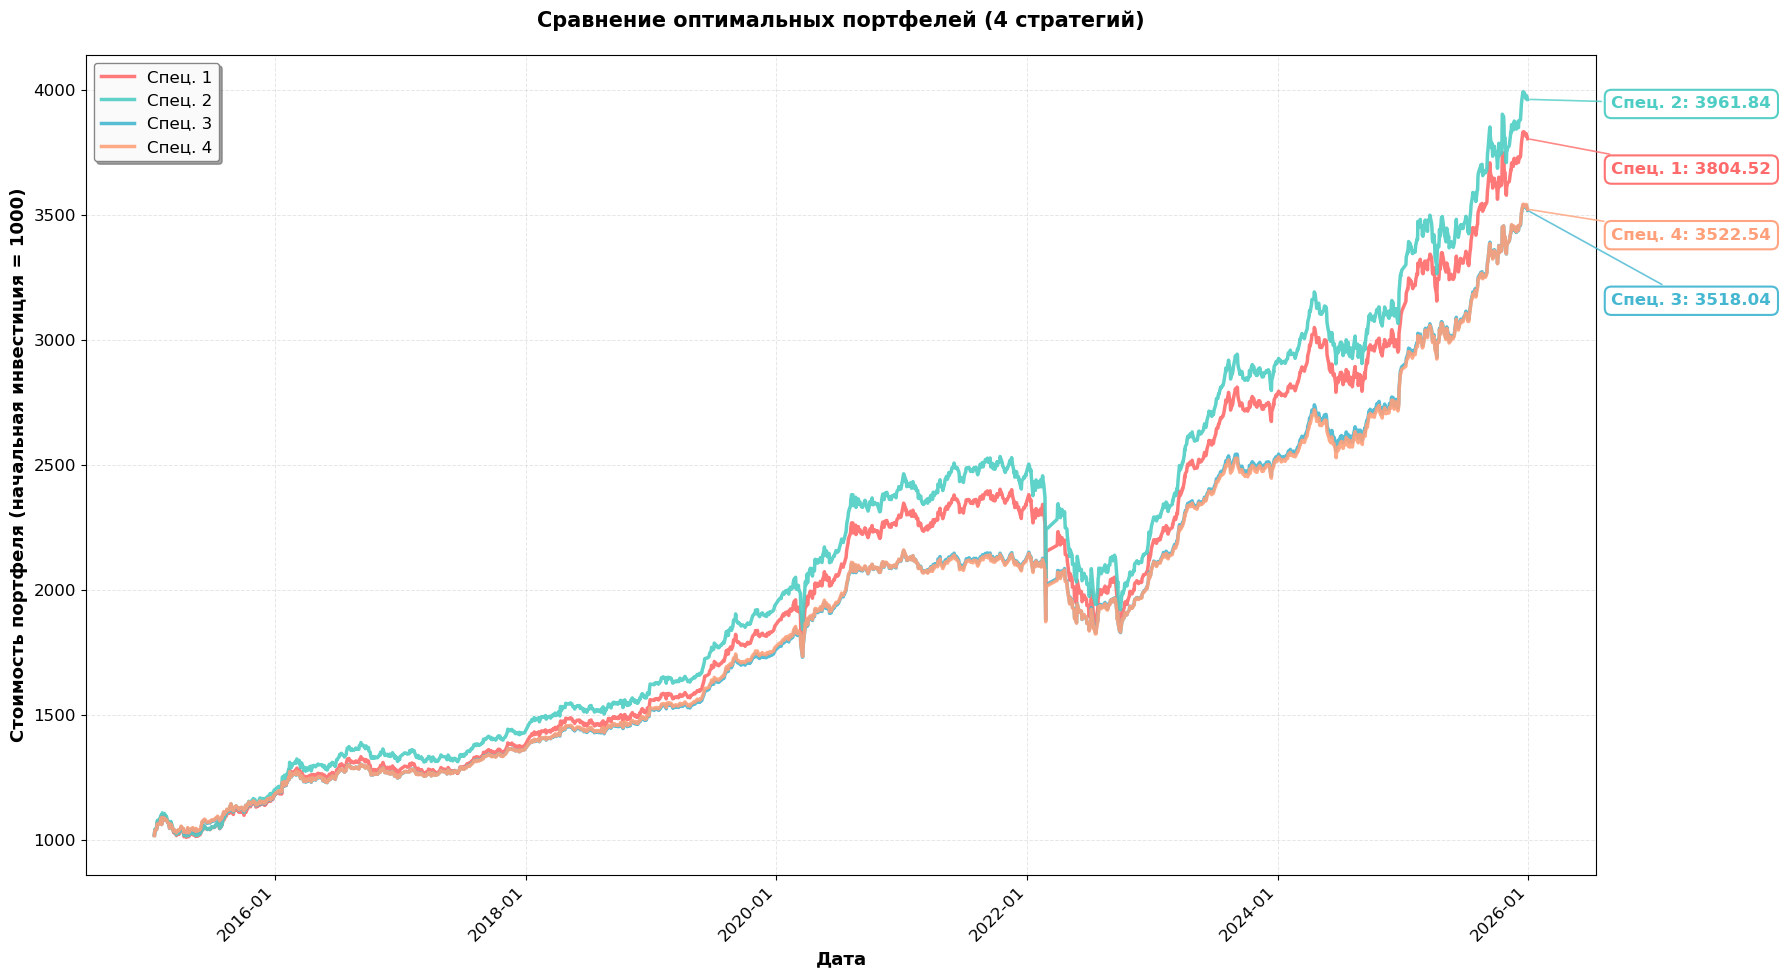


График 1 — Итоговая стоимость спецификаций:
  Спец. 1: 3804.52
  Спец. 2: 3961.84
  Спец. 3: 3518.04
  Спец. 4: 3522.54
Лидер по итоговой стоимости: Спец. 2 (3961.84)
Для сравнительных графиков используется: Спец. 3


In [90]:
spec_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
for label, (ret_df, w) in [
    ("Спец. 1", (portfolio_1_daily_returns, median_w1)),
    ("Спец. 2", (portfolio_2_daily_returns, median_w2)),
    ("Спец. 3", (portfolio_3_daily_returns, median_w3)),
    ("Спец. 4", (portfolio_4_daily_returns, median_w4)),
]:
    port_ret = ret_df @ np.asarray(w, dtype=float)
    spec_values[label] = 1000 * (1 + port_ret).cumprod()
spec_values = spec_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=spec_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_1_specs",
    fmt="pdf",
)
 
print("\nГрафик 1 — Итоговая стоимость спецификаций:")
for col in spec_values.columns:
    print(f"  {col}: {spec_values[col].iloc[-1]:.2f}")
 
# Вычисляем лидера по стоимости, но для сравнительных графиков
# берём рекомендуемую спецификацию (см. выводы главы)
top_spec_by_value = spec_values.iloc[-1].idxmax()
print(f"Лидер по итоговой стоимости: {top_spec_by_value} "
      f"({spec_values[top_spec_by_value].iloc[-1]:.2f})")

best_spec_name = "Спец. 3"  # выбрана по downside-метрикам
print(f"Для сравнительных графиков используется: {best_spec_name}")

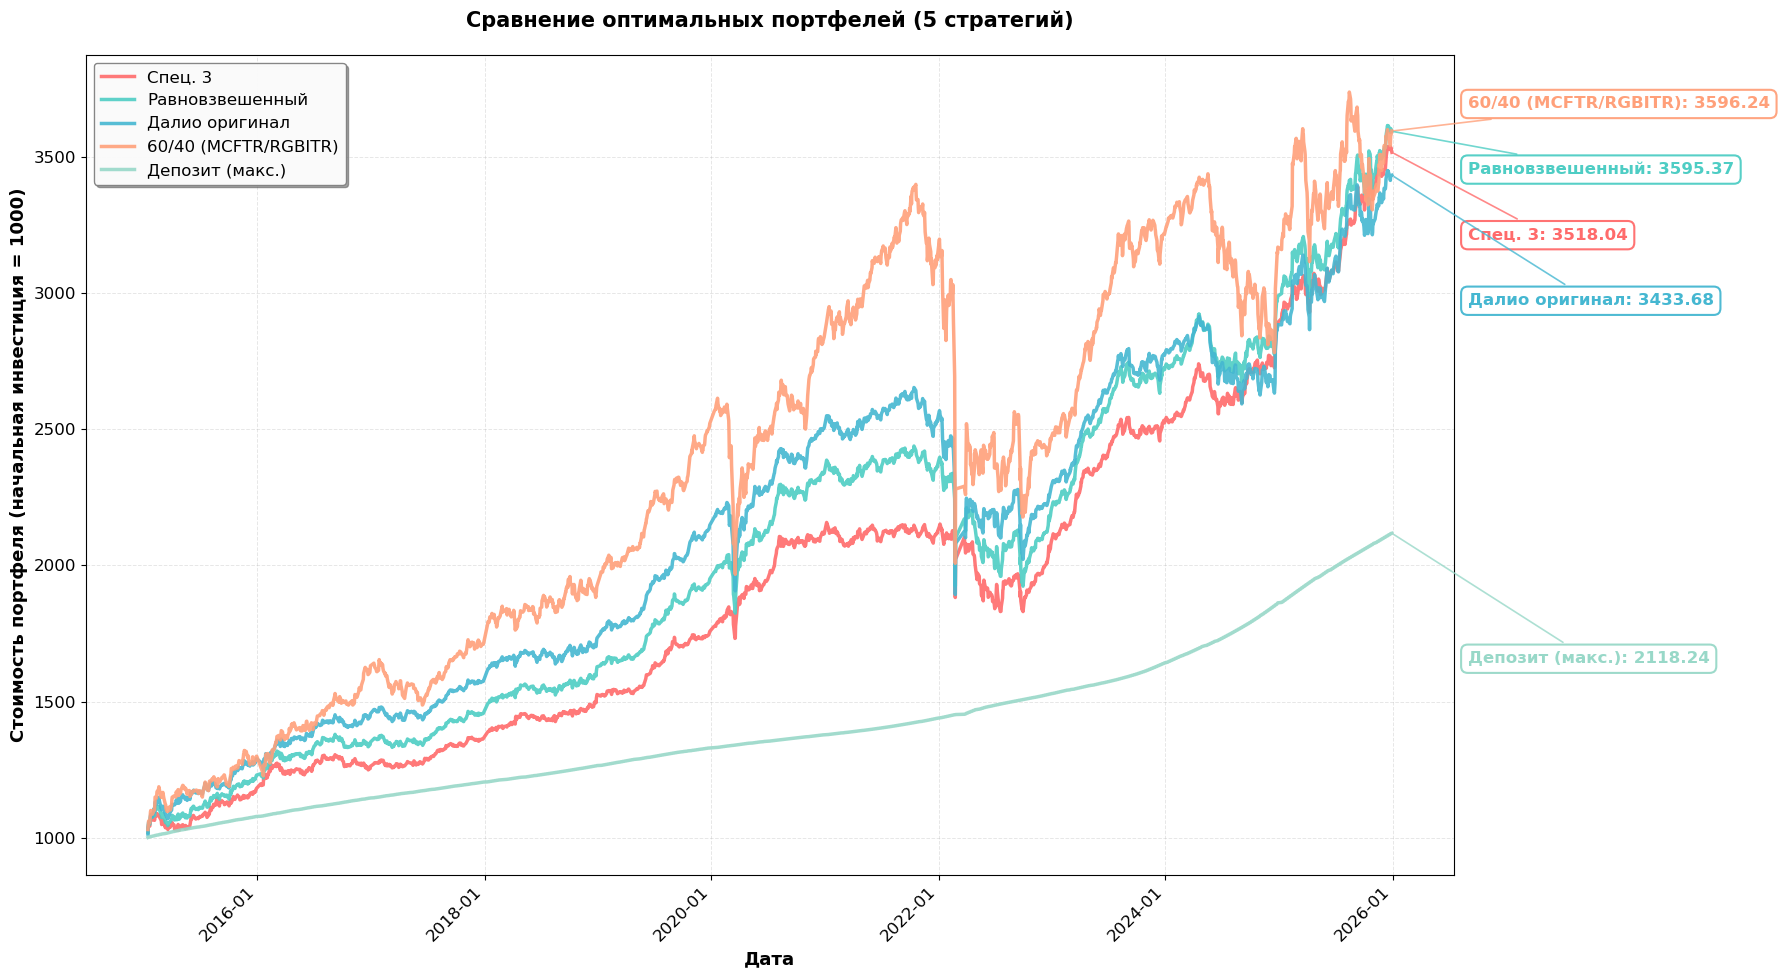


График 2 — Итоговая стоимость стратегий аллокации:
  Спец. 3: 3518.04
  Равновзвешенный: 3595.37
  Далио оригинал: 3433.68
  60/40 (MCFTR/RGBITR): 3596.24
  Депозит (макс.): 2118.24


In [91]:
spec_map = {
    "Спец. 1": (portfolio_1_daily_returns, median_w1),
    "Спец. 2": (portfolio_2_daily_returns, median_w2),
    "Спец. 3": (portfolio_3_daily_returns, median_w3),
    "Спец. 4": (portfolio_4_daily_returns, median_w4),
}
best_ret_df, best_weights = spec_map[best_spec_name]
best_port_ret = best_ret_df @ np.asarray(best_weights, dtype=float)
 
strategy_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
 
strategy_values[best_spec_name] = 1000 * (1 + best_port_ret).cumprod()
for label, w in [
    ("Равновзвешенный", equal_w3),
    ("Далио оригинал", weights_dalio),
]:
    port_ret = portfolio_3_daily_returns @ np.asarray(w, dtype=float)
    strategy_values[label] = 1000 * (1 + port_ret).cumprod()
 
ret_60_40 = portfolio_60_40_returns @ weights_60_40
cum_60_40 = 1000 * (1 + ret_60_40).cumprod()
cum_60_40.index = pd.to_datetime(cum_60_40.index)
strategy_values["60/40 (MCFTR/RGBITR)"] = cum_60_40.reindex(
    strategy_values.index, method="ffill"
)
 
strategy_values["Депозит (макс.)"] = 1000 * (1 + deposit_daily_ret).cumprod()
 
strategy_values = strategy_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=strategy_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_3_strategies",
    fmt="pdf",
)
 
print("\nГрафик 2 — Итоговая стоимость стратегий аллокации:")
for col in strategy_values.columns:
    print(f"  {col}: {strategy_values[col].iloc[-1]:.2f}")

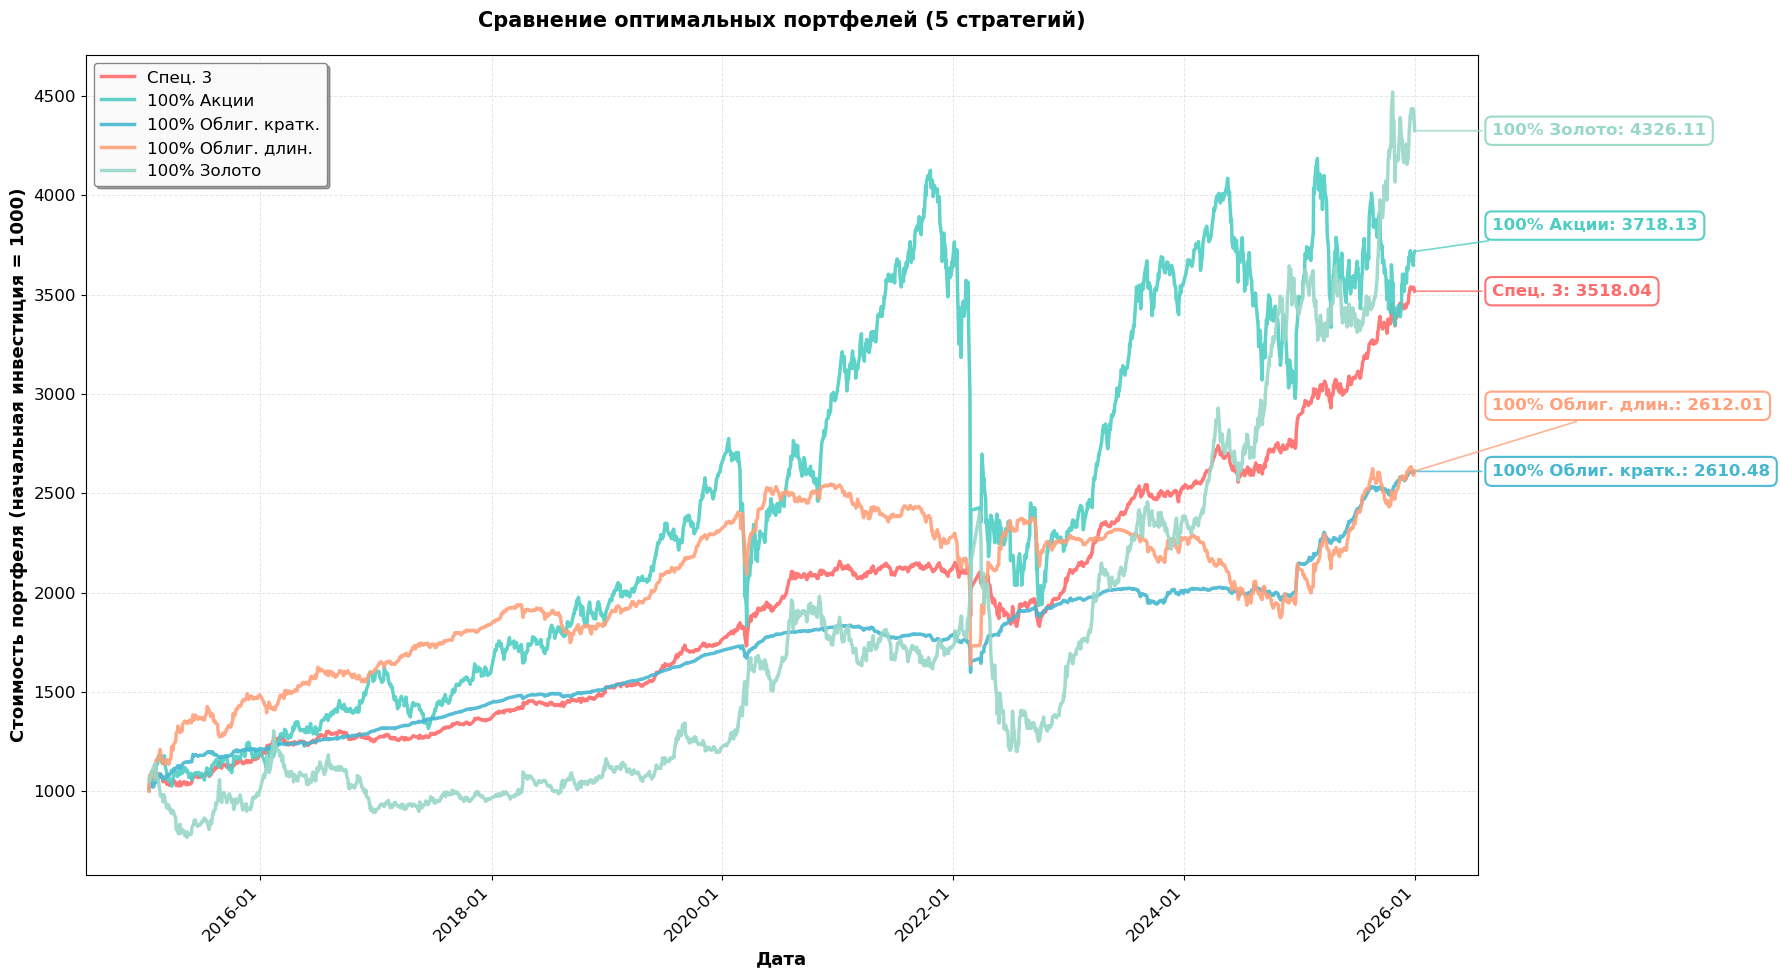


График 3 — Итоговая стоимость одноклассовых вложений:
  Спец. 3: 3518.04
  100% Акции: 3718.13
  100% Облиг. кратк.: 2610.48
  100% Облиг. длин.: 2612.01
  100% Золото: 4326.11


In [92]:
asset_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
asset_values[best_spec_name] = 1000 * (1 + best_port_ret).cumprod()
for label, w in [
    ("100% Акции", only_equity),
    ("100% Облиг. кратк.", only_bond_short),
    ("100% Облиг. длин.", only_bond_long),
    ("100% Золото", only_gold),
]:
    port_ret = portfolio_3_daily_returns @ np.asarray(w, dtype=float)
    asset_values[label] = 1000 * (1 + port_ret).cumprod()
 
asset_values = asset_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=asset_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_4_vs_assets",
    fmt="pdf",
)
 
print("\nГрафик 3 — Итоговая стоимость одноклассовых вложений:")
for col in asset_values.columns:
    print(f"  {col}: {asset_values[col].iloc[-1]:.2f}")

# 4. Построение регрессии

In [93]:
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)
FIGURE_DPI = 600
FIGURE_FMT = "pdf"

def save_figure(fig, filename):
    """Сохраняет фигуру в figures/ с высоким качеством."""
    path = FIGURE_DIR / f"{filename}.{FIGURE_FMT}"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight', format=FIGURE_FMT)
    print(f"Сохранено: {path}")

## 4.1. Подготовка данных

In [94]:
def transform_daily_to_monthly(df, price_col_name):
    """Преобразует дневные данные (столбцы 'Дата', 'Цена') в месячные
    по первому торговому дню месяца."""
    df = df.copy()
    df['Дата'] = pd.to_datetime(df['Дата'], dayfirst=True)
    df = df.sort_values('Дата').set_index('Дата')
    df = df[['Цена']].rename(columns={'Цена': price_col_name})
    return df.resample('MS').first()

In [95]:
portfolio_data = portfolio_3_data.copy()
month_start_prices = portfolio_data.resample('MS').first()

monthly_simple_returns = (
    month_start_prices / month_start_prices.shift(1) - 1
).dropna(how='all')

weights = extract_median_weights(bounds_summary_3)

print("Активы и веса портфеля (нормализованная медиана):")
for i, col in enumerate(month_start_prices.columns):
    print(f"  {col}: {weights[i]:.4f} ({weights[i]*100:.2f}%)")

portfolio_simple_return = (monthly_simple_returns * weights).sum(axis=1)
monthly_log_returns_portfolio = pd.DataFrame({
    'Portfolio': np.log(1 + portfolio_simple_return)
})

print(f"\nY: {monthly_log_returns_portfolio.shape}, "
      f"период {monthly_log_returns_portfolio.index[0]:%Y-%m} - "
      f"{monthly_log_returns_portfolio.index[-1]:%Y-%m}")

Активы и веса портфеля (нормализованная медиана):
  MCFTR: 0.1599 (15.99%)
  RUGBITR3Y: 0.4544 (45.44%)
  RUGBITR10Y: 0.0928 (9.28%)
  GLDRUB_TOM: 0.2929 (29.29%)

Y: (131, 1), период 2015-02 - 2025-12


In [96]:
df_MOEXBMI_m = (
    df_MOEXBMI.copy()
    .assign(TRADEDATE=lambda x: pd.to_datetime(x['TRADEDATE'], format='%d.%m.%Y'))
    .sort_values('TRADEDATE')
    .set_index('TRADEDATE')[['CLOSE']]
    .rename(columns={'CLOSE': 'MOEXBMI'})
    .resample('MS').first()
)

moex_monthly_log_returns = np.log(
    df_MOEXBMI_m / df_MOEXBMI_m.shift(1)
).dropna(how='all')

print(f"MOEXBMI: {moex_monthly_log_returns.shape}, "
      f"период {moex_monthly_log_returns.index[0]:%Y-%m} - "
      f"{moex_monthly_log_returns.index[-1]:%Y-%m}")

MOEXBMI: (131, 1), период 2015-02 - 2025-12


In [97]:
df_CNY_RUB_m = transform_daily_to_monthly(df_CNY_RUB, 'CNY_RUB')
df_EUR_RUB_m = transform_daily_to_monthly(df_EUR_RUB, 'EUR_RUB')
df_USD_RUB_m = transform_daily_to_monthly(df_USD_RUB, 'USD_RUB')
df_USD_CNY_m = transform_daily_to_monthly(df_USD_CNY, 'USD_CNY')
df_BRENT_m   = transform_daily_to_monthly(df_BRENT,   'BRENT')

df_RUONIA_m = (
    df_RUONIA.copy()
    .assign(DT=lambda x: pd.to_datetime(x['DT']))
    .sort_values('DT')
    .set_index('DT')[['ruo']]
    .rename(columns={'ruo': 'RUONIA'})
    .resample('MS').first()
)

In [98]:
df_gcurve = (
    df_ofz[['tradedate', 'period_1.0', 'period_10.0']]
    .copy()
    .set_index('tradedate')
    .sort_index()
    .rename(columns={'period_1.0': 'yield_1Y', 'period_10.0': 'yield_10Y'})
)
df_gcurve_m = df_gcurve.resample('MS').first()
df_gcurve_m['yield_spread'] = df_gcurve_m['yield_10Y'] - df_gcurve_m['yield_1Y']
df_yield_spread_m = df_gcurve_m[['yield_spread']]
print(f"Yield spread (10Y-1Y): {df_yield_spread_m.shape}, "
      f"период {df_yield_spread_m.index[0]:%Y-%m} - "
      f"{df_yield_spread_m.index[-1]:%Y-%m}")

Yield spread (10Y-1Y): (132, 1), период 2015-01 - 2025-12


In [99]:
df_daily_macro = df_CNY_RUB_m.copy()
for df in [df_EUR_RUB_m, df_USD_RUB_m, df_USD_CNY_m, df_BRENT_m, df_RUONIA_m,
           df_yield_spread_m]:
    df_daily_macro = df_daily_macro.join(df, how='outer')
df_daily_macro.index = pd.to_datetime(df_daily_macro.index)

df_monthly_raw = df_monthly_data.copy()
df_monthly_macro = df_monthly_raw.T.iloc[2:].copy()
df_monthly_macro.index = pd.to_datetime(df_monthly_macro.index)
df_monthly_macro = df_monthly_macro.apply(pd.to_numeric, errors='coerce')
df_monthly_macro.columns = [
    'budget_deficit_ratio',   # дефицит/профицит к расходам (кумулятивный)
    'gov_debt_internal',      # объем гос. внутреннего долга, млрд руб.
    'gov_debt_external',      # объем гос. внешнего долга, млн долл.
    'M2',                     # денежный агрегат М2, млрд руб.
    'key_rate',               # ключевая ставка ЦБ, % годовых
    'inflation',              # инфляция, % г/г
    'output_index',           # индекс выпуска товаров и услуг
    'avg_wage',               # среднемесячная зарплата, руб.
    'org_turnover',           # оборот организаций, млрд руб.
    'industry_prod_idx',      # индекс пром. производства
    'export_value',           # экспорт, млрд долл.
    'import_value',           # импорт, млрд долл.
    'moex_volume',            # объем торгов на MOEX, млрд руб.
]

df_macro_all = df_daily_macro.join(df_monthly_macro, how='outer')
df_macro_all.index = pd.to_datetime(df_macro_all.index)

print(f"Макропоказатели (сырые): {df_macro_all.shape}, "
      f"период {df_macro_all.index[0]:%Y-%m} - {df_macro_all.index[-1]:%Y-%m}")

Макропоказатели (сырые): (132, 20), период 2015-01 - 2025-12


In [100]:
LOG_DIFF_1M = [
    'CNY_RUB', 'EUR_RUB', 'USD_RUB', 'USD_CNY', 'BRENT',
    'gov_debt_internal', 'gov_debt_external',
    'industry_prod_idx', 'import_value', 'moex_volume',
    'output_index',
]

LOG_DIFF_12M = [
    'M2', 'avg_wage', 'org_turnover', 'export_value',
]

FIRST_DIFF_1M = [
    'RUONIA', 'key_rate', 'inflation', 'yield_spread',
]

FIRST_DIFF_12M = [
    'budget_deficit_ratio',
]

df_macro_transformed = pd.DataFrame(index=df_macro_all.index)

for col in df_macro_all.columns:
    series = df_macro_all[col]
    if series.isna().all():
        df_macro_transformed[col] = np.nan
        continue

    if col in LOG_DIFF_1M:
        positive = (series.dropna() > 0).all()
        if positive:
            df_macro_transformed[col] = np.log(series).diff(1)
        else:
            print(f"  {col}: log-diff невозможен (значения <= 0), "
                  f"применена first-diff")
            df_macro_transformed[col] = series.diff(1)

    elif col in LOG_DIFF_12M:
        positive = (series.dropna() > 0).all()
        if positive:
            df_macro_transformed[col] = np.log(series).diff(12)
        else:
            print(f"  {col}: 12M log-diff невозможен, применена 12M first-diff")
            df_macro_transformed[col] = series.diff(12)

    elif col in FIRST_DIFF_1M:
        df_macro_transformed[col] = series.diff(1)

    elif col in FIRST_DIFF_12M:
        df_macro_transformed[col] = series.diff(12)

    else:
        positive = (series.dropna() > 0).all()
        if positive:
            df_macro_transformed[col] = np.log(series).diff(1)
        else:
            df_macro_transformed[col] = series.diff(1)
            
df_macro_transformed = df_macro_transformed.dropna(how='any')

print(f"Преобразования:")
print(f"  log-diff 1M:    {len(LOG_DIFF_1M)} переменных")
print(f"  log-diff 12M:   {len(LOG_DIFF_12M)} переменных")
print(f"  first-diff 1M:  {len(FIRST_DIFF_1M)} переменных")
print(f"  first-diff 12M: {len(FIRST_DIFF_12M)} переменных")
print(f"Результат: {df_macro_transformed.shape}, "
      f"период {df_macro_transformed.index[0]:%Y-%m} - "
      f"{df_macro_transformed.index[-1]:%Y-%m}")

Преобразования:
  log-diff 1M:    11 переменных
  log-diff 12M:   4 переменных
  first-diff 1M:  4 переменных
  first-diff 12M: 1 переменных
Результат: (120, 20), период 2016-01 - 2025-12


In [101]:
EXTRA_DIFF_VARS = ['M2', 'avg_wage', 'export_value']

for col in EXTRA_DIFF_VARS:
    df_macro_transformed[col] = df_macro_transformed[col].diff()

df_macro_transformed = df_macro_transformed.dropna(how='any')

print(f"Дополнительная первая разность: {EXTRA_DIFF_VARS}")
print(f"Результат: {df_macro_transformed.shape}, "
      f"период {df_macro_transformed.index[0]:%Y-%m} - "
      f"{df_macro_transformed.index[-1]:%Y-%m}")

Дополнительная первая разность: ['M2', 'avg_wage', 'export_value']
Результат: (119, 20), период 2016-02 - 2025-12


In [102]:
last_complete = df_macro_transformed.dropna().index[-1]
df_macro_transformed = df_macro_transformed.loc[:last_complete]
monthly_log_returns_portfolio = monthly_log_returns_portfolio.loc[:last_complete]
moex_monthly_log_returns = moex_monthly_log_returns.loc[:last_complete]

common_index = (
    df_macro_transformed.index
    .intersection(monthly_log_returns_portfolio.index)
    .intersection(moex_monthly_log_returns.index)
)

if len(common_index) == 0:
    raise ValueError("Нет общих дат между датасетами")

df_macro_transformed = df_macro_transformed.loc[common_index]
monthly_log_returns_portfolio = monthly_log_returns_portfolio.loc[common_index]
moex_monthly_log_returns = moex_monthly_log_returns.loc[common_index]

n_nan = (
    monthly_log_returns_portfolio.isna().sum().sum()
    + moex_monthly_log_returns.isna().sum().sum()
    + df_macro_transformed.isna().sum().sum()
)

print(f"Синхронизированный период: "
      f"{common_index[0]:%Y-%m} - {common_index[-1]:%Y-%m}, "
      f"{len(common_index)} наблюдений")

if n_nan == 0:
    print("Пропущенных значений нет")
else:
    print(f"Обнаружено {n_nan} пропусков:")
    print(df_macro_transformed.isna().sum()[lambda x: x > 0])

Синхронизированный период: 2016-02 - 2025-12, 119 наблюдений
Пропущенных значений нет


## 4.2. Проверка на стационарность

In [103]:
def test_stationarity(series, signif=0.05, kpss_margin=0.01, adf_margin=0.02):
    """
    Комбинированный ADF + KPSS тест.

    Пограничный случай: если один тест чуть не проходит порог
    (в пределах margin), а другой уверенно проходит, ряд
    принимается как стационарный.
    """
    series_clean = series.dropna()
    if len(series_clean) < 10:
        return {
            'adf_p': np.nan, 'kpss_p': np.nan,
            'stationary': False, 'note': 'Недостаточно данных'
        }

    try:
        adf_p = adfuller(series_clean, autolag='AIC')[1]
        kpss_p = kpss(series_clean, regression='c', nlags='auto')[1]

        adf_ok  = adf_p < signif
        kpss_ok = kpss_p > signif

        borderline_kpss = (
            adf_ok and not kpss_ok
            and kpss_p > (signif - kpss_margin)
            and adf_p < 0.01
        )

        borderline_adf = (
            not adf_ok and kpss_ok
            and adf_p < (signif + adf_margin)
            and kpss_p > 0.10
        )

        if adf_ok and kpss_ok:
            note = 'Стационарен (оба теста)'
            stationary = True
        elif borderline_kpss:
            note = f'Пограничный (KPSS p={kpss_p:.3f}, ADF уверенный)'
            stationary = True
        elif borderline_adf:
            note = f'Пограничный (ADF p={adf_p:.3f}, KPSS уверенный)'
            stationary = True
        elif adf_ok and not kpss_ok:
            note = 'ADF: стационарен, KPSS: нестационарен'
            stationary = False
        elif not adf_ok and kpss_ok:
            note = 'ADF: нестационарен, KPSS: стационарен'
            stationary = False
        else:
            note = 'Нестационарен (оба теста)'
            stationary = False

        return {
            'adf_p': adf_p, 'kpss_p': kpss_p,
            'stationary': stationary, 'note': note
        }

    except Exception as e:
        return {
            'adf_p': np.nan, 'kpss_p': np.nan,
            'stationary': False, 'note': f'Ошибка: {e}'
        }


def run_tests(data, name):
    """Запуск тестов стационарности для всех столбцов датасета."""
    results = []
    for col in data.columns:
        test = test_stationarity(data[col])
        results.append({
            'Variable': col,
            'ADF_p':  f"{test['adf_p']:.4f}" if not np.isnan(test['adf_p']) else 'NaN',
            'KPSS_p': f"{test['kpss_p']:.4f}" if not np.isnan(test['kpss_p']) else 'NaN',
            'Status': '+' if test['stationary'] else '-',
            'Note':   test['note'],
        })

    df = pd.DataFrame(results)
    n_stat = (df['Status'] == '+').sum()

    print(f"\n{'='*80}")
    print(f"{name}: {n_stat}/{len(df)} стационарных")
    print(f"{'='*80}")
    print(df.to_string(index=False))

    non_stat = df[df['Status'] == '-']['Variable'].tolist()
    if non_stat:
        print(f"\nНестационарные: {', '.join(non_stat)}")

    return df, non_stat

In [104]:
portfolio_df, portfolio_nonstat = run_tests(
    monthly_log_returns_portfolio, "ПОРТФЕЛЬ (Y)"
)


ПОРТФЕЛЬ (Y): 1/1 стационарных
 Variable  ADF_p KPSS_p Status                    Note
Portfolio 0.0042 0.1000      + Стационарен (оба теста)


In [105]:
moex_df, moex_nonstat = run_tests(
    moex_monthly_log_returns, "MOEXBMI"
)


MOEXBMI: 1/1 стационарных
Variable  ADF_p KPSS_p Status                    Note
 MOEXBMI 0.0000 0.1000      + Стационарен (оба теста)


In [106]:
macro_df, macro_nonstat = run_tests(
    df_macro_transformed, "МАКРОПОКАЗАТЕЛИ (X)"
)


МАКРОПОКАЗАТЕЛИ (X): 20/20 стационарных
            Variable  ADF_p KPSS_p Status                    Note
             CNY_RUB 0.0000 0.1000      + Стационарен (оба теста)
             EUR_RUB 0.0000 0.1000      + Стационарен (оба теста)
             USD_RUB 0.0000 0.1000      + Стационарен (оба теста)
             USD_CNY 0.0000 0.1000      + Стационарен (оба теста)
               BRENT 0.0000 0.1000      + Стационарен (оба теста)
              RUONIA 0.0000 0.1000      + Стационарен (оба теста)
        yield_spread 0.0000 0.1000      + Стационарен (оба теста)
budget_deficit_ratio 0.0335 0.1000      + Стационарен (оба теста)
   gov_debt_internal 0.0000 0.1000      + Стационарен (оба теста)
   gov_debt_external 0.0000 0.1000      + Стационарен (оба теста)
                  M2 0.0001 0.1000      + Стационарен (оба теста)
            key_rate 0.0000 0.1000      + Стационарен (оба теста)
           inflation 0.0037 0.1000      + Стационарен (оба теста)
        output_index 0.0000 0.1000 

In [107]:
if macro_nonstat:
    print(f"Нестационарные переменные: {', '.join(macro_nonstat)}")
    nonstat_details = macro_df[macro_df['Status'] == '-']
    print(nonstat_details.to_string(index=False))
    raise ValueError(
        "Обнаружены нестационарные ряды после преобразований в 5.1. "
        "Необходимо вернуться в 5.1 и скорректировать преобразования."
    )
else:
    macro_final_nonstat = []
    print("Все макропоказатели стационарны после преобразований в 5.1")

Все макропоказатели стационарны после преобразований в 5.1


In [108]:
initial_transformations = {}
for col in df_macro_transformed.columns:
    if col in ['CNY_RUB', 'EUR_RUB', 'USD_RUB', 'USD_CNY', 'BRENT',
               'gov_debt_internal', 'gov_debt_external',
               'industry_prod_idx', 'import_value', 'moex_volume',
               'output_index']:
        initial_transformations[col] = 'log_diff_1M'
    elif col in ['org_turnover']:
        initial_transformations[col] = 'log_diff_12M'
    elif col in ['M2', 'avg_wage', 'export_value']:
        initial_transformations[col] = 'log_diff_12M + diff_1'
    elif col in ['RUONIA', 'key_rate', 'inflation', 'yield_spread']:
        initial_transformations[col] = 'first_diff_1M'
    elif col in ['budget_deficit_ratio']:
        initial_transformations[col] = 'first_diff_12M'
    else:
        initial_transformations[col] = 'unknown'

print(f"\n{'='*80}")
print("СВОДКА ПРЕОБРАЗОВАНИЙ")
print(f"{'='*80}")
print(f"{'Переменная':<25} {'Преобразование':<25}")
print("-" * 50)
for var in df_macro_transformed.columns:
    init = initial_transformations.get(var, '?')
    print(f"{var:<25} {init:<25}")


СВОДКА ПРЕОБРАЗОВАНИЙ
Переменная                Преобразование           
--------------------------------------------------
CNY_RUB                   log_diff_1M              
EUR_RUB                   log_diff_1M              
USD_RUB                   log_diff_1M              
USD_CNY                   log_diff_1M              
BRENT                     log_diff_1M              
RUONIA                    first_diff_1M            
yield_spread              first_diff_1M            
budget_deficit_ratio      first_diff_12M           
gov_debt_internal         log_diff_1M              
gov_debt_external         log_diff_1M              
M2                        log_diff_12M + diff_1    
key_rate                  first_diff_1M            
inflation                 first_diff_1M            
output_index              log_diff_1M              
avg_wage                  log_diff_12M + diff_1    
org_turnover              log_diff_12M             
industry_prod_idx         log_diff_1M     

In [109]:
common_index = (
    df_macro_transformed.index
    .intersection(monthly_log_returns_portfolio.index)
    .intersection(moex_monthly_log_returns.index)
)
if len(common_index) == 0:
    raise ValueError("Нет общих дат между датасетами")

df_macro_transformed = df_macro_transformed.loc[common_index]
monthly_log_returns_portfolio = monthly_log_returns_portfolio.loc[common_index]
moex_monthly_log_returns = moex_monthly_log_returns.loc[common_index]

In [110]:
n_nan = (
    monthly_log_returns_portfolio.isna().sum().sum()
    + moex_monthly_log_returns.isna().sum().sum()
    + df_macro_transformed.isna().sum().sum()
)

all_stationary = (
    len(portfolio_nonstat) == 0
    and len(moex_nonstat) == 0
    and len(macro_final_nonstat) == 0
)

summary = pd.DataFrame({
    'Датасет': ['Портфель (Y)', 'MOEXBMI', 'Макропоказатели (X)'],
    'Переменных': [
        monthly_log_returns_portfolio.shape[1],
        moex_monthly_log_returns.shape[1],
        df_macro_transformed.shape[1],
    ],
    'Наблюдений': [
        len(monthly_log_returns_portfolio),
        len(moex_monthly_log_returns),
        len(df_macro_transformed),
    ],
    'Стационарных': [
        (portfolio_df['Status'] == '+').sum(),
        (moex_df['Status'] == '+').sum(),
        (macro_df['Status'] == '+').sum(),
    ],
})
summary['% стац.'] = (summary['Стационарных'] / summary['Переменных'] * 100).round(1)
print("\n" + summary.to_string(index=False))

print(f"\nОбщий период: {common_index[0]:%Y-%m} - "
      f"{common_index[-1]:%Y-%m} ({len(common_index)} месяцев)")

if all_stationary and n_nan == 0:
    print(f"\nДАННЫЕ ГОТОВЫ К РЕГРЕССИОННОМУ АНАЛИЗУ")
    print(f"  Все ряды стационарны (комбинированный ADF+KPSS тест)")
    print(f"  Пропущенных значений: 0")
else:
    if not all_stationary:
        remaining = portfolio_nonstat + moex_nonstat + macro_final_nonstat
        print(f"\nНестационарные: {', '.join(remaining)}")
    if n_nan > 0:
        print(f"Пропущенные значения: {n_nan}")


            Датасет  Переменных  Наблюдений  Стационарных  % стац.
       Портфель (Y)           1         119             1    100.0
            MOEXBMI           1         119             1    100.0
Макропоказатели (X)          20         119            20    100.0

Общий период: 2016-02 - 2025-12 (119 месяцев)

ДАННЫЕ ГОТОВЫ К РЕГРЕССИОННОМУ АНАЛИЗУ
  Все ряды стационарны (комбинированный ADF+KPSS тест)
  Пропущенных значений: 0


## 4.3. VIF

In [111]:
correlation_matrix = df_macro_transformed.corr()

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'Var1': correlation_matrix.columns[i],
                'Var2': correlation_matrix.columns[j],
                'Correlation': round(corr_val, 3),
            })

if high_corr_pairs:
    high_corr_df = (
        pd.DataFrame(high_corr_pairs)
        .assign(abs_corr=lambda x: x['Correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    print(f"Высокие парные корреляции (|r| > 0.7): {len(high_corr_pairs)} пар(а)")
    print(high_corr_df.to_string(index=False))
else:
    print("Пар с корреляцией |r| > 0.7 не обнаружено")

upper_tri = correlation_matrix.values[
    np.triu_indices_from(correlation_matrix.values, k=1)
]
print(f"\nОбщая статистика корреляций:")
print(f"  Переменных:       {len(correlation_matrix.columns)}")
print(f"  Пар:              {len(upper_tri)}")
print(f"  Средняя |r|:      {np.abs(upper_tri).mean():.3f}")
print(f"  Медианная |r|:    {np.median(np.abs(upper_tri)):.3f}")
print(f"  Максимальная |r|: {np.abs(upper_tri).max():.3f}")

Высокие парные корреляции (|r| > 0.7): 4 пар(а)
        Var1              Var2  Correlation
     CNY_RUB           USD_RUB        0.965
     CNY_RUB           EUR_RUB        0.950
     EUR_RUB           USD_RUB        0.940
output_index industry_prod_idx        0.924

Общая статистика корреляций:
  Переменных:       20
  Пар:              190
  Средняя |r|:      0.170
  Медианная |r|:    0.123
  Максимальная |r|: 0.965


Сохранено: figures\regression_correlation_matrix.pdf


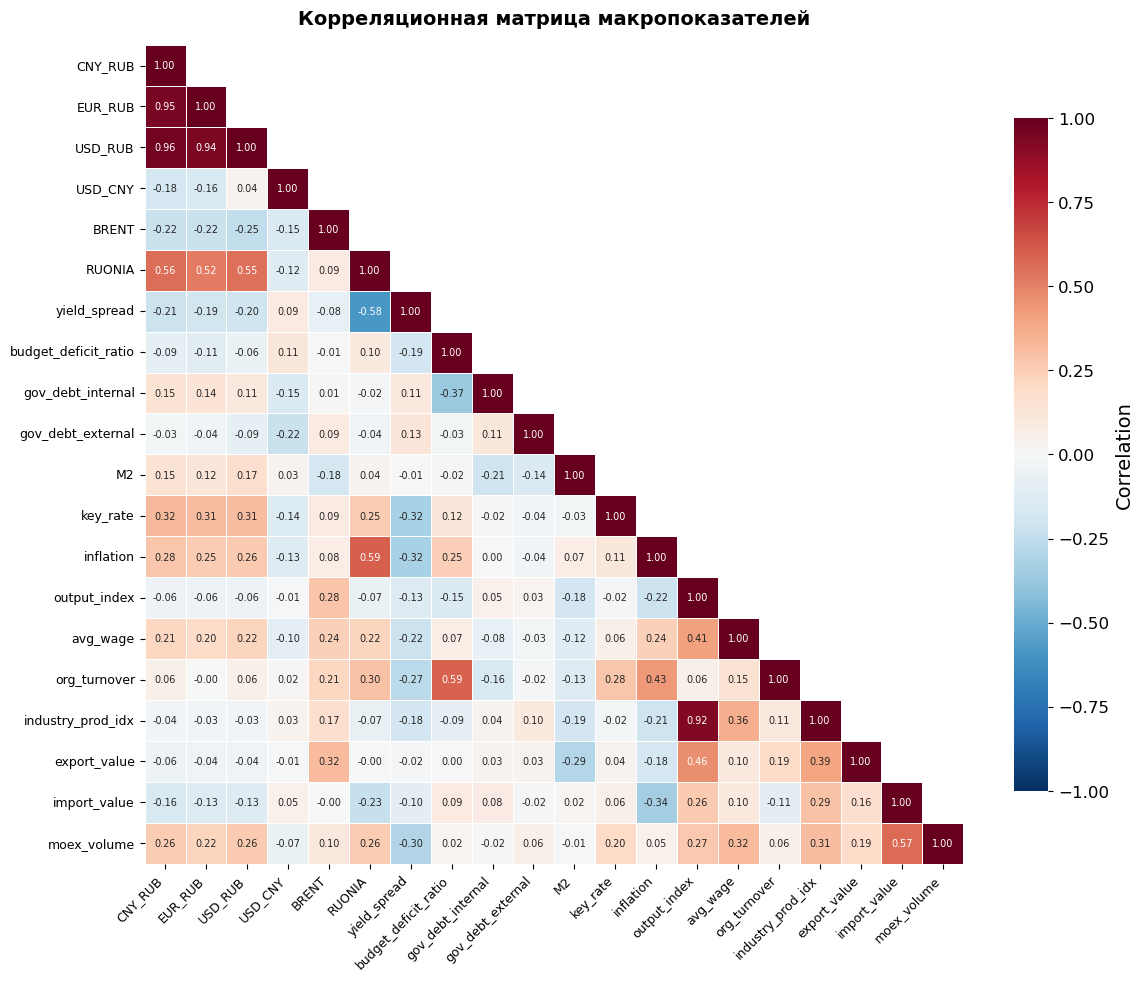

In [112]:
n_vars = len(correlation_matrix.columns)
fig_width = max(12, n_vars * 0.6)
fig_height = max(10, n_vars * 0.5)

fig_corr = plt.figure(figsize=(fig_width, fig_height))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(
    correlation_matrix, mask=mask, annot=True, fmt='.2f',
    annot_kws={'size': 7}, cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    vmin=-1, vmax=1,
)
plt.title('Корреляционная матрица макропоказателей',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
save_figure(fig_corr, "regression_correlation_matrix")
plt.show()

In [113]:
X_macro = df_macro_transformed.copy()

vif_data = pd.DataFrame({
    'Variable': X_macro.columns,
    'VIF': [variance_inflation_factor(X_macro.values, i)
            for i in range(X_macro.shape[1])],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("Начальные VIF:")
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
moderate_vif = vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] <= 10)]
low_vif = vif_data[vif_data['VIF'] < 5]

print(f"\nКатегоризация:")
print(f"  VIF > 10:  {len(high_vif):2d} переменных")
print(f"  VIF 5-10:  {len(moderate_vif):2d} переменных")
print(f"  VIF < 5:   {len(low_vif):2d} переменных")

if len(high_vif) > 0:
    print(f"\nПеременные с VIF > 10:")
    for _, row in high_vif.iterrows():
        print(f"  {row['Variable']:<25} VIF = {row['VIF']:.2f}")

Начальные VIF:
            Variable       VIF
             USD_RUB 59.369681
             CNY_RUB 46.131256
             EUR_RUB 13.865236
        output_index  9.960034
   industry_prod_idx  9.153442
             USD_CNY  3.802094
              RUONIA  3.521062
        import_value  2.776826
         moex_volume  2.489012
           inflation  2.229335
        yield_spread  2.153639
budget_deficit_ratio  1.932724
            avg_wage  1.808478
   gov_debt_internal  1.805579
        org_turnover  1.797984
        export_value  1.646708
               BRENT  1.581295
            key_rate  1.416572
                  M2  1.361684
   gov_debt_external  1.220978

Категоризация:
  VIF > 10:   3 переменных
  VIF 5-10:   2 переменных
  VIF < 5:   15 переменных

Переменные с VIF > 10:
  USD_RUB                   VIF = 59.37
  CNY_RUB                   VIF = 46.13
  EUR_RUB                   VIF = 13.87


In [114]:
#  Порог VIF = 5 (James et al., 2013, ISLR, p. 101)

VIF_THRESHOLD = 5
X_macro_reduced = X_macro.copy()
removed_vars = []

print(f"Порог VIF: {VIF_THRESHOLD}")
print(f"Начальное количество переменных: {len(X_macro_reduced.columns)}\n")

for iteration in range(1, 21):
    if len(X_macro_reduced.columns) == 0:
        print("Все переменные удалены")
        break

    vif_temp = pd.DataFrame({
        'Variable': X_macro_reduced.columns,
        'VIF': [variance_inflation_factor(X_macro_reduced.values, i)
                for i in range(X_macro_reduced.shape[1])],
    })

    max_vif = vif_temp['VIF'].max()

    if max_vif <= VIF_THRESHOLD:
        print(f"Итерация {iteration}: все VIF <= {VIF_THRESHOLD}, завершение")
        break

    idx = vif_temp['VIF'].idxmax()
    var_to_remove = vif_temp.loc[idx, 'Variable']
    removed_vars.append((var_to_remove, max_vif))

    print(f"Итерация {iteration:2d}: удаление {var_to_remove:<25} (VIF = {max_vif:.2f})")
    X_macro_reduced = X_macro_reduced.drop(columns=[var_to_remove])

Порог VIF: 5
Начальное количество переменных: 20

Итерация  1: удаление USD_RUB                   (VIF = 59.37)
Итерация  2: удаление CNY_RUB                   (VIF = 12.76)
Итерация  3: удаление output_index              (VIF = 9.93)
Итерация 4: все VIF <= 5, завершение


In [115]:
if len(X_macro_reduced.columns) > 0:
    vif_final = pd.DataFrame({
        'Variable': X_macro_reduced.columns,
        'VIF': [variance_inflation_factor(X_macro_reduced.values, i)
                for i in range(X_macro_reduced.shape[1])],
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

    print(f"Оставшиеся переменные: {len(X_macro_reduced.columns)}")
    print(vif_final.to_string(index=False))

    if removed_vars:
        print(f"\nУдалено: {len(removed_vars)}")
        for var, vif_val in removed_vars:
            print(f"  {var:<25} (VIF = {vif_val:.2f})")

    print(f"\nФинальная статистика VIF:")
    print(f"  Максимальный: {vif_final['VIF'].max():.2f}")
    print(f"  Средний:      {vif_final['VIF'].mean():.2f}")
    print(f"  Медианный:    {vif_final['VIF'].median():.2f}")
else:
    print("Не осталось переменных после фильтрации")

Оставшиеся переменные: 17
            Variable      VIF
              RUONIA 3.255770
        import_value 2.568755
         moex_volume 2.295180
           inflation 2.163247
             EUR_RUB 2.088413
        yield_spread 2.079743
budget_deficit_ratio 1.898128
        org_turnover 1.774087
   gov_debt_internal 1.756275
   industry_prod_idx 1.738269
            avg_wage 1.542484
        export_value 1.473449
               BRENT 1.464560
            key_rate 1.365230
                  M2 1.264054
             USD_CNY 1.189935
   gov_debt_external 1.159764

Удалено: 3
  USD_RUB                   (VIF = 59.37)
  CNY_RUB                   (VIF = 12.76)
  output_index              (VIF = 9.93)

Финальная статистика VIF:
  Максимальный: 3.26
  Средний:      1.83
  Медианный:    1.76


In [116]:
Y = monthly_log_returns_portfolio.copy()
X_control = moex_monthly_log_returns.copy()
X_macro = X_macro_reduced.copy()

common_idx = Y.index.intersection(X_control.index).intersection(X_macro.index)
Y = Y.loc[common_idx]
X_control = X_control.loc[common_idx]
X_macro = X_macro.loc[common_idx]
X_all = pd.concat([X_control, X_macro], axis=1)

print(f"Размерности массивов:")
print(f"  Y (портфель):                {Y.shape}")
print(f"  X_control (MOEXBMI):         {X_control.shape}")
print(f"  X_macro (после VIF-фильтра): {X_macro.shape}")
print(f"  X_all (контроль + макро):    {X_all.shape}")

print(f"\nПеременные в X_macro ({len(X_macro.columns)}):")
for i, col in enumerate(X_macro.columns, 1):
    print(f"  {i:2d}. {col}")

total_missing = (
    Y.isna().sum().sum()
    + X_control.isna().sum().sum()
    + X_macro.isna().sum().sum()
)

if total_missing == 0:
    print(f"\nПропущенных значений нет")
else:
    print(f"\nОбнаружено {total_missing} пропущенных значений")
    valid_idx = Y.notna().all(axis=1) & X_all.notna().all(axis=1)
    Y = Y[valid_idx]
    X_control = X_control[valid_idx]
    X_macro = X_macro[valid_idx]
    X_all = X_all[valid_idx]
    print(f"После удаления пропусков: {Y.shape[0]} наблюдений")

assert Y.index.equals(X_all.index), "Индексы Y и X не совпадают"

print(f"\nИтого:")
print(f"  Период:     {Y.index[0]:%Y-%m} -- {Y.index[-1]:%Y-%m}")
print(f"  Наблюдений: {len(Y)}")
print(f"  Переменных: Y=1, X_control=1, "
      f"X_macro={len(X_macro.columns)}, X_all={len(X_all.columns)}")

Размерности массивов:
  Y (портфель):                (119, 1)
  X_control (MOEXBMI):         (119, 1)
  X_macro (после VIF-фильтра): (119, 17)
  X_all (контроль + макро):    (119, 18)

Переменные в X_macro (17):
   1. EUR_RUB
   2. USD_CNY
   3. BRENT
   4. RUONIA
   5. yield_spread
   6. budget_deficit_ratio
   7. gov_debt_internal
   8. gov_debt_external
   9. M2
  10. key_rate
  11. inflation
  12. avg_wage
  13. org_turnover
  14. industry_prod_idx
  15. export_value
  16. import_value
  17. moex_volume

Пропущенных значений нет

Итого:
  Период:     2016-02 -- 2025-12
  Наблюдений: 119
  Переменных: Y=1, X_control=1, X_macro=17, X_all=18


## 4.4. Построение регрессии

In [117]:
HAC_PARAMS = {'cov_type': 'HAC', 'cov_kwds': {'maxlags': 4}}


def _fit_ols(y, X, use_hac=True):
    """OLS с HAC стандартными ошибками (Newey-West)."""
    model = sm.OLS(y, sm.add_constant(X))
    return model.fit(**HAC_PARAMS) if use_hac else model.fit()


def backward_elimination(X, y, threshold=0.05, verbose=True):
    """Поэтапное удаление незначимых переменных (p-value > threshold)."""
    variables = list(X.columns)

    while variables:
        model = _fit_ols(y, X[variables])
        pvalues = model.pvalues.drop('const', errors='ignore')

        if pvalues.empty:
            break

        max_pvalue = pvalues.max()
        if max_pvalue > threshold:
            var_to_remove = pvalues.idxmax()
            variables.remove(var_to_remove)
            if verbose:
                print(f"Удаляем {var_to_remove} (p-value={max_pvalue:.4f})")
        else:
            break

    final_model = (
        _fit_ols(y, X[variables]) if variables
        else _fit_ols(y, pd.DataFrame(index=X.index))
    )
    return final_model, variables


def forward_selection(X, y, threshold=0.05, verbose=True):
    """Поэтапное добавление наиболее значимых переменных."""
    selected = []
    remaining = list(X.columns)

    while remaining:
        best_pvalue = 1.0
        best_feature = None

        for feature in remaining:
            test_features = selected + [feature]
            model = _fit_ols(y, X[test_features])
            pval = model.pvalues[feature]
            if pval < best_pvalue:
                best_pvalue = pval
                best_feature = feature

        if best_pvalue < threshold:
            selected.append(best_feature)
            remaining.remove(best_feature)
            if verbose:
                print(f"Добавляем {best_feature} (p-value={best_pvalue:.4f})")
        else:
            break

    final_model = (
        _fit_ols(y, X[selected]) if selected
        else _fit_ols(y, pd.DataFrame(index=X.index))
    )
    return final_model, selected


def lasso_selection(X, y, cv=5, verbose=True):
    """LASSO с кросс-валидацией. Финальная модель — OLS на отобранных."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    y_1d = y.values.ravel() if hasattr(y, 'values') else np.asarray(y).ravel()

    lasso = LassoCV(cv=cv, random_state=42, max_iter=10000)
    lasso.fit(X_scaled, y_1d)

    selected = [col for col, coef in zip(X.columns, lasso.coef_) if coef != 0]

    if verbose:
        print(f"LASSO alpha: {lasso.alpha_:.6f}, "
              f"отобрано {len(selected)} переменных")

    if selected:
        model = _fit_ols(y, X[selected])
    else:
        model = _fit_ols(y, pd.DataFrame(index=X.index))
        if verbose:
            print("LASSO не выбрал ни одной переменной")

    return model, selected


def find_best_subset(X, y, max_features=6, criterion='adj_r2', verbose=True):
    """Полный перебор комбинаций до max_features переменных.

    max_features=6: при ~118 наблюдениях и правиле 10:1
    допустимо до 11 параметров (включая константу).
    """
    variables = X.columns.tolist()
    best_score = -np.inf if criterion == 'adj_r2' else np.inf
    best_combo = None
    best_model = None

    max_k = min(max_features, len(variables))

    for k in range(1, max_k + 1):
        for combo in combinations(variables, k):
            model = sm.OLS(y, sm.add_constant(X[list(combo)])).fit()

            if criterion == 'adj_r2':
                score = model.rsquared_adj
                is_better = score > best_score
            elif criterion == 'aic':
                score = model.aic
                is_better = score < best_score
            elif criterion == 'bic':
                score = model.bic
                is_better = score < best_score
            else:
                raise ValueError(f"Неизвестный критерий: {criterion}")

            if is_better:
                best_score = score
                best_combo = combo
                best_model = model

    selected = list(best_combo) if best_combo else []

    if selected:
        best_model = _fit_ols(y, X[selected])

    if verbose and selected:
        print(f"Лучшая комбинация ({len(selected)} перем.): {selected}")
        print(f"  {criterion}: {best_score:.4f}")

    return best_model, selected


def model_with_lags(X_all, y, n_lags=2, verbose=True):
    """Модель с лагами зависимой переменной."""
    y_1d = y.values.ravel() if hasattr(y, 'values') else np.asarray(y).ravel()
    dates = X_all.index

    Y_series = pd.Series(y_1d, index=dates)
    X_with_lag = X_all.copy()

    for lag in range(1, n_lags + 1):
        X_with_lag[f'portfolio_lag{lag}'] = Y_series.shift(lag)

    X_with_lag = X_with_lag.dropna()
    Y_lag = Y_series.loc[X_with_lag.index]

    model = _fit_ols(Y_lag, X_with_lag)

    if verbose:
        print(f"Модель с {n_lags} лагами: {len(Y_lag)} наблюдений "
              f"(потеряно {n_lags})")
        for lag in range(1, n_lags + 1):
            name = f'portfolio_lag{lag}'
            if name in model.params.index:
                p = model.pvalues[name]
                c = model.params[name]
                sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
                print(f"  Лаг {lag}: coef={c:.6f}, p={p:.4f} {sig}")

    return model, list(X_with_lag.columns)

In [118]:
def compare_models(models_dict):
    """
    Сравнивает несколько моделей регрессии
    
    Parameters:
    -----------
    models_dict : dict
        Словарь с моделями {имя_модели: модель_OLS}
    
    Returns:
    --------
    pd.DataFrame
        Таблица сравнения моделей
    """
    if not models_dict:
        raise ValueError("Словарь models_dict не может быть пустым")
    
    comparison_data = []
    
    for name, model in models_dict.items():
        n_obs = model.nobs
        n_params = len(model.params)
        
        comparison_data.append({
            'Модель': name,
            'Наблюдения': int(n_obs),
            'Параметры': n_params,
            'R²': model.rsquared,
            'Adj R²': model.rsquared_adj,
            'AIC': model.aic,
            'BIC': model.bic,
            'RMSE': np.sqrt(model.mse_resid),
            'Log-Likelihood': model.llf,
            'F-statistic': model.fvalue,
            'F p-value': model.f_pvalue
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('Adj R²', ascending=False).reset_index(drop=True)
    
    return df_comparison

def f_test_nested(model_simple, model_complex, alpha=0.05):
    """
    Wald-тест для сравнения вложенных моделей.
 
    При использовании HAC-ошибок классический SSR-based F-тест
    некорректен, поскольку опирается на предпосылку i.i.d. ошибок.
    Wald-тест использует HAC-ковариационную матрицу и потому
    согласован с оценкой Ньюи-Уэста.
 
    Parameters
    ----------
    model_simple : RegressionResultsWrapper
        Простая (ограниченная) модель.
    model_complex : RegressionResultsWrapper
        Сложная (неограниченная) модель.
    alpha : float
        Уровень значимости.
 
    Returns
    -------
    dict
        Результаты теста.
    """
    k_simple = len(model_simple.params)
    k_complex = len(model_complex.params)
 
    if k_simple >= k_complex:
        raise ValueError(
            "Простая модель должна иметь меньше параметров, чем сложная"
        )
 
    if model_simple.nobs != model_complex.nobs:
        raise ValueError(
            f"Число наблюдений различается: "
            f"{model_simple.nobs} vs {model_complex.nobs}"
        )
 
    simple_vars = set(model_simple.params.index)
    complex_vars = set(model_complex.params.index)
 
    if not simple_vars.issubset(complex_vars):
        missing = simple_vars - complex_vars
        raise ValueError(
            f"Переменные простой модели отсутствуют в сложной: {missing}"
        )

    extra_vars = sorted(complex_vars - simple_vars)

    restriction = ", ".join(f"{var} = 0" for var in extra_vars)
    wald_result = model_complex.wald_test(restriction, use_f=True, scalar=True)
 
    f_stat = wald_result.fvalue
    p_value = wald_result.pvalue
    df_num = int(wald_result.df_num)
    df_denom = int(wald_result.df_denom)
 
    return {
        'F-статистика': f_stat,
        'p-value': p_value,
        'df_числитель': df_num,
        'df_знаменатель': df_denom,
        'Тестируемые переменные': extra_vars,
        'Уровень значимости': alpha,
        'Вывод': (
            'Сложная модель значимо лучше'
            if p_value < alpha
            else 'Модели статистически не различаются'
        ),
        'Reject H0': p_value < alpha,
    }

def get_coefficients_table(model, significance_levels=[0.01, 0.05, 0.1]):
    """
    Создает таблицу коэффициентов с уровнями значимости
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    significance_levels : list
        Уровни значимости для маркировки [0.01, 0.05, 0.1] для ***, **, *
    
    Returns:
    --------
    pd.DataFrame
        Таблица коэффициентов
    """
    coef_df = pd.DataFrame({
        'Переменная': model.params.index,
        'Коэффициент': model.params.values,
        'Std Error': model.bse.values,
        't-stat': model.tvalues.values,
        'p-value': model.pvalues.values
    })

    conf_int = model.conf_int()
    coef_df['CI 95% Lower'] = conf_int[0].values
    coef_df['CI 95% Upper'] = conf_int[1].values

    def add_significance_stars(p_value):
        if p_value < significance_levels[0]:
            return '***'
        elif p_value < significance_levels[1]:
            return '**'
        elif p_value < significance_levels[2]:
            return '*'
        return ''
    
    coef_df['Значимость'] = coef_df['p-value'].apply(add_significance_stars)
    
    const_row = coef_df[coef_df['Переменная'] == 'const']
    coef_df_no_const = coef_df[coef_df['Переменная'] != 'const'].copy()
    
    if not coef_df_no_const.empty:
        coef_df_no_const = coef_df_no_const.reindex(
            coef_df_no_const['Коэффициент'].abs().sort_values(ascending=False).index
        )

    coef_df_sorted = pd.concat([const_row, coef_df_no_const]) if not const_row.empty else coef_df_no_const
    coef_df_sorted = coef_df_sorted.reset_index(drop=True)
    
    return coef_df_sorted

def plot_coefficients(model, exclude_vars=['const'], figsize=(12, 8), show=False):
    """
    Визуализация коэффициентов с доверительными интервалами
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    exclude_vars : list
        Переменные для исключения из графика
    figsize : tuple
        Размер фигуры
    show : bool
        Показать график немедленно
    
    Returns:
    --------
    tuple
        (fig, ax) объекты matplotlib
    """
    coef_df = get_coefficients_table(model)
    
    plot_df = coef_df[~coef_df['Переменная'].isin(exclude_vars)].copy()
    
    if plot_df.empty:
        print("Нет переменных для отображения после исключения")
        return None, None
    
    plot_df = plot_df.sort_values('Коэффициент')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(plot_df))
    colors = ['red' if p < 0.05 else 'steelblue' if p < 0.1 else 'gray' 
              for p in plot_df['p-value']]

    ci_95 = 1.96 * plot_df['Std Error']

    bars = ax.barh(y_pos, plot_df['Коэффициент'], color=colors, alpha=0.6, edgecolor='black')

    ax.errorbar(plot_df['Коэффициент'], y_pos, xerr=ci_95, 
                fmt='none', ecolor='black', capsize=3, linewidth=1.5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['Переменная'])
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Коэффициент', fontsize=12)
    ax.set_title('Коэффициенты регрессии (95% доверительный интервал)\n' + 
                 'Красный: p<0.05 | Синий: p<0.1 | Серый: p≥0.1', 
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    
    if show:
        plt.show()
    
    return fig, ax 

def _interpret_dw(dw_stat):
    """Интерпретация статистики Durbin-Watson"""
    if 1.5 < dw_stat < 2.5:
        return "Нет значимой автокорреляции"
    elif dw_stat <= 1.5:
        return "Возможна положительная автокорреляция"
    else:
        return "Возможна отрицательная автокорреляция"

def residual_diagnostics(model, X=None, alpha=0.05, verbose=True):
    """
    Проверка остатков модели
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    X : array-like, optional
        Матрица независимых переменных (для тестов гетероскедастичности)
    alpha : float
        Уровень значимости
    verbose : bool
        Выводить интерпретацию результатов
    
    Returns:
    --------
    dict
        Словарь с результатами диагностических тестов
    """
    residuals = model.resid
    fitted = model.fittedvalues
    
    results = {}

    jb_stat, jb_pval, skew, kurtosis = jarque_bera(residuals)
    results['normality_jb'] = {
        'test': 'Jarque-Bera',
        'statistic': jb_stat,
        'p_value': jb_pval,
        'skewness': skew,
        'kurtosis': kurtosis,
        'reject_H0': jb_pval < alpha,
        'interpretation': 'Остатки НЕнормальные (H0 отвергнута)' if jb_pval < alpha else 'Остатки нормальные (H0 не отвергнута)'
    }

    if len(residuals) < 5000:
        sw_stat, sw_pval = stats.shapiro(residuals)
        results['normality_sw'] = {
            'test': 'Shapiro-Wilk',
            'statistic': sw_stat,
            'p_value': sw_pval,
            'reject_H0': sw_pval < alpha,
            'interpretation': 'Остатки НЕнормальные (H0 отвергнута)' if sw_pval < alpha else 'Остатки нормальные (H0 не отвергнута)'
        }
 
    if X is not None:
        bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X)
        results['heteroskedasticity_bp'] = {
            'test': 'Breusch-Pagan',
            'statistic': bp_stat,
            'p_value': bp_pval,
            'reject_H0': bp_pval < alpha,
            'interpretation': 'Гетероскедастичность (H0 отвергнута)' if bp_pval < alpha else 'Гомоскедастичность (H0 не отвергнута)'
        }
        
        white_stat, white_pval, _, _ = het_white(residuals, X)
        results['heteroskedasticity_white'] = {
            'test': 'White',
            'statistic': white_stat,
            'p_value': white_pval,
            'reject_H0': white_pval < alpha,
            'interpretation': 'Гетероскедастичность (H0 отвергнута)' if white_pval < alpha else 'Гомоскедастичность (H0 не отвергнута)'
        }
    
    dw_stat = durbin_watson(residuals)
    results['autocorrelation_dw'] = {
        'test': 'Durbin-Watson',
        'statistic': dw_stat,
        'interpretation': _interpret_dw(dw_stat)
    }
    
    n_lags = min(10, len(residuals) // 5)
    if n_lags > 0:
        try:
            lb_result = acorr_ljungbox(residuals, lags=n_lags, return_df=True)
            lb_pval_min = lb_result['lb_pvalue'].min()
            lb_stat_last = lb_result['lb_stat'].iloc[-1]
                
            results['autocorrelation_lb'] = {
                'test': 'Ljung-Box',
                'statistic': float(lb_stat_last),
                'p_value': float(lb_pval_min),
                'lags_tested': n_lags,
                'reject_H0': lb_pval_min < alpha,
                'interpretation': 'Автокорреляция присутствует (H0 отвергнута)' if lb_pval_min < alpha else 'Автокорреляция отсутствует (H0 не отвергнута)'
            }
            
        except Exception as e:
            print(f"Ошибка при выполнении теста Ljung-Box: {e}")
            results['autocorrelation_lb'] = {
                'test': 'Ljung-Box',
                'statistic': None,
                'p_value': None,
                'lags_tested': n_lags,
                'reject_H0': None,
                'interpretation': f'Ошибка выполнения: {e}'
            }

    if verbose:
        print("\n" + "="*60)
        print("ДИАГНОСТИКА ОСТАТКОВ МОДЕЛИ")
        print("="*60)
        
        for key, result in results.items():
            print(f"\n{result['test']}:")
            if 'statistic' in result and result['statistic'] is not None:
                print(f"   Статистика: {result['statistic']:.4f}")
            if 'p_value' in result and result['p_value'] is not None:
                print(f"   p-value: {result['p_value']:.4f}")
            if 'interpretation' in result:
                print(f"   ➜ {result['interpretation']}")
    
    return results

def plot_residual_diagnostics(model, figsize=(14, 10), show=False):
    """
    Визуализация диагностики остатков
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    figsize : tuple
        Размер фигуры
    show : bool
        Показать график немедленно
    
    Returns:
    --------
    tuple
        (fig, axes) объекты matplotlib
    """
    residuals = model.resid
    fitted = model.fittedvalues
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    axes[0, 0].scatter(fitted, residuals, alpha=0.6, edgecolors='k', s=30)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    
    lowess_result = lowess(residuals, fitted, frac=0.3)
    axes[0, 0].plot(lowess_result[:, 0], lowess_result[:, 1], 'b-', linewidth=2, label='LOWESS')
    
    axes[0, 0].set_xlabel('Прогнозные значения', fontsize=11)
    axes[0, 0].set_ylabel('Остатки', fontsize=11)
    axes[0, 0].set_title('Остатки vs Прогноз\n(Проверка гомоскедастичности)', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot\n(Проверка нормальности)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True, label='Остатки')

    mu, std = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    axes[1, 0].plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Нормальное')
    
    kde = gaussian_kde(residuals)
    axes[1, 0].plot(x, kde(x), 'g--', lw=2, label='KDE')
    
    axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
    axes[1, 0].set_xlabel('Остатки', fontsize=11)
    axes[1, 0].set_ylabel('Плотность', fontsize=11)
    axes[1, 0].set_title('Распределение остатков', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    plot_acf(residuals, lags=min(20, len(residuals)//4), ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title('Автокорреляция остатков (ACF)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    
    if show:
        plt.show()
    
    return fig, axes

def diagnostic_summary(model, X=None, alpha=0.05):
    """
    Сводная таблица всех диагностических тестов
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    X : array-like, optional
        Матрица независимых переменных
    alpha : float
        Уровень значимости
    
    Returns:
    --------
    pd.DataFrame
        Сводная таблица результатов
    """
    diag = residual_diagnostics(model, X=X, alpha=alpha, verbose=False)
    
    summary_data = []
    
    for category, result in diag.items():
        if category != 'multicollinearity_vif':
            row = {
                'Тест': result['test'],
                'Статистика': result.get('statistic', '-'),
                'p-value': result.get('p_value', '-'),
                'Вывод': result['interpretation']
            }
            summary_data.append(row)
    
    # Добавляем VIF отдельно
    if 'multicollinearity_vif' in diag:
        vif_result = diag['multicollinearity_vif']
        row = {
            'Тест': vif_result['test'],
            'Статистика': f"Max VIF = {vif_result['max_vif']:.2f}",
            'p-value': '-',
            'Вывод': vif_result['interpretation']
        }
        summary_data.append(row)
    
    return pd.DataFrame(summary_data)

In [119]:
model_1 = _fit_ols(Y, X_control)
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     10.34
Date:                Mon, 08 Jun 2026   Prob (F-statistic):            0.00168
Time:                        22:25:47   Log-Likelihood:                 306.35
No. Observations:                 119   AIC:                            -608.7
Df Residuals:                     117   BIC:                            -603.1
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.002      4.750      0.0

In [120]:
model_2 = _fit_ols(Y, X_all)
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     38.58
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           6.65e-37
Time:                        22:25:47   Log-Likelihood:                 353.55
No. Observations:                 119   AIC:                            -669.1
Df Residuals:                     100   BIC:                            -616.3
Df Model:                          18                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0123 

In [121]:
model_3 = _fit_ols(Y, X_macro)
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     9.924
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           7.20e-15
Time:                        22:25:47   Log-Likelihood:                 330.66
No. Observations:                 119   AIC:                            -625.3
Df Residuals:                     101   BIC:                            -575.3
Df Model:                          17                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0112 

In [122]:
models_base = {
    'Модель 1 (только MOEXBMI)': model_1,
    'Модель 2 (MOEXBMI + макро)': model_2,
    'Модель 3 (только макро)': model_3,
}

print(compare_models(models_base).to_string(index=False))

                    Модель  Наблюдения  Параметры       R²   Adj R²         AIC         BIC     RMSE  Log-Likelihood  F-statistic    F p-value
Модель 2 (MOEXBMI + макро)         119         19 0.611299 0.541333 -669.097519 -616.294173 0.013528      353.548760    38.577650 6.654728e-37
   Модель 3 (только макро)         119         18 0.428964 0.332849 -625.325038 -575.300815 0.016316      330.662519     9.923896 7.198815e-15
 Модель 1 (только MOEXBMI)         119          2 0.140771 0.133427 -608.703656 -603.145409 0.018595      306.351828    10.342090 1.681502e-03


In [123]:
all_models = {'Базовая (MOEXBMI + макро)': model_2}

model_backward, vars_backward = backward_elimination(X_all, Y)
all_models['Backward Elimination'] = model_backward
print(f"Отобраны: {vars_backward}")

Удаляем RUONIA (p-value=0.9737)
Удаляем gov_debt_internal (p-value=0.9481)
Удаляем M2 (p-value=0.9124)
Удаляем inflation (p-value=0.8491)
Удаляем moex_volume (p-value=0.8214)
Удаляем budget_deficit_ratio (p-value=0.8288)
Удаляем avg_wage (p-value=0.8242)
Удаляем gov_debt_external (p-value=0.7648)
Удаляем BRENT (p-value=0.4922)
Удаляем industry_prod_idx (p-value=0.4209)
Удаляем yield_spread (p-value=0.5090)
Удаляем USD_CNY (p-value=0.1761)
Удаляем key_rate (p-value=0.2073)
Удаляем export_value (p-value=0.2126)
Отобраны: ['MOEXBMI', 'EUR_RUB', 'org_turnover', 'import_value']


In [124]:
model_forward, vars_forward = forward_selection(X_all, Y)
all_models['Forward Selection'] = model_forward
print(f"Отобраны: {vars_forward}")

Добавляем EUR_RUB (p-value=0.0000)
Добавляем MOEXBMI (p-value=0.0000)
Добавляем org_turnover (p-value=0.0000)
Добавляем import_value (p-value=0.0001)
Отобраны: ['EUR_RUB', 'MOEXBMI', 'org_turnover', 'import_value']


In [125]:
model_lasso, vars_lasso = lasso_selection(X_all, Y, cv=5)
all_models['LASSO Selection'] = model_lasso
print(f"Отобраны: {vars_lasso}")

LASSO alpha: 0.000712, отобрано 8 переменных
Отобраны: ['MOEXBMI', 'EUR_RUB', 'USD_CNY', 'BRENT', 'yield_spread', 'org_turnover', 'export_value', 'import_value']


In [126]:
max_features = 5

In [127]:
model_brute_r2, vars_brute_r2 = find_best_subset(
    X_all, Y, max_features=max_features, criterion='adj_r2'
)
all_models['Brute Force (max Adj R2)'] = model_brute_r2

Лучшая комбинация (5 перем.): ['MOEXBMI', 'EUR_RUB', 'USD_CNY', 'org_turnover', 'import_value']
  adj_r2: 0.5839


In [128]:
model_brute_aic, vars_brute_aic = find_best_subset(
    X_all, Y, max_features=max_features, criterion='aic'
)
all_models['Brute Force (min AIC)'] = model_brute_aic

Лучшая комбинация (4 перем.): ['MOEXBMI', 'EUR_RUB', 'org_turnover', 'import_value']
  aic: -692.6119


In [129]:
model_brute_bic, vars_brute_bic = find_best_subset(
    X_all, Y, max_features=max_features, criterion='bic'
)
all_models['Brute Force (min BIC)'] = model_brute_bic

Лучшая комбинация (4 перем.): ['MOEXBMI', 'EUR_RUB', 'org_turnover', 'import_value']
  bic: -678.7162


In [130]:
base_for_poly = vars_backward

coef_table = pd.DataFrame({
    'Variable': model_backward.params.index,
    't_abs': model_backward.tvalues.abs(),
    'p_value': model_backward.pvalues,
})
top_vars = (
    coef_table[
        (~coef_table['Variable'].isin(['const']))
        & (coef_table['p_value'] < 0.05)
    ]
    .nlargest(5, 't_abs')['Variable']
    .tolist()
)

print(f"Тестирование квадратов для {len(top_vars)} значимых переменных:")

significant_squares = []
for var in top_vars:
    sq_name = f'{var}_sq'
    X_test = X_all[base_for_poly].copy()
    X_test[sq_name] = X_all[var] ** 2
    m = _fit_ols(Y, X_test)
    pval = m.pvalues[sq_name]
    coef = m.params[sq_name]
    adj_r2 = m.rsquared_adj
    delta = adj_r2 - model_backward.rsquared_adj
    status = f"p={pval:.4f}, ΔAdj R²={delta:+.4f}" + (" (значим)" if pval < 0.1 else "")
    print(f"  {sq_name:<30} coef={coef:.6f}, {status}")
    if pval < 0.1:
        significant_squares.append(sq_name)

if significant_squares:
    X_poly_final = X_all[base_for_poly].copy()
    for sq_name in significant_squares:
        original = sq_name.replace('_sq', '')
        X_poly_final[sq_name] = X_all[original] ** 2
    model_poly = _fit_ols(Y, X_poly_final)
    if model_poly.rsquared_adj > model_backward.rsquared_adj:
        all_models['Polynomial Features'] = model_poly
        print(f"\nПолиномиальная модель улучшает Adj R2: "
              f"{model_backward.rsquared_adj:.4f} -> "
              f"{model_poly.rsquared_adj:.4f}")
    else:
        all_models['Polynomial Features'] = model_backward
        model_poly = model_backward
        print("Полиномиальная модель не улучшает Adj R2")
else:
    model_poly = model_backward
    all_models['Polynomial Features'] = model_backward
    print("\nНет значимых квадратичных признаков")

Тестирование квадратов для 4 значимых переменных:
  EUR_RUB_sq                     coef=0.155325, p=0.2182, ΔAdj R²=+0.0006
  MOEXBMI_sq                     coef=-0.046242, p=0.6784, ΔAdj R²=-0.0031
  org_turnover_sq                coef=0.023227, p=0.6908, ΔAdj R²=-0.0034
  import_value_sq                coef=0.002081, p=0.9648, ΔAdj R²=-0.0037

Нет значимых квадратичных признаков


In [131]:
model_lags_2, _ = model_with_lags(X_all[vars_backward], Y, n_lags=2)
model_lags_1, _ = model_with_lags(X_all[vars_backward], Y, n_lags=1)
print("Про лаги стоит упомянуть в тексте, но результаты не надо приводить")

Модель с 2 лагами: 117 наблюдений (потеряно 2)
  Лаг 1: coef=-0.028763, p=0.6331 
  Лаг 2: coef=-0.013178, p=0.7980 
Модель с 1 лагами: 118 наблюдений (потеряно 1)
  Лаг 1: coef=-0.026662, p=0.6537 
Про лаги стоит упомянуть в тексте, но результаты не надо приводить


In [132]:
comparison_df = compare_models(all_models)

print("\n" + "=" * 80)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 80)
print(comparison_df.to_string(index=False))

best_r2  = comparison_df.iloc[0]
best_aic = comparison_df.loc[comparison_df['AIC'].idxmin()]
best_bic = comparison_df.loc[comparison_df['BIC'].idxmin()]

print(f"\nЛучшая по Adj R2: {best_r2['Модель']} "
      f"(Adj R2={best_r2['Adj R²']:.4f}, params={best_r2['Параметры']})")
print(f"Лучшая по AIC:    {best_aic['Модель']} "
      f"(AIC={best_aic['AIC']:.2f}, params={best_aic['Параметры']})")
print(f"Лучшая по BIC:    {best_bic['Модель']} "
      f"(BIC={best_bic['BIC']:.2f}, params={best_bic['Параметры']})")


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
                   Модель  Наблюдения  Параметры       R²   Adj R²         AIC         BIC     RMSE  Log-Likelihood  F-statistic    F p-value
 Brute Force (max Adj R2)         119          6 0.601534 0.583903 -692.144911 -675.470170 0.012885      352.072456    79.254506 2.598463e-35
     Backward Elimination         119          5 0.596368 0.582205 -692.611864 -678.716247 0.012912      351.305932    91.461402 1.171497e-34
    Brute Force (min AIC)         119          5 0.596368 0.582205 -692.611864 -678.716247 0.012912      351.305932    91.461402 1.171497e-34
        Forward Selection         119          5 0.596368 0.582205 -692.611864 -678.716247 0.012912      351.305932    91.461402 1.171497e-34
    Brute Force (min BIC)         119          5 0.596368 0.582205 -692.611864 -678.716247 0.012912      351.305932    91.461402 1.171497e-34
      Polynomial Features         119          5 0.596368 0.582205 -692.611864 -678.716247 0.012912      351.305932    91.46

In [133]:
final_models = {
    'Парсимоничная (BIC)': all_models['Brute Force (min BIC)'],
}

In [134]:
def analyze_model(model, name, X_for_diag=None, fig_prefix="model"):
    """Полный анализ модели: коэффициенты, диагностика, графики с сохранением."""

    print(f"\n{'=' * 80}")
    print(f"  {name}")
    print(f"{'=' * 80}")

    print("\nКОЭФФИЦИЕНТЫ")
    print("-" * 80)
    coef_table = get_coefficients_table(model)
    print(coef_table.to_string(index=False))

    # Метрики
    print(f"\nR2 = {model.rsquared:.4f}, "
          f"Adj R2 = {model.rsquared_adj:.4f}, "
          f"AIC = {model.aic:.2f}, "
          f"BIC = {model.bic:.2f}")
    print(f"F-stat = {model.fvalue:.2f}, "
          f"F p-value = {model.f_pvalue:.2e}, "
          f"N = {int(model.nobs)}, "
          f"params = {len(model.params)}")

    # График коэффициентов
    fig_coef, ax_coef = plot_coefficients(
        model, exclude_vars=['const'], figsize=(12, 6)
    )
    if fig_coef is not None:
        save_figure(fig_coef, f"regression_{fig_prefix}_coefficients")
    plt.show()

    # Диагностика остатков
    print("\nДИАГНОСТИКА ОСТАТКОВ")
    print("-" * 80)

    if X_for_diag is not None:
        X_diag = sm.add_constant(X_for_diag)
    else:
        model_vars = [v for v in model.params.index if v != 'const']
        try:
            X_diag = sm.add_constant(
                pd.DataFrame(
                    model.model.exog[:, 1:],
                    columns=model_vars,
                    index=model.model.data.row_labels,
                )
            )
        except Exception:
            X_diag = None

    diag = residual_diagnostics(model, X=X_diag, alpha=0.05, verbose=True)

    # Сводная таблица
    print("\nСВОДКА ДИАГНОСТИЧЕСКИХ ТЕСТОВ")
    print("-" * 80)
    diag_summary = diagnostic_summary(model, X=X_diag, alpha=0.05)
    print(diag_summary.to_string(index=False))

    # Графики остатков
    fig_resid, axes_resid = plot_residual_diagnostics(model, figsize=(14, 10))
    if fig_resid is not None:
        save_figure(fig_resid, f"regression_{fig_prefix}_residuals")
    plt.show()

    return coef_table, diag


  Парсимоничная (BIC): MOEXBMI, EUR_RUB, org_turnover, import_value

КОЭФФИЦИЕНТЫ
--------------------------------------------------------------------------------
  Переменная  Коэффициент  Std Error    t-stat      p-value  CI 95% Lower  CI 95% Upper Значимость
       const     0.012756   0.001548  8.241295 1.703573e-16      0.009722      0.015790        ***
     EUR_RUB     0.194946   0.018135 10.749456 5.961239e-27      0.159401      0.230491        ***
     MOEXBMI     0.161227   0.015313 10.528794 6.364437e-26      0.131215      0.191240        ***
org_turnover    -0.040240   0.007174 -5.608959 2.035475e-08     -0.054302     -0.026179        ***
import_value    -0.036057   0.008923 -4.041074 5.320691e-05     -0.053545     -0.018569        ***

R2 = 0.5964, Adj R2 = 0.5822, AIC = -692.61, BIC = -678.72
F-stat = 91.46, F p-value = 1.17e-34, N = 119, params = 5
Сохранено: figures\regression_bic_coefficients.pdf


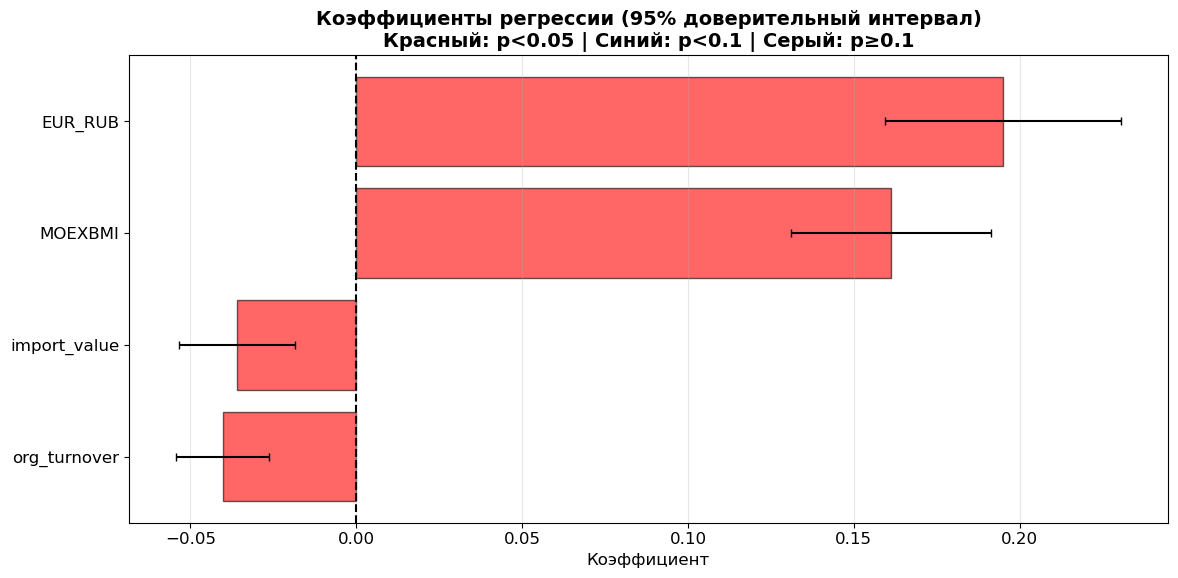


ДИАГНОСТИКА ОСТАТКОВ
--------------------------------------------------------------------------------

ДИАГНОСТИКА ОСТАТКОВ МОДЕЛИ

Jarque-Bera:
   Статистика: 1.8457
   p-value: 0.3974
   ➜ Остатки нормальные (H0 не отвергнута)

Shapiro-Wilk:
   Статистика: 0.9903
   p-value: 0.5694
   ➜ Остатки нормальные (H0 не отвергнута)

Breusch-Pagan:
   Статистика: 4.8575
   p-value: 0.3022
   ➜ Гомоскедастичность (H0 не отвергнута)

White:
   Статистика: 9.1733
   p-value: 0.8198
   ➜ Гомоскедастичность (H0 не отвергнута)

Durbin-Watson:
   Статистика: 2.1080
   ➜ Нет значимой автокорреляции

Ljung-Box:
   Статистика: 9.4002
   p-value: 0.3216
   ➜ Автокорреляция отсутствует (H0 не отвергнута)

СВОДКА ДИАГНОСТИЧЕСКИХ ТЕСТОВ
--------------------------------------------------------------------------------
         Тест  Статистика   p-value                                         Вывод
  Jarque-Bera    1.845682  0.397389         Остатки нормальные (H0 не отвергнута)
 Shapiro-Wilk    0.990320   

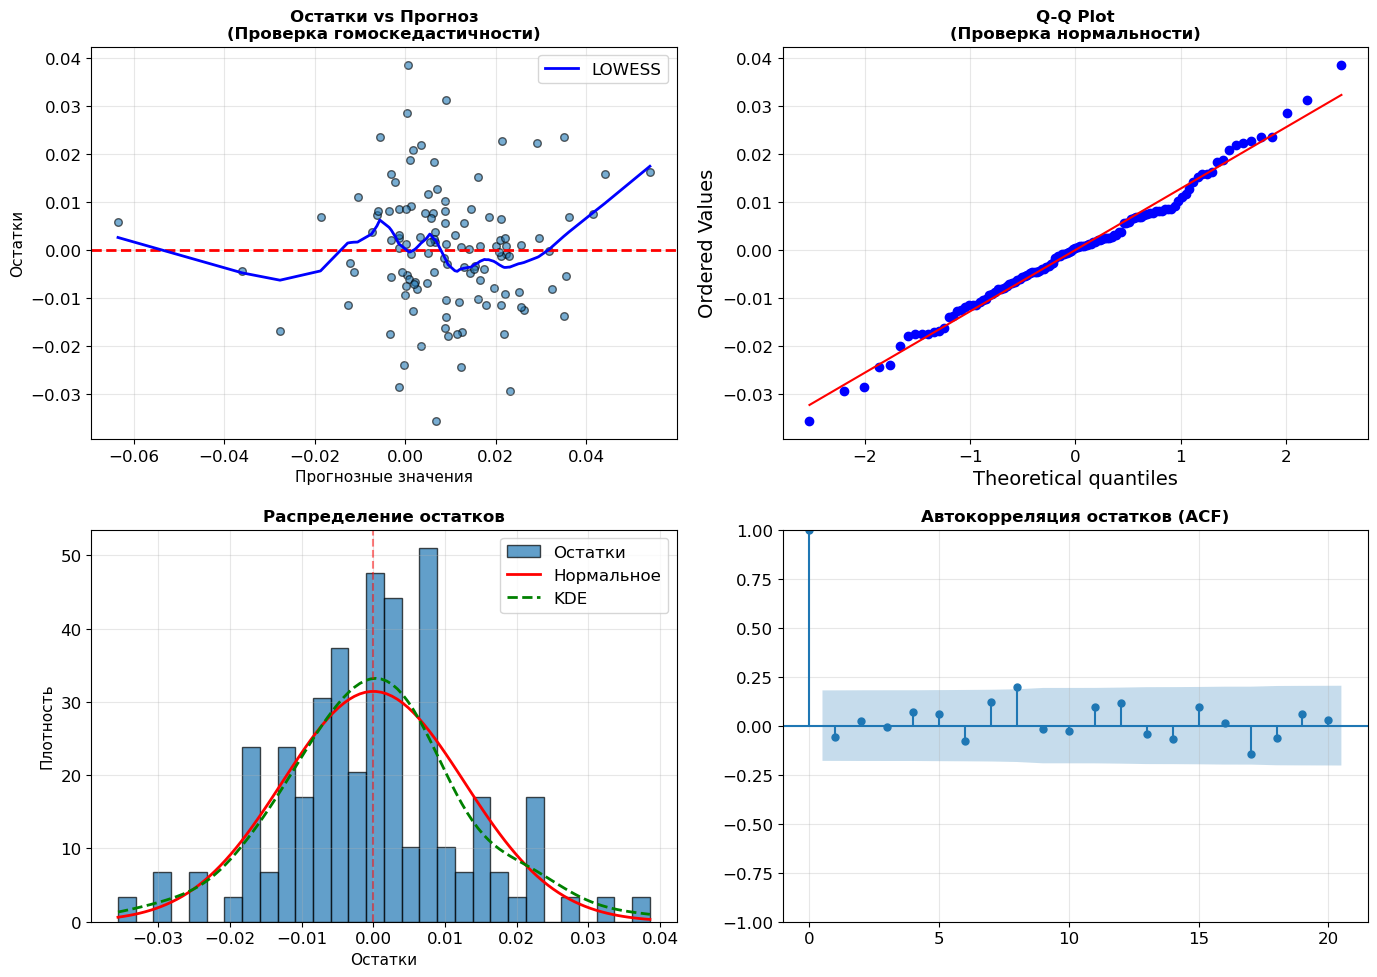

In [135]:
results = {}

for model_key, model_obj in final_models.items():
    model_vars = [v for v in model_obj.params.index if v != 'const']
    label = f"{model_key}: {', '.join(model_vars)}"

    # Префикс для имён файлов
    prefix_map = {
        'Парсимоничная (BIC)':  'bic',
        'Backward / AIC':       'aic',
        'Парсимоничная + Lag1': 'lag1',
    }
    prefix = prefix_map.get(model_key, model_key.lower().replace(' ', '_'))

    if all(v in X_all.columns for v in model_vars):
        X_diag = X_all[model_vars]
    else:
        X_diag = pd.DataFrame(
            model_obj.model.exog[:, 1:],
            columns=model_vars,
            index=model_obj.model.data.row_labels,
        )

    coef, diag = analyze_model(
        model_obj, label, X_for_diag=X_diag, fig_prefix=prefix
    )
    results[model_key] = {'model': model_obj, 'coef': coef, 'diag': diag}

In [136]:
if len(final_models) >= 2:
    models_list = list(final_models.values())
    names_list = list(final_models.keys())

    # Сравниваем только модели с одинаковым числом наблюдений
    for i in range(len(models_list)):
        for j in range(i + 1, len(models_list)):
            m_simple = models_list[i]
            m_complex = models_list[j]

            # Определяем, какая проще
            if len(m_simple.params) > len(m_complex.params):
                m_simple, m_complex = m_complex, m_simple
                n_simple, n_complex = names_list[j], names_list[i]
            else:
                n_simple, n_complex = names_list[i], names_list[j]

            if (m_simple.nobs == m_complex.nobs
                    and len(m_simple.params) < len(m_complex.params)):
                # Проверяем вложенность
                simple_vars = set(m_simple.params.index)
                complex_vars = set(m_complex.params.index)
                if simple_vars.issubset(complex_vars):
                    try:
                        f_result = f_test_nested(m_simple, m_complex)
                        print(f"\nF-тест: {n_simple} vs {n_complex}")
                        print(f"  F = {f_result['F-статистика']:.4f}, "
                              f"p = {f_result['p-value']:.4f}")
                        print(f"  {f_result['Вывод']}")
                    except ValueError as e:
                        print(f"\nF-тест невозможен ({n_simple} vs {n_complex}): {e}")

In [137]:
print(f"\n{'=' * 80}")
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА ФИНАЛЬНЫХ МОДЕЛЕЙ")
print(f"{'=' * 80}")

comparison_final = compare_models(final_models)
print(comparison_final.to_string(index=False))


СРАВНИТЕЛЬНАЯ ТАБЛИЦА ФИНАЛЬНЫХ МОДЕЛЕЙ
             Модель  Наблюдения  Параметры       R²   Adj R²         AIC         BIC     RMSE  Log-Likelihood  F-statistic    F p-value
Парсимоничная (BIC)         119          5 0.596368 0.582205 -692.611864 -678.716247 0.012912      351.305932    91.461402 1.171497e-34


In [138]:
print(f"\n{'=' * 80}")
print("ИТОГОВЫЙ ВЫБОР МОДЕЛИ")
print(f"{'=' * 80}")

# Выбираем BIC-модель как основную (принцип парсимонии)
# Если backward значимо лучше по F-тесту — переключаемся на неё
best_model = final_models['Парсимоничная (BIC)']
best_name = 'Парсимоничная (BIC)'
best_vars = [v for v in best_model.params.index if v != 'const']

print(f"\nОсновная модель: {best_name}")
print(f"  Переменные: {best_vars}")
print(f"  R2 = {best_model.rsquared:.4f}")
print(f"  Adj R2 = {best_model.rsquared_adj:.4f}")
print(f"  AIC = {best_model.aic:.2f}")
print(f"  BIC = {best_model.bic:.2f}")
print(f"  Наблюдений: {int(best_model.nobs)}")
print(f"  Параметров: {len(best_model.params)}")

print(f"\nОбоснование выбора:")
print(f"  - Несколько методов отбора сошлись на близком наборе переменных")
print(f"  - Принцип парсимонии: меньше параметров при сопоставимом качестве")
print(f"  - HAC стандартные ошибки обеспечивают корректность инференции")

print(f"\nИнтерпретация коэффициентов:")

for _, row in get_coefficients_table(best_model).iterrows():
    var = row['Переменная']
    coef = row['Коэффициент']
    sig = row['Значимость']

    if var == 'const':
        print(f"  const = {coef:.4f} {sig}: средняя месячная log-доходность "
              f"портфеля при нулевых факторах")
    elif var == 'MOEXBMI':
        print(f"  MOEXBMI = {coef:.4f} {sig}: рост рынка на 1% "
              f"повышает доходность портфеля на {coef:.4f}")
    elif var == 'EUR_RUB':
        print(f"  EUR_RUB = {coef:.4f} {sig}: ослабление рубля к евро "
              f"на 1% повышает доходность на {coef:.4f}")
    elif var == 'yield_spread':
        print(f"  yield_spread = {coef:.4f} {sig}: рост наклона кривой "
              f"доходности на 1 п.п. {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'org_turnover':
        print(f"  org_turnover = {coef:.4f} {sig}: рост оборота организаций "
              f"на 1% {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'import_value':
        print(f"  import_value = {coef:.4f} {sig}: рост импорта "
              f"на 1% {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'export_value':
        print(f"  export_value = {coef:.4f} {sig}: рост экспорта "
              f"на 1% {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'inflation':
        print(f"  inflation = {coef:.4f} {sig}: рост инфляции "
              f"на 1 п.п. {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'moex_volume':
        print(f"  moex_volume = {coef:.4f} {sig}: рост объема торгов "
              f"на 1% {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif 'lag' in var:
        lag_n = var.replace('portfolio_lag', '')
        print(f"  {var} = {coef:.4f} {sig}: доходность {lag_n} мес. назад "
              f"{'положительно' if coef > 0 else 'отрицательно'} "
              f"влияет на текущую")
    else:
        print(f"  {var} = {coef:.4f} {sig}")


ИТОГОВЫЙ ВЫБОР МОДЕЛИ

Основная модель: Парсимоничная (BIC)
  Переменные: ['MOEXBMI', 'EUR_RUB', 'org_turnover', 'import_value']
  R2 = 0.5964
  Adj R2 = 0.5822
  AIC = -692.61
  BIC = -678.72
  Наблюдений: 119
  Параметров: 5

Обоснование выбора:
  - Несколько методов отбора сошлись на близком наборе переменных
  - Принцип парсимонии: меньше параметров при сопоставимом качестве
  - HAC стандартные ошибки обеспечивают корректность инференции

Интерпретация коэффициентов:
  const = 0.0128 ***: средняя месячная log-доходность портфеля при нулевых факторах
  EUR_RUB = 0.1949 ***: ослабление рубля к евро на 1% повышает доходность на 0.1949
  MOEXBMI = 0.1612 ***: рост рынка на 1% повышает доходность портфеля на 0.1612
  org_turnover = -0.0402 ***: рост оборота организаций на 1% снижает доходность на 0.0402
  import_value = -0.0361 ***: рост импорта на 1% снижает доходность на 0.0361


In [139]:
print(f"\n{'=' * 80}")
print("ФИНАЛЬНАЯ МОДЕЛЬ")
print(f"{'=' * 80}")
print(best_model.summary())


ФИНАЛЬНАЯ МОДЕЛЬ
                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     91.46
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.17e-34
Time:                        22:26:55   Log-Likelihood:                 351.31
No. Observations:                 119   AIC:                            -692.6
Df Residuals:                     114   BIC:                            -678.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0128      0

## 4.5. Rolling-window регрессия (устойчивость коэффициентов во времени)

Сохранено: figures\regression_rolling_coefficients_signif.pdf
Сохранено PNG: regression_rolling_coefficients_signif.png


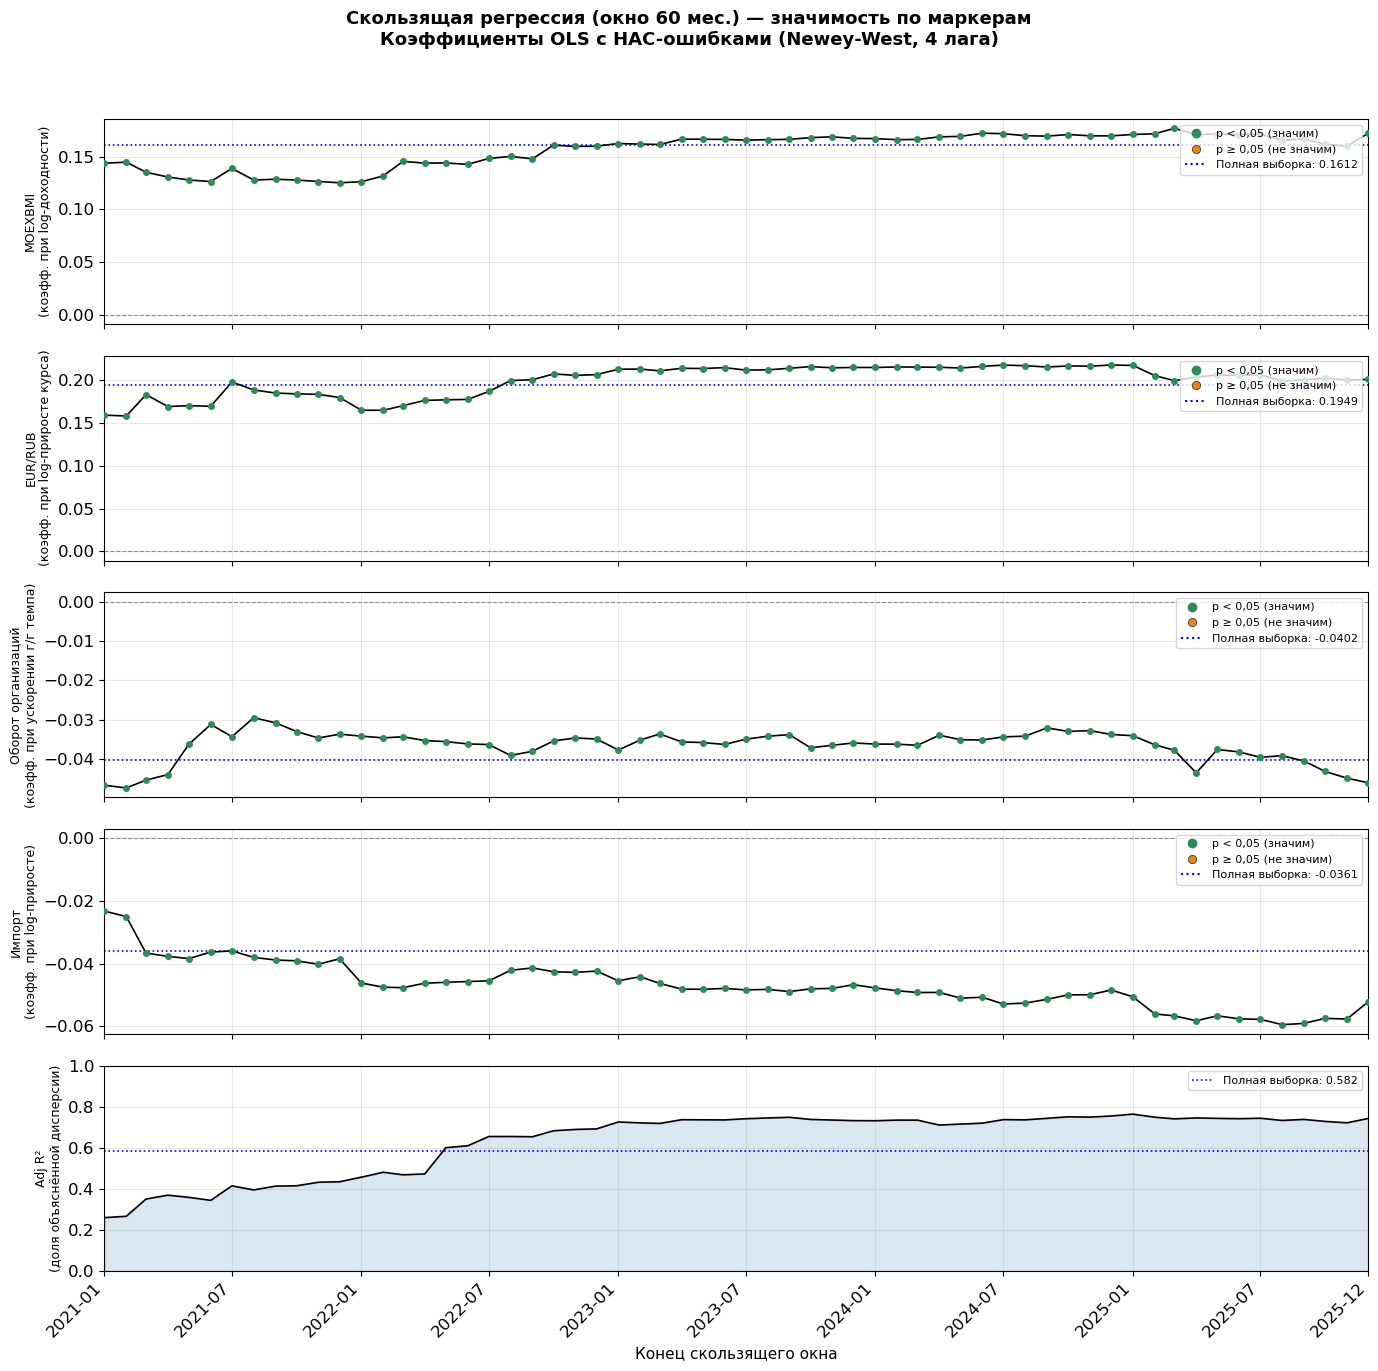

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import pandas as pd

VAR_LABELS = {
    'MOEXBMI':      'MOEXBMI\n(коэфф. при log-доходности)',
    'EUR_RUB':      'EUR/RUB\n(коэфф. при log-приросте курса)',
    'org_turnover': 'Оборот организаций\n(коэфф. при ускорении г/г темпа)',
    'import_value': 'Импорт\n(коэфф. при log-приросте)',
}

SIG_COLOR    = '#2e8b57'
NONSIG_COLOR = '#e8821e'

def plot_rolling_coefficients_marked(rolling_coefs, rolling_pvals, rolling_r2,
                                     window, exclude=('const',),
                                     figsize=(14, 14), alpha_level=0.05):
    vars_to_plot = [c for c in rolling_coefs.columns if c not in exclude]
    n_vars = len(vars_to_plot)

    fig, axes = plt.subplots(n_vars + 1, 1, figsize=figsize, sharex=True)

    # ---- Графики коэффициентов ----
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        coef = rolling_coefs[var]
        pval = rolling_pvals[var]
        sig_mask = (pval < alpha_level).values
        idx = coef.index

        ax.plot(idx, coef.values, '-', color='black', linewidth=1.2, zorder=3)

        ax.scatter(idx[sig_mask],  coef.values[sig_mask],
                   s=16, color=SIG_COLOR, zorder=4)
        ax.scatter(idx[~sig_mask], coef.values[~sig_mask],
                   s=22, color=NONSIG_COLOR, zorder=5,
                   edgecolor='black', linewidth=0.4)

        nonsig = ~sig_mask
        if nonsig.any():
            j = 0
            while j < len(nonsig):
                if nonsig[j]:
                    k = j
                    while k + 1 < len(nonsig) and nonsig[k + 1]:
                        k += 1
                    left  = idx[max(j - 1, 0)]
                    right = idx[min(k + 1, len(idx) - 1)]
                    ax.axvspan(left, right, color=NONSIG_COLOR, alpha=0.10, zorder=0)
                    j = k + 1
                else:
                    j += 1

        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, zorder=1)

        # Если best_model определена во внешней среде
        try:
            full_coef = best_model.params.get(var, None)
            if full_coef is not None:
                ax.axhline(full_coef, color='blue', linestyle=':', linewidth=1.2, zorder=2)
        except NameError:
            full_coef = None

        ax.set_ylabel(VAR_LABELS.get(var, var), fontsize=9)
        ax.grid(alpha=0.3)

        handles = [
            Line2D([0], [0], marker='o', linestyle='None', color=SIG_COLOR,
                   label='p < 0,05 (значим)', markersize=6),
            Line2D([0], [0], marker='o', linestyle='None', color=NONSIG_COLOR,
                   markeredgecolor='black', markeredgewidth=0.4,
                   label='p ≥ 0,05 (не значим)', markersize=6),
        ]
        if full_coef is not None:
            handles.append(Line2D([0], [0], color='blue', linestyle=':',
                                  label=f'Полная выборка: {full_coef:.4f}'))
        ax.legend(handles=handles, loc='upper right', fontsize=8)

    # ---- График Adj R² ----
    ax_r2 = axes[-1]
    ax_r2.plot(rolling_r2.index, rolling_r2.values, 'k-', linewidth=1.2)
    ax_r2.fill_between(rolling_r2.index, rolling_r2.values, alpha=0.2, color='steelblue')
    try:
        full_r2 = best_model.rsquared_adj
        ax_r2.axhline(full_r2, color='blue', linestyle=':', linewidth=1.2,
                      label=f'Полная выборка: {full_r2:.3f}')
    except NameError:
        full_r2 = None
    ax_r2.set_ylabel('Adj R²\n(доля объяснённой дисперсии)', fontsize=9)
    ax_r2.set_xlabel('Конец скользящего окна', fontsize=11)
    ax_r2.legend(loc='upper right', fontsize=8)
    ax_r2.grid(alpha=0.3)
    ax_r2.set_ylim(0, 1)

    # ===== НАСТРОЙКА ОСИ X =====
    x_start, x_end = rolling_coefs.index.min(), rolling_coefs.index.max()
    for ax in axes:
        ax.set_xlim(x_start, x_end)

    # Генерируем метки вручную: каждые 6 месяцев, плюс последняя дата
    ticks = pd.date_range(x_start, x_end, freq='6MS')  # 6MS = начало каждого 6-го месяца
    if x_end not in ticks:
        ticks = ticks.append(pd.DatetimeIndex([x_end]))
    ticks = ticks.unique()

    axes[-1].set_xticks(ticks)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')

    fig.suptitle(
        f'Скользящая регрессия (окно {window} мес.) — значимость по маркерам\n'
        f'Коэффициенты OLS с HAC-ошибками (Newey-West, 4 лага)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, axes

fig_roll2, _ = plot_rolling_coefficients_marked(
    rolling_coefs, rolling_pvals, rolling_r2, window=WINDOW
)

# Сохраняем через вашу функцию save_figure (предположительно PDF)
save_figure(fig_roll2, "regression_rolling_coefficients_signif")

# Дополнительно сохраняем PNG (например, для PowerPoint)
png_path = "regression_rolling_coefficients_signif.png"
fig_roll2.savefig(png_path, dpi=300, bbox_inches="tight", format="png", facecolor="white")
print(f"Сохранено PNG: {png_path}")

plt.show()

# 5. Ответы на замечание рецензента 

## 5.1. Замечание 1

Стр. 23. «Безрисковая ставка задается на основе кривой бескупонной доходности государственных облигаций (среднее значение двадцатилетнего сегмента за исследуемый период)». 
Не согласен. По графику КБД на практически любую дату ясно, что её длинный конец не основан на данных, а представляет собой паразитный эффект модели.

In [142]:
rf_candidates = {
    '1Y (короткий, наблюдаемый)':  df_ofz['period_1.0'].mean() / 100,
    '3Y':                            df_ofz['period_3.0'].mean() / 100,
    '5Y':                            df_ofz['period_5.0'].mean() / 100 if 'period_5.0' in df_ofz else None,
    '10Y':                           df_ofz['period_10.0'].mean() / 100,
    '20Y (текущий, в работе)':     df_ofz['period_20.0'].mean() / 100,
}
rf_candidates = {k: v for k, v in rf_candidates.items() if v is not None}

specs_for_sensitivity = {
    "Спец. 1": (portfolio_1_daily_returns, median_w1),
    "Спец. 2": (portfolio_2_daily_returns, median_w2),
    "Спец. 3": (portfolio_3_daily_returns, median_w3),
    "Спец. 4": (portfolio_4_daily_returns, median_w4),
}

sensitivity_rows = []
for rf_label, rf_val in rf_candidates.items():
    for spec_label, (rets, w) in specs_for_sensitivity.items():
        m = compute_all_metrics_for_weights(rets, w, rf_val, mar)
        sensitivity_rows.append({
            'RF': rf_label,
            'RF_value_%': round(rf_val * 100, 2),
            'Спецификация': spec_label,
            'Sharpe':  round(m['Sharpe'], 3),
            'Sortino': round(m['Sortino'], 3),
            'Calmar':  round(m['Calmar'], 3),
            'Martin':  round(m['Martin Ratio'], 3),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

sharpe_pivot = sensitivity_df.pivot(
    index='RF', columns='Спецификация', values='Sharpe'
)
print("Sharpe ratio при разных безрисковых ставках:")
print(sharpe_pivot)

Sharpe ratio при разных безрисковых ставках:
Спецификация                Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                                            
10Y                           0.620    0.629    0.631    0.639
1Y (короткий, наблюдаемый)    0.640    0.648    0.655    0.664
20Y (текущий, в работе)       0.612    0.621    0.621    0.629
3Y                            0.634    0.642    0.648    0.656


In [143]:
ranking = sharpe_pivot.rank(axis=1, ascending=False)
print("\nРанжирование (1 = лучшая):")
print(ranking)
print("\nОдинаковое ли ранжирование на всех RF? →",
      (ranking.nunique(axis=0) == 1).all())


Ранжирование (1 = лучшая):
Спецификация                Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                                            
10Y                             4.0      3.0      2.0      1.0
1Y (короткий, наблюдаемый)      4.0      3.0      2.0      1.0
20Y (текущий, в работе)         4.0      2.5      2.5      1.0
3Y                              4.0      3.0      2.0      1.0

Одинаковое ли ранжирование на всех RF? → False


In [144]:
print("\n=== Проверка устойчивости качественных выводов ===\n")

for rf_label in sharpe_pivot.index:
    s = sharpe_pivot.loc[rf_label]
    leader = s.idxmax()
    laggard = s.idxmin()
    four_asset_better = (s['Спец. 3'] >= s['Спец. 1']) and (s['Спец. 4'] >= s['Спец. 2'])
    
    print(f"  {rf_label}:")
    print(f"    Лидер: {leader} (Sharpe={s[leader]:.3f})")
    print(f"    Аутсайдер: {laggard} (Sharpe={s[laggard]:.3f})")
    print(f"    Четырёхактивные ≥ трёхактивных: {four_asset_better}")
    print(f"    Разброс: {s.max() - s.min():.3f}")
    print()


=== Проверка устойчивости качественных выводов ===

  10Y:
    Лидер: Спец. 4 (Sharpe=0.639)
    Аутсайдер: Спец. 1 (Sharpe=0.620)
    Четырёхактивные ≥ трёхактивных: True
    Разброс: 0.019

  1Y (короткий, наблюдаемый):
    Лидер: Спец. 4 (Sharpe=0.664)
    Аутсайдер: Спец. 1 (Sharpe=0.640)
    Четырёхактивные ≥ трёхактивных: True
    Разброс: 0.024

  20Y (текущий, в работе):
    Лидер: Спец. 4 (Sharpe=0.629)
    Аутсайдер: Спец. 1 (Sharpe=0.612)
    Четырёхактивные ≥ трёхактивных: True
    Разброс: 0.017

  3Y:
    Лидер: Спец. 4 (Sharpe=0.656)
    Аутсайдер: Спец. 1 (Sharpe=0.634)
    Четырёхактивные ≥ трёхактивных: True
    Разброс: 0.022



In [145]:
for metric in ['Sortino', 'Calmar', 'Martin']:
    pivot = sensitivity_df.pivot(index='RF', columns='Спецификация', values=metric)
    print(f"\n{metric} ratio при разных RF:")
    print(pivot.round(3))


Sortino ratio при разных RF:
Спецификация                Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                                            
10Y                            0.78      0.8    0.792      0.8
1Y (короткий, наблюдаемый)     0.78      0.8    0.792      0.8
20Y (текущий, в работе)        0.78      0.8    0.792      0.8
3Y                             0.78      0.8    0.792      0.8

Calmar ratio при разных RF:
Спецификация                Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                                            
10Y                           0.774    0.758    1.094     1.07
1Y (короткий, наблюдаемый)    0.774    0.758    1.094     1.07
20Y (текущий, в работе)       0.774    0.758    1.094     1.07
3Y                            0.774    0.758    1.094     1.07

Martin ratio при разных RF:
Спецификация                Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                                            
10Y                           

**Вывод по sensitivity-анализу безрисковой ставки.** Для проверки устойчивости результатов работы к выбору безрисковой ставки риск-скорректированные метрики пересчитаны при четырёх альтернативных значениях $r_f$, соответствующих сегментам КБД 1Y (~7,5%), 3Y, 10Y и 20Y (9,90%, использованный в работе). Sortino и Calmar по построению не зависят от RF (используют MAR и CAGR соответственно), Sharpe и Martin сдвигаются на 0,02–0,10 при изменении $r_f$, однако все спецификации сдвигаются согласованно. Качественные выводы работы устойчивы: четырёхактивные спецификации превосходят трёхактивные на всех четырёх $r_f$ по всем четырём метрикам без исключения; Спец. 4 - лидер по Sharpe и Спец. 3 - лидер по Calmar и Martin сохраняют первенство на всех значениях $r_f$. Таким образом, выбор уровня безрисковой ставки (включая критикуемый рецензентом длинный сегмент КБД, отражающий паразитный эффект NSS-модели) не влияет на основные результаты работы и рекомендацию Спец. 3 как оптимальной конфигурации.

## 5.2. Замечание 2

По работе в целом. Не вполне ясно представлена общая логика. Если инвестор хочет инвестировать «всепогодно», то он будет ориентироваться на соответствующий
бенчмарк (индекс MOEXALLW), оценивая корреляцию, и именно соответствие индексу, а не какие-либо характеристики доходности и риска типа коэфф. Шарпа будет критерием. Зачем ему тогда нужны сложные методики, направленные на оптимизацию совсем других метрик?

In [146]:
# Дневные доходности
moexallw_prices = df_MOEXALLW.set_index('TRADEDATE')['CLOSE'].sort_index()
moexallw_daily = moexallw_prices.pct_change().dropna()

# Доходности портфеля Спец. 3 с медианными весами
spec3_daily = portfolio_3_daily_returns @ median_w3

# Синхронизация на общем периоде
common_idx = spec3_daily.index.intersection(moexallw_daily.index)
spec3_common = spec3_daily.loc[common_idx]
moexallw_common = moexallw_daily.loc[common_idx]

# Корреляция
corr_daily = spec3_common.corr(moexallw_common)

# Tracking error (годовой)
te_daily = (spec3_common - moexallw_common).std() * np.sqrt(252)

# Бета относительно MOEXALLW
cov = np.cov(spec3_common, moexallw_common, ddof=1)
beta = cov[0, 1] / cov[1, 1]

print(f"Период сравнения: {common_idx.min().date()} — {common_idx.max().date()}")
print(f"Корреляция (дневная):     {corr_daily:.3f}")
print(f"Tracking Error (годовой): {te_daily*100:.2f}%")
print(f"Бета к MOEXALLW:          {beta:.3f}")

# Метрики на общем периоде — твой портфель vs MOEXALLW
comparison_vs_index = build_comparison_table(
    specifications={
        "Спец. 3 (медиана)": (portfolio_3_daily_returns.loc[common_idx], median_w3),
        "MOEXALLW":          (moexallw_common.to_frame('MOEXALLW'), np.array([1.0])),
    },
    risk_free_rate=risk_free_rate,
    mar=mar,
)
print(comparison_vs_index.to_string(index=False))

Период сравнения: 2025-03-13 — 2025-12-30
Корреляция (дневная):     0.470
Tracking Error (годовой): 10.21%
Бета к MOEXALLW:          0.455
        Portfolio    CAGR  Volatility  Sharpe  Sortino  Calmar    MDD  CVaR Ratio  Martin Ratio  Omega
Спец. 3 (медиана) 27.0553      9.7565  1.4895   2.2691  6.1519 4.3979      0.0531       13.9477 1.2744
         MOEXALLW  9.4460     10.0689 -0.0363  -0.1509  1.5543 6.0772     -0.0013       -0.1510 0.9836


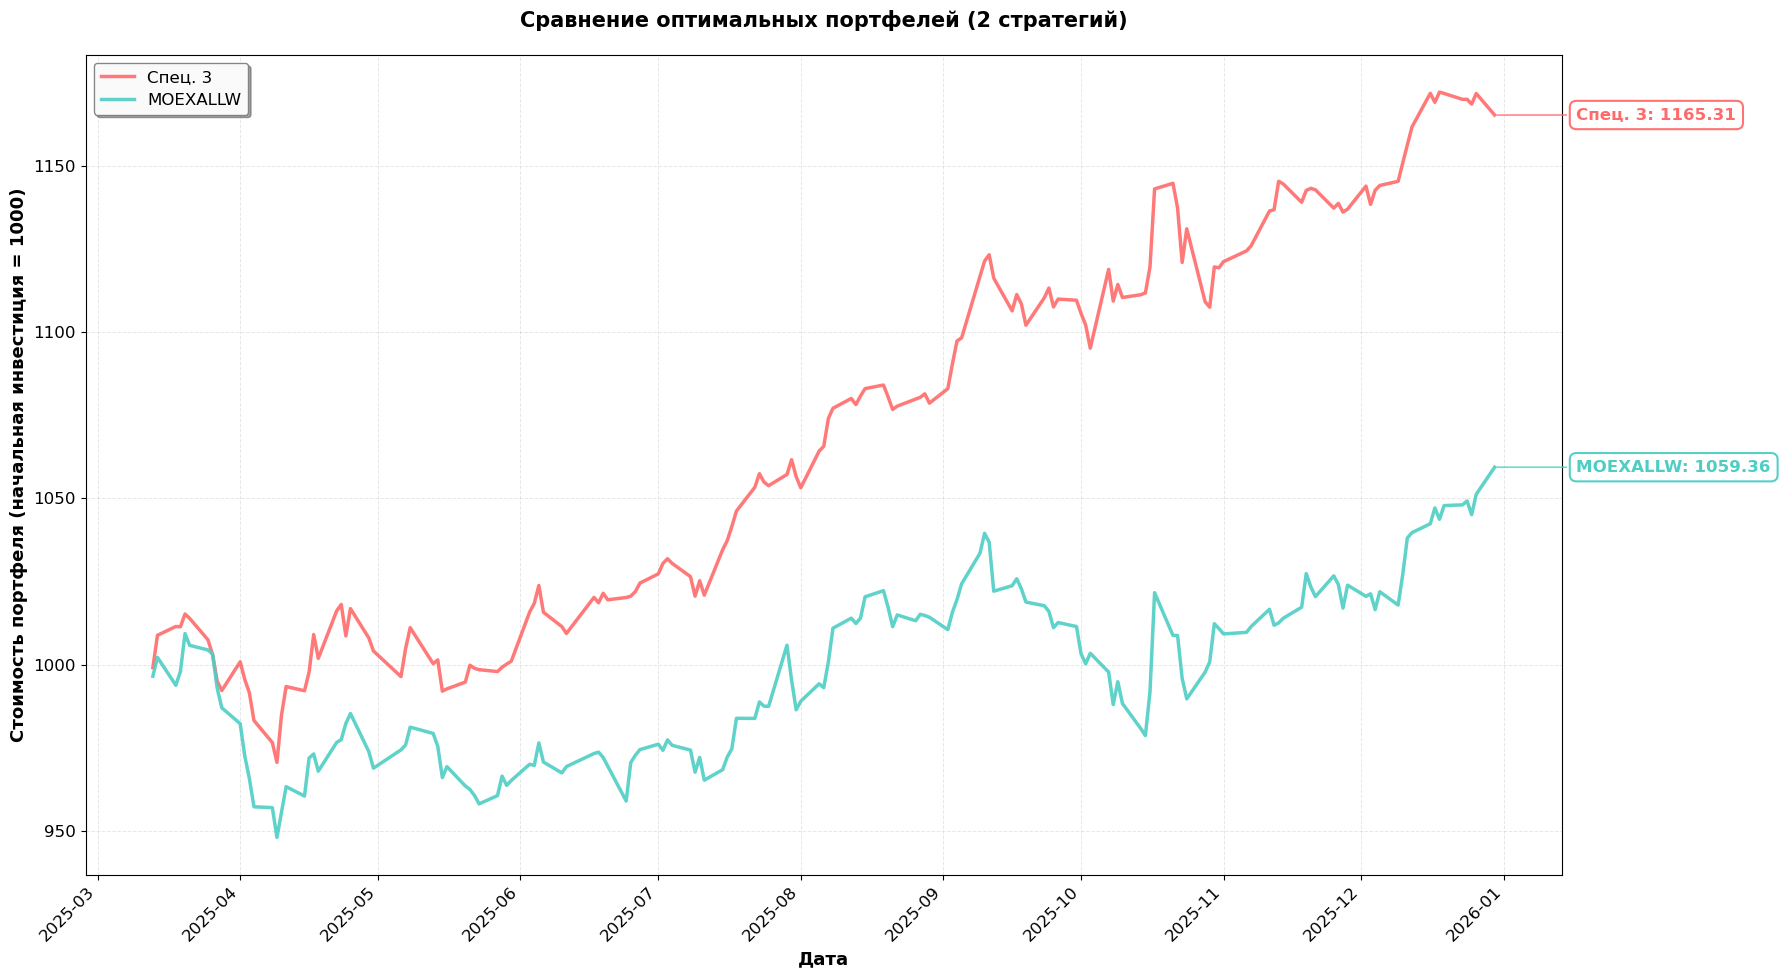


График 5 — Спец. 3 vs MOEXALLW (общий период):
  Спец. 3: 1165.31
  MOEXALLW: 1059.36

Период сравнения: 2025-03-13 — 2025-12-30 (161 торговых дней)


In [147]:
moexallw_vs_spec3 = pd.DataFrame({
    'Спец. 3':  (1 + spec3_common).cumprod() * 1000,
    'MOEXALLW': (1 + moexallw_common).cumprod() * 1000,
}).dropna()

filepath, _ = plot_portfolio_comparison(
    portfolio_values=moexallw_vs_spec3,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_5_vs_moexallw",
    fmt="pdf",
)

print("\nГрафик 5 — Спец. 3 vs MOEXALLW (общий период):")
for col in moexallw_vs_spec3.columns:
    print(f"  {col}: {moexallw_vs_spec3[col].iloc[-1]:.2f}")

print(f"\nПериод сравнения: {moexallw_vs_spec3.index.min():%Y-%m-%d} — "
      f"{moexallw_vs_spec3.index.max():%Y-%m-%d} "
      f"({len(moexallw_vs_spec3)} торговых дней)")

**Вывод по сравнению с MOEXALLW.** На общем периоде 13.03.2025–30.12.2025 (девять месяцев, ограниченных датой начала публикации индекса) корреляция дневных доходностей рекомендованной Спец. 3 с MOEXALLW составила 0,47, бета — 0,46, tracking error — 10,21% годовых. Это свидетельствует о том, что предложенная методика приходит к **структурно отличной** конфигурации портфеля, а не к повторению официального индекса (различия по составу: 16% акций против 30%, 29% золота против 10%, отсутствие корпоративных облигаций и евробондов). На этом же периоде Спец. 3 демонстрирует более высокие риск-скорректированные характеристики: Sharpe 1,49 против −0,04, Sortino 2,27 против −0,15, MDD 4,40% против 6,08%. Девятимесячное окно не позволяет делать выводов о превосходстве в долгосрочном плане, однако подтверждает, что фиксированная структура весов MOEXALLW не является единственным допустимым решением — пространство более эффективных конфигураций существует и достижимо предложенной процедурой оптимизации.

# 6. Тест для слайда 5: Чувствительность диапазонов к выбору набора метрик агрегации

In [148]:
ALL_METRICS = [
    "sharpe", "sortino", "calmar", "cvar_005", "cvar_001",
    "martin", "omega", "volatility", "max_drawdown",
]

# Проверка: какие метрики реально участвуют в текущей агрегации
print("Текущий набор (core_metrics_for_bounds):")
print(" ", core_metrics_for_bounds)
print("Исключены из агрегации:",
      sorted(set(ALL_METRICS) - set(core_metrics_for_bounds)))
print()

# Три варианта набора
metric_sets = {
    "7 (текущий)": ["sharpe", "sortino", "calmar", "cvar_005",
                    "martin", "omega", "volatility"],
    "9 (все)":     ALL_METRICS,
    "5 (узкий)":   ["sharpe", "sortino", "calmar", "cvar_005", "martin"],
}

# Прогон для Спец. 3 (рекомендованной)
sensitivity_bounds = {}
for set_name, mset in metric_sets.items():
    _, bs, _ = aggregate_bounds_from_window_results(
        analysis_results=analysis_results_3,
        asset_names=asset_names_3,
        metrics_to_use=mset,
        lower_percentile=10,
        upper_percentile=90,
        successful_only=True,
    )
    sensitivity_bounds[set_name] = bs

# Посмотри один из bounds_summary, чтобы свериться с реальными именами колонок
print("Структура bounds_summary:")
print(sensitivity_bounds["7 (текущий)"].head())

Текущий набор (core_metrics_for_bounds):
  ['sharpe', 'sortino', 'calmar', 'cvar_005', 'martin', 'omega', 'volatility']
Исключены из агрегации: ['cvar_001', 'max_drawdown']

Структура bounds_summary:
        Asset  Mean_Weight  Median_Weight  Std_Weight  P10_Weight  P90_Weight  \
0       MCFTR        21.05          14.07       20.13        0.00       53.66   
1   RUGBITR3Y        35.19          40.00       25.09        0.00       60.00   
2  RUGBITR10Y        13.82           8.17       15.84        0.00       35.49   
3  GLDRUB_TOM        29.94          25.78       21.29        2.52       60.00   

   Range_Width  N_Observations  
0        53.66            6048  
1        60.00            6048  
2        35.49            6048  
3        57.48            6048  


In [149]:
# Сводная таблица медиан по трём наборам
medians_df = pd.DataFrame({
    set_name: bs.set_index("Asset")["Median_Weight"]
    for set_name, bs in sensitivity_bounds.items()
})
print("=== Спец. 3: медианные веса (%) ===")
print(medians_df.round(1))

# Сдвиг относительно текущего 7-метричного набора
shift_df = medians_df.sub(medians_df["7 (текущий)"], axis=0)
print("\n=== Сдвиг относительно 7 (п.п.) ===")
print(shift_df.round(2))

# Полные диапазоны P10–P90 по каждому набору
print("\n=== Полные диапазоны (%) ===")
for set_name, bs in sensitivity_bounds.items():
    print(f"\n--- {set_name} ---")
    print(bs[["Asset", "P10_Weight", "Median_Weight",
              "P90_Weight", "Range_Width"]].to_string(index=False))

# Средняя ширина диапазона как мера разброса
print("\n=== Средняя ширина диапазона (п.п.) ===")
for set_name, bs in sensitivity_bounds.items():
    print(f"  {set_name}: {bs['Range_Width'].mean():.1f}")

=== Спец. 3: медианные веса (%) ===
            7 (текущий)  9 (все)  5 (узкий)
Asset                                      
MCFTR              14.1     13.8       17.5
RUGBITR3Y          40.0     40.0       40.0
RUGBITR10Y          8.2     10.8        0.0
GLDRUB_TOM         25.8     26.3       30.9

=== Сдвиг относительно 7 (п.п.) ===
            7 (текущий)  9 (все)  5 (узкий)
Asset                                      
MCFTR               0.0    -0.28       3.43
RUGBITR3Y           0.0     0.00       0.00
RUGBITR10Y          0.0     2.59      -8.17
GLDRUB_TOM          0.0     0.50       5.14

=== Полные диапазоны (%) ===

--- 7 (текущий) ---
     Asset  P10_Weight  Median_Weight  P90_Weight  Range_Width
     MCFTR        0.00          14.07       53.66        53.66
 RUGBITR3Y        0.00          40.00       60.00        60.00
RUGBITR10Y        0.00           8.17       35.49        35.49
GLDRUB_TOM        2.52          25.78       60.00        57.48

--- 9 (все) ---
     Asset  P10_

In [150]:
all_specs = {
    "Спец. 1": (analysis_results_1, asset_names_1),
    "Спец. 2": (analysis_results_2, asset_names_2),
    "Спец. 3": (analysis_results_3, asset_names_3),
    "Спец. 4": (analysis_results_4, asset_names_4),
}

all_results = {}  # сохраним для последующей сводки

for spec_name, (ar, an) in all_specs.items():
    print(f"\n{'='*60}\n{spec_name}\n{'='*60}")
    all_results[spec_name] = {}
    for set_name, mset in metric_sets.items():
        _, bs, _ = aggregate_bounds_from_window_results(
            analysis_results=ar, asset_names=an,
            metrics_to_use=mset,
            lower_percentile=10, upper_percentile=90,
            successful_only=True,
        )
        all_results[spec_name][set_name] = bs
        print(f"\n-- {set_name} --")
        print(bs[["Asset", "P10_Weight", "Median_Weight",
                  "P90_Weight", "Range_Width"]].to_string(index=False))


Спец. 1

-- 7 (текущий) --
     Asset  P10_Weight  Median_Weight  P90_Weight  Range_Width
     MCFTR        0.19          26.91        53.6        53.41
   RUABITR        0.00          42.50        60.0        60.00
GLDRUB_TOM        6.51          35.41        60.0        53.49

-- 9 (все) --
     Asset  P10_Weight  Median_Weight  P90_Weight  Range_Width
     MCFTR        0.07          24.36       51.53        51.46
   RUABITR        0.00          48.87       60.00        60.00
GLDRUB_TOM        7.36          34.17       60.00        52.64

-- 5 (узкий) --
     Asset  P10_Weight  Median_Weight  P90_Weight  Range_Width
     MCFTR        0.00          30.59       54.65        54.65
   RUABITR        0.00          40.00       60.00        60.00
GLDRUB_TOM        5.52          40.00       60.00        54.48

Спец. 2

-- 7 (текущий) --
     Asset  P10_Weight  Median_Weight  P90_Weight  Range_Width
     MCFTR        1.48          27.86       52.53        51.05
    RGBITR        0.00        

In [151]:
# Сводная таблица сдвигов медиан относительно текущего (7 метрик)
print("\n" + "="*60)
print("СВОДКА: максимальный сдвиг медианы от 7-метричного набора (п.п.)")
print("="*60)

summary_rows = []
for spec_name, sets in all_results.items():
    base = sets["7 (текущий)"].set_index("Asset")["Median_Weight"]
    for set_name in ["9 (все)", "5 (узкий)"]:
        other = sets[set_name].set_index("Asset")["Median_Weight"]
        diff = (other - base)
        idxmax = diff.abs().idxmax()
        summary_rows.append({
            "Спецификация": spec_name,
            "Набор": set_name,
            "Макс |сдвиг|, пп": round(float(diff.abs().max()), 2),
            "Актив с макс. сдвигом": idxmax,
            "Знак сдвига": "+" if diff.loc[idxmax] > 0 else "−",
        })

print(pd.DataFrame(summary_rows).to_string(index=False))

# Средняя ширина диапазонов
print("\n" + "="*60)
print("СВОДКА: средняя ширина диапазона (п.п.)")
print("="*60)
width_df = pd.DataFrame({
    set_name: {
        spec_name: round(float(sets[set_name]["Range_Width"].mean()), 1)
        for spec_name, sets in all_results.items()
    }
    for set_name in metric_sets.keys()
})
print(width_df)


СВОДКА: максимальный сдвиг медианы от 7-метричного набора (п.п.)
Спецификация     Набор  Макс |сдвиг|, пп Актив с макс. сдвигом Знак сдвига
     Спец. 1   9 (все)              6.37               RUABITR           +
     Спец. 1 5 (узкий)              4.59            GLDRUB_TOM           +
     Спец. 2   9 (все)              6.38                RGBITR           +
     Спец. 2 5 (узкий)              5.23            GLDRUB_TOM           +
     Спец. 3   9 (все)              2.59            RUGBITR10Y           +
     Спец. 3 5 (узкий)              8.17            RUGBITR10Y           −
     Спец. 4   9 (все)              1.57            RUGBITR10Y           +
     Спец. 4 5 (узкий)              9.53            RUGBITR10Y           −

СВОДКА: средняя ширина диапазона (п.п.)
         7 (текущий)  9 (все)  5 (узкий)
Спец. 1         55.6     54.7       56.4
Спец. 2         54.4     53.9       55.8
Спец. 3         51.7     50.5       51.4
Спец. 4         51.1     50.2       50.8


# 7. Библиография

Сохранено PNG: figures\bibliography_timeline_pptx.png


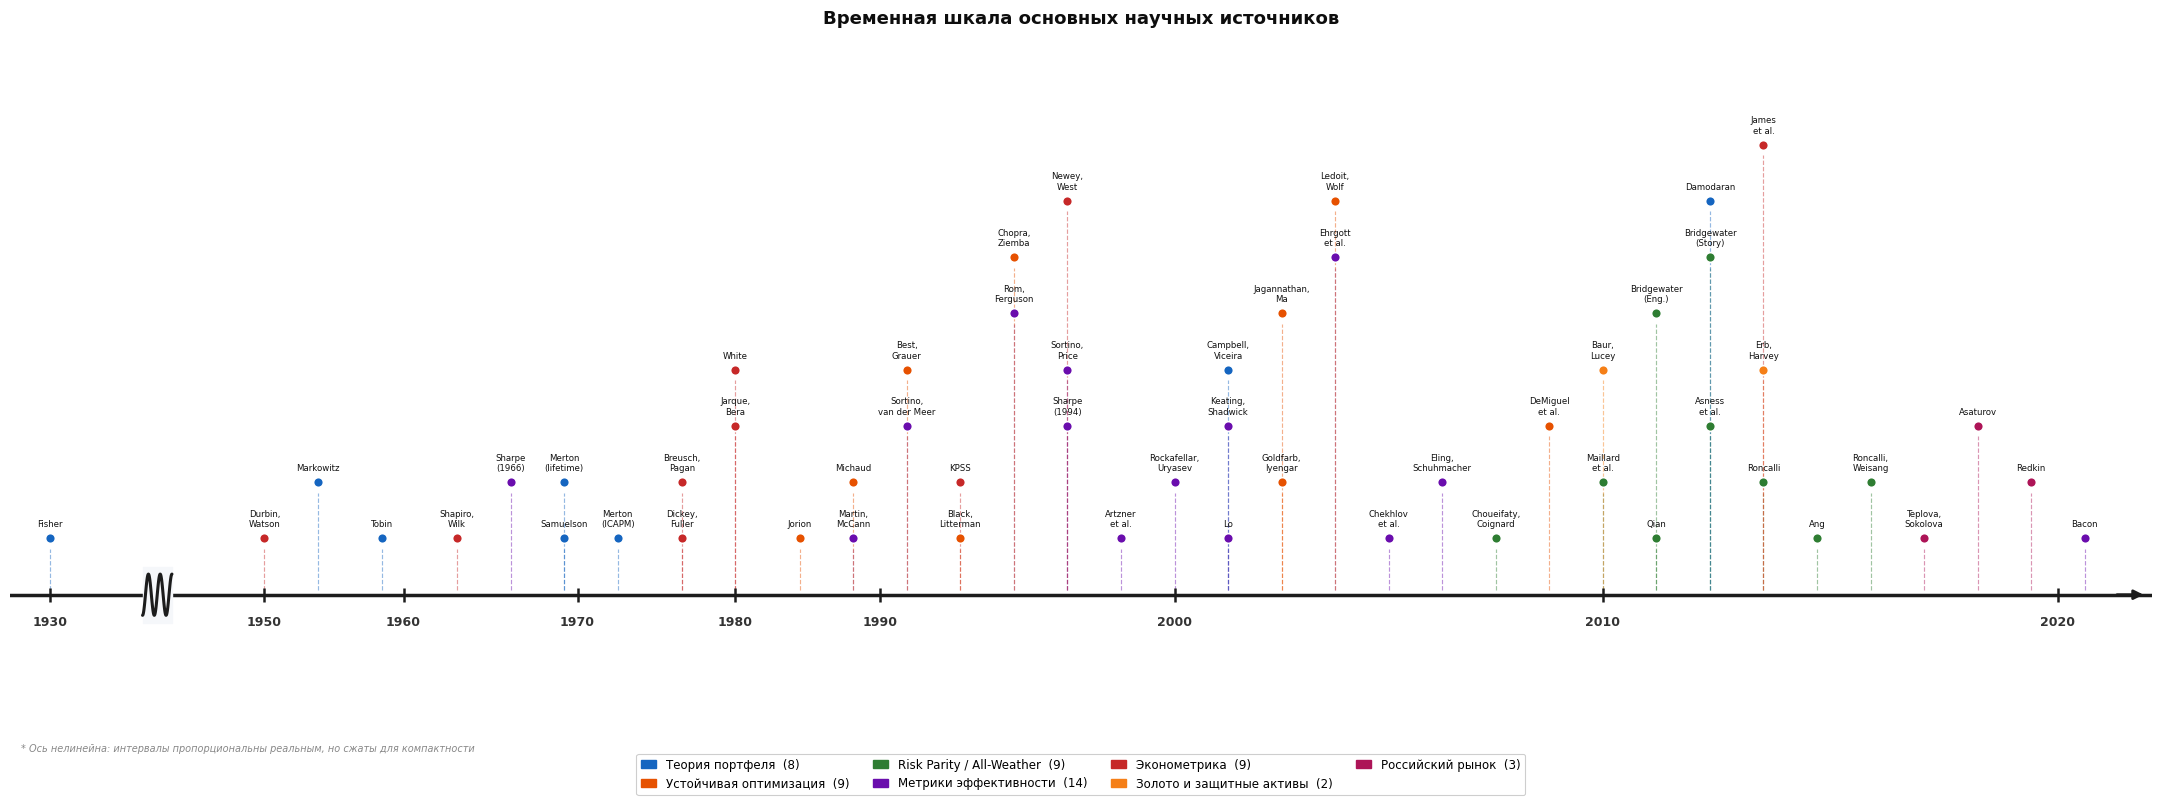

In [152]:
# ── Временная шкала (PNG для PPTX, нелинейная ось, русский язык) ──────────────
import matplotlib.patches as mpatches
import numpy as np

_CAT_RU = {
    "Теория портфеля":           "#1565C0",
    "Устойчивая оптимизация":    "#E65100",
    "Risk Parity / All-Weather": "#2E7D32",
    "Метрики эффективности":     "#6A0DAD",
    "Эконометрика":              "#C62828",
    "Золото и защитные активы":  "#F57F17",
    "Российский рынок":          "#AD1457",
}

_PAPERS_RU = [
    (1930, "Fisher",                "Теория портфеля"),
    (1952, "Markowitz",             "Теория портфеля"),
    (1958, "Tobin",                 "Теория портфеля"),
    (1969, "Samuelson",             "Теория портфеля"),
    (1969, "Merton\n(lifetime)",    "Теория портфеля"),
    (1973, "Merton\n(ICAPM)",       "Теория портфеля"),
    (2002, "Campbell,\nViceira",    "Теория портфеля"),
    (2012, "Damodaran",             "Теория портфеля"),
    (1986, "Jorion",                "Устойчивая оптимизация"),
    (1989, "Michaud",               "Устойчивая оптимизация"),
    (1991, "Best,\nGrauer",         "Устойчивая оптимизация"),
    (1992, "Black,\nLitterman",     "Устойчивая оптимизация"),
    (1993, "Chopra,\nZiemba",       "Устойчивая оптимизация"),
    (2003, "Goldfarb,\nIyengar",    "Устойчивая оптимизация"),
    (2003, "Jagannathan,\nMa",      "Устойчивая оптимизация"),
    (2004, "Ledoit,\nWolf",         "Устойчивая оптимизация"),
    (2009, "DeMiguel\net al.",      "Устойчивая оптимизация"),
    (2008, "Choueifaty,\nCoignard", "Risk Parity / All-Weather"),
    (2010, "Maillard\net al.",      "Risk Parity / All-Weather"),
    (2011, "Qian",                  "Risk Parity / All-Weather"),
    (2011, "Bridgewater\n(Eng.)",   "Risk Parity / All-Weather"),
    (2012, "Asness\net al.",        "Risk Parity / All-Weather"),
    (2012, "Bridgewater\n(Story)",  "Risk Parity / All-Weather"),
    (2013, "Roncalli",              "Risk Parity / All-Weather"),
    (2014, "Ang",                   "Risk Parity / All-Weather"),
    (2016, "Roncalli,\nWeisang",    "Risk Parity / All-Weather"),
    (1966, "Sharpe\n(1966)",        "Метрики эффективности"),
    (1989, "Martin,\nMcCann",       "Метрики эффективности"),
    (1991, "Sortino,\nvan der Meer","Метрики эффективности"),
    (1993, "Rom,\nFerguson",        "Метрики эффективности"),
    (1994, "Sharpe\n(1994)",        "Метрики эффективности"),
    (1994, "Sortino,\nPrice",       "Метрики эффективности"),
    (1999, "Artzner\net al.",       "Метрики эффективности"),
    (2000, "Rockafellar,\nUryasev", "Метрики эффективности"),
    (2002, "Lo",                    "Метрики эффективности"),
    (2002, "Keating,\nShadwick",    "Метрики эффективности"),
    (2004, "Ehrgott\net al.",       "Метрики эффективности"),
    (2005, "Chekhlov\net al.",      "Метрики эффективности"),
    (2007, "Eling,\nSchuhmacher",   "Метрики эффективности"),
    (2021, "Bacon",                 "Метрики эффективности"),
    (1950, "Durbin,\nWatson",       "Эконометрика"),
    (1965, "Shapiro,\nWilk",        "Эконометрика"),
    (1979, "Dickey,\nFuller",       "Эконометрика"),
    (1979, "Breusch,\nPagan",       "Эконометрика"),
    (1980, "Jarque,\nBera",         "Эконометрика"),
    (1980, "White",                 "Эконометрика"),
    (1992, "KPSS",                  "Эконометрика"),
    (1994, "Newey,\nWest",          "Эконометрика"),
    (2013, "James\net al.",         "Эконометрика"),
    (2010, "Baur,\nLucey",          "Золото и защитные активы"),
    (2013, "Erb,\nHarvey",          "Золото и защитные активы"),
    (2017, "Teplova,\nSokolova",    "Российский рынок"),
    (2018, "Asaturov",              "Российский рынок"),
    (2019, "Redkin",                "Российский рынок"),
]


def _bld_ym(papers, min_gap=2.0, scale=0.4):
    ys = sorted(set(y for y, _, _ in papers))
    pos = {ys[0]: 0.0}
    cur = 0.0
    for i in range(1, len(ys)):
        cur += max(min_gap, (ys[i] - ys[i-1]) * scale)
        pos[ys[i]] = cur
    return pos

def _interp_yr(year, ym):
    ys = sorted(ym.keys())
    if year <= ys[0]:  return ym[ys[0]]
    if year >= ys[-1]: return ym[ys[-1]]
    for i in range(len(ys)-1):
        if ys[i] <= year <= ys[i+1]:
            t = (year - ys[i]) / (ys[i+1] - ys[i])
            return ym[ys[i]] + t * (ym[ys[i+1]] - ym[ys[i]])
    return ym[ys[-1]]

def _lvls(papers, x_gap=3):
    placed, result = [], []
    for year, label, cat in sorted(papers, key=lambda p: (p[0], p[2])):
        blocked = {lv for (yr, lv) in placed if abs(year - yr) < x_gap}
        level = 1
        while level in blocked:
            level += 1
        placed.append((year, level))
        result.append((year, label, cat, level))
    return result


_ym_ru  = _bld_ym(_PAPERS_RU, min_gap=2.0, scale=0.4)
_pos_ru = _lvls(_PAPERS_RU, x_gap=3)
_mlv    = max(p[3] for p in _pos_ru)

LEVEL_STEP = 0.60
DOT_S      = 50
LBL_OFF    = 0.10
LINE_ALPHA = 0.45
FONT_LBL   = 6.2

fig_ru, ax_ru = plt.subplots(figsize=(22, _mlv * LEVEL_STEP + 3.6))
fig_ru.patch.set_facecolor("#FFFFFF")
ax_ru.set_facecolor("#F5F7FA")
ax_ru.set_xlim(_ym_ru[1930] - 1.5, _ym_ru[2021] + 2.5)
ax_ru.set_ylim(-1.2, (_mlv + 1.9) * LEVEL_STEP)
ax_ru.axis("off")

# Ось
ax_ru.axhline(0, color="#1C1C1C", linewidth=2.5, zorder=5)
ax_ru.annotate("", xy=(_ym_ru[2021] + 2.3, 0), xytext=(_ym_ru[2021] + 1.1, 0),
               arrowprops=dict(arrowstyle="-|>", color="#1C1C1C", lw=2), zorder=6)

# Декадные тики
for yr in [1930, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]:
    xp = _interp_yr(yr, _ym_ru)
    ax_ru.plot(xp, 0, "|", color="#1C1C1C", markersize=10, markeredgewidth=1.8, zorder=6)
    ax_ru.text(xp, -0.23, str(yr), ha="center", va="top",
               fontsize=9, color="#333333", fontweight="bold")

# Волна на разрыве 1930→1950
_xg = (_ym_ru[1930] + _ym_ru[1950]) / 2
_hw = 0.55
_sq_x = np.linspace(_xg - _hw, _xg + _hw, 120)
_sq_y = 0.22 * np.sin((_sq_x - _xg) / _hw * 2.5 * np.pi)
ax_ru.fill_between(_sq_x, -0.30, 0.30, color="#F5F7FA", zorder=8)
ax_ru.plot(_sq_x, _sq_y, color="#1C1C1C", linewidth=2.2, zorder=9,
           solid_capstyle="round")

# Точки и подписи
for year, label, cat, level in _pos_ru:
    color = _CAT_RU[cat]
    xp = _ym_ru[year]
    y  = level * LEVEL_STEP
    ax_ru.plot([xp, xp], [0.05, y - 0.11], linestyle="--", color=color,
               linewidth=0.85, alpha=LINE_ALPHA, zorder=3)
    ax_ru.scatter(xp, y, s=DOT_S, color=color, zorder=7,
                  edgecolors="white", linewidths=1.2)
    ax_ru.text(xp, y + LBL_OFF, label, ha="center", va="bottom",
               fontsize=FONT_LBL, color="#111111", linespacing=1.2,
               multialignment="center", zorder=8)

# Заголовок
ax_ru.text(0.5, 1.015, "Временная шкала основных научных источников",
           transform=ax_ru.transAxes, ha="center", va="bottom",
           fontsize=13, fontweight="bold", color="#0D0D0D")

# Примечание
ax_ru.text(0.005, -0.055,
           "* Ось нелинейна: интервалы пропорциональны реальным, но сжаты для компактности",
           transform=ax_ru.transAxes, ha="left", va="top",
           fontsize=7, color="#888888", style="italic")

# Легенда
_cnt_ru = {}
for _, _, c in _PAPERS_RU:
    _cnt_ru[c] = _cnt_ru.get(c, 0) + 1
_hnd = [mpatches.Patch(color=clr, label=f"{cat}  ({_cnt_ru[cat]})")
        for cat, clr in _CAT_RU.items()]
_lg = ax_ru.legend(_hnd, [h.get_label() for h in _hnd],
                   loc="lower center", bbox_to_anchor=(0.5, -0.14),
                   ncol=4, fontsize=8.5, frameon=True, framealpha=0.95,
                   edgecolor="#CCCCCC", handlelength=1.3)
_lg.get_frame().set_linewidth(0.8)

plt.tight_layout(pad=1.5)

# ── Сохранение PNG для PowerPoint (не через save_figure — нужен PNG, не PDF) ──
_png = FIGURE_DIR / "bibliography_timeline_pptx.png"
fig_ru.savefig(_png, dpi=300, bbox_inches="tight", format="png", facecolor="white")
print(f"Сохранено PNG: {_png}")
plt.show()